# Project Overview and Research Objective

This notebook analyzes satisfaction with democracy in Ecuador using Latinobarómetro survey data. The study follows two main objectives.

First, it evaluates the predictive performance of different classification models across three historical periods defined from temporal patterns in the distribution of satisfaction and dissatisfaction with democracy.

Second, it interprets the most important predictors associated with satisfaction with democracy in order to understand how political attitudes, institutional trust, economic perceptions, material conditions, labor conditions, and sociodemographic variables contribute to classification differences across periods.

The target variable is `ETIQUETA`, where `1` represents respondents satisfied with democracy and `0` represents respondents dissatisfied with democracy.

---

# PART 1 — Environment and Configuration

This part sets up the computational environment, imports the required libraries, reports package versions, and defines global configuration values used throughout the notebook.

---

## Environment and Libraries

This section imports the libraries required for data processing, visualization, preprocessing, model training, hyperparameter tuning, class imbalance handling, and model evaluation.

In [247]:
# =============================================================================
# ENVIRONMENT AND LIBRARIES
# =============================================================================

# -----------------------------------------------------------------------------
# Output configuration
# -----------------------------------------------------------------------------
from pathlib import Path

# -----------------------------------------------------------------------------
# Base libraries
# -----------------------------------------------------------------------------
import numpy as np
import pandas as pd

# -----------------------------------------------------------------------------
# Visualization
# -----------------------------------------------------------------------------
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

# -----------------------------------------------------------------------------
# Scikit-learn: data splitting and validation
# -----------------------------------------------------------------------------
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV
)
# -----------------------------------------------------------------------------
# Scikit-learn: preprocessing
# -----------------------------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# -----------------------------------------------------------------------------
# Scikit-learn: classification models
# -----------------------------------------------------------------------------
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# -----------------------------------------------------------------------------
# Scikit-learn: evaluation metrics
# -----------------------------------------------------------------------------
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    make_scorer
)

# -----------------------------------------------------------------------------
# Imbalanced-learn: resampling and pipeline
# -----------------------------------------------------------------------------
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTENC

# -----------------------------------------------------------------------------
# IMPORT FOR PREDICTOR IMPORTANCE
# -----------------------------------------------------------------------------
from sklearn.inspection import permutation_importance

## Package Versions

This section reports the package versions used in the analysis to support reproducibility and make the computational environment transparent.

In [248]:
# =============================================================================
# PACKAGE VERSIONS
# =============================================================================

import sklearn
import imblearn
import matplotlib

print("Python packages:")
print(f"pandas:           {pd.__version__}")
print(f"numpy:            {np.__version__}")
print(f"matplotlib:       {matplotlib.__version__}")
print(f"scikit-learn:     {sklearn.__version__}")
print(f"imbalanced-learn: {imblearn.__version__}")

Python packages:
pandas:           3.0.3
numpy:            2.4.6
matplotlib:       3.11.0
scikit-learn:     1.9.0
imbalanced-learn: 0.14.2


## General Configuration

This section defines global constants used throughout the notebook, including the random seed, the Ecuador country code, the target variable, and the main metric used for model selection.

In [249]:
RANDOM_STATE = 42
ECUADOR_CODE = 218
TARGET = "ETIQUETA"

# Main metric used by GridSearchCV to select the best model.
# f1_macro is used because the target variable is imbalanced and both classes
# are relevant for the analysis.
REFIT_METRIC = "f1_macro"

# Historical periods used in the analysis.
# Each period is defined by:
# - label: internal ordered name used in tables and plots
# - start_year: first survey year included
# - end_year: last survey year included
PERIOD_DEFINITIONS = [
    {
        "label": "1_Period",
        "start_year": 1996,
        "end_year": 2003
    },
    {
        "label": "2_Period",
        "start_year": 2004,
        "end_year": 2013
    },
    {
        "label": "3_Period",
        "start_year": 2014,
        "end_year": 2024
    }
]

# Ordered list of period labels.
periods = [
    period["label"]
    for period in PERIOD_DEFINITIONS
]

# Alias used in plots.
period_order = periods.copy()

# Labels used only for display purposes.
PERIOD_DISPLAY_LABELS = {
    "1_Period": "First period",
    "2_Period": "Second period",
    "3_Period": "Third period"
}

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

plt.rcParams["figure.figsize"] = (10, 5)

# =============================================================================
# OUTPUT CONFIGURATION
# =============================================================================

# Main output directory
OUTPUT_DIR = Path("output")

# Main folders
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"

# -----------------------------------------------------------------------------
# Figure directories
# -----------------------------------------------------------------------------

# Target distribution figures
TARGET_DISTRIBUTION_FIGURES_DIR = FIGURES_DIR / "target_distribution"

# Temporal trend figures
TEMPORAL_TRENDS_FIGURES_DIR = FIGURES_DIR / "temporal_trends"

# Model performance figures
MODEL_PERFORMANCE_FIGURES_DIR = FIGURES_DIR / "model_performance"

# Confusion matrix figures
CONFUSION_MATRICES_FIGURES_DIR = FIGURES_DIR / "confusion_matrices"

# -----------------------------------------------------------------------------
# Table directories
# -----------------------------------------------------------------------------

# Descriptive and exploratory tables
DESCRIPTIVE_TABLES_DIR = TABLES_DIR / "descriptive_analysis"

# Target distribution tables
TARGET_DISTRIBUTION_TABLES_DIR = TABLES_DIR / "target_distribution"

# Temporal trend tables
TEMPORAL_TRENDS_TABLES_DIR = TABLES_DIR / "temporal_trends"

# Model performance tables
MODEL_PERFORMANCE_TABLES_DIR = TABLES_DIR / "model_performance"

# Confusion matrix tables
CONFUSION_MATRICES_TABLES_DIR = TABLES_DIR / "confusion_matrices"

# Predictor importance tables
PREDICTOR_IMPORTANCE_TABLES_DIR = TABLES_DIR / "predictor_importance"

# Conceptual group importance tables
CONCEPTUAL_GROUP_TABLES_DIR = TABLES_DIR / "conceptual_group_importance"

# -----------------------------------------------------------------------------
# Create all directories
# -----------------------------------------------------------------------------

OUTPUT_DIRECTORIES = [
    OUTPUT_DIR,
    FIGURES_DIR,
    TABLES_DIR,

    TARGET_DISTRIBUTION_FIGURES_DIR,
    TEMPORAL_TRENDS_FIGURES_DIR,
    MODEL_PERFORMANCE_FIGURES_DIR,
    CONFUSION_MATRICES_FIGURES_DIR,

    DESCRIPTIVE_TABLES_DIR,
    TARGET_DISTRIBUTION_TABLES_DIR,
    TEMPORAL_TRENDS_TABLES_DIR,
    MODEL_PERFORMANCE_TABLES_DIR,
    CONFUSION_MATRICES_TABLES_DIR,
    PREDICTOR_IMPORTANCE_TABLES_DIR,
    CONCEPTUAL_GROUP_TABLES_DIR
]

for directory in OUTPUT_DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

# -----------------------------------------------------------------------------
# Figure export settings
# -----------------------------------------------------------------------------

FIGURE_DPI = 300
FIGURE_FORMATS = ["png", "pdf"]

FIGURE_SIZE_WIDE = (8.3, 4.3)
FIGURE_SIZE_MEDIUM = (8, 4)
FIGURE_SIZE_LARGE = (12, 5)
FIGURE_SIZE_SQUARE = (6, 6)


# =============================================================================
# MATPLOTLIB FIGURE STYLE
# =============================================================================

plt.rcParams.update({
    # Base font
    "font.size": 12,

    # Axes
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "axes.titleweight": "normal",

    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Legend
    "legend.fontsize": 10,
    "legend.title_fontsize": 10,
    
    # Cleaner academic style
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Export
    "savefig.dpi": FIGURE_DPI,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})

# =============================================================================
# UTILITY FUNCTIONS
# =============================================================================

import re

def make_safe_filename(name):
    """
    Convert a string into a safe filename.

    The function:
    - converts text to lowercase
    - replaces spaces and special characters with underscores
    - removes repeated underscores
    - strips leading/trailing underscores
    """

    safe_name = str(name).lower()
    safe_name = re.sub(r"[^a-z0-9]+", "_", safe_name)
    safe_name = re.sub(r"_+", "_", safe_name)
    safe_name = safe_name.strip("_")

    return safe_name

---

# PART 2 — Data Loading and Preparation

This part loads the original dataset, documents the variables, creates a working copy, corrects survey year values, filters the data for Ecuador, and removes variables not used in the baseline modeling strategy.

---

## Load Dataset

This section loads the original Latinobarómetro dataset and performs an initial inspection of its dimensions and columns.

In [250]:
df_raw = pd.read_csv('data/dataset1995_2024.csv') # La BD con los paises
df_raw.head()

,A_1,A_2,A_3,C_4,D_5,D_6,D_7,D_8,D_9,H_10,H_11,H_12,H_13,H_14,H_15,S_16,S_17,S_18,S_19,S_20,S_21,S_22,X_23,X_24,X_25,ETIQUETA
0,1.0,5.0,152001.0,1.0,4.0,0.0,0.0,1.0,0.0,3.0,2.0,2.0,2.0,2.0,3.0,1.0,34.0,1.0,13.0,3.0,3.0,1.0,152.0,1995.0,152001.0,0.0
1,1.0,4.0,152001.0,1.0,4.0,1.0,1.0,1.0,1.0,3.0,2.0,1.0,2.0,3.0,2.0,0.0,38.0,1.0,17.0,3.0,2.0,1.0,152.0,1995.0,152001.0,0.0
2,1.0,5.0,152001.0,1.0,2.0,1.0,1.0,1.0,1.0,3.0,3.0,1.0,3.0,2.0,3.0,1.0,40.0,1.0,13.0,3.0,2.0,1.0,152.0,1995.0,152001.0,1.0
3,1.0,5.0,NaN,1.0,3.0,0.0,0.0,1.0,1.0,2.0,3.0,2.0,2.0,3.0,4.0,1.0,23.0,0.0,13.0,3.0,3.0,1.0,152.0,1995.0,152001.0,1.0
4,3.0,5.0,152024.0,1.0,3.0,1.0,1.0,1.0,0.0,3.0,4.0,2.0,3.0,4.0,3.0,1.0,41.0,1.0,11.0,3.0,3.0,1.0,152.0,1995.0,152001.0,1.0


In [251]:
print("Dimensiones originales:", df_raw.shape)

print(df_raw.columns.tolist())

Dimensiones originales: (263284, 26)
['A_1', 'A_2', 'A_3', 'C_4', 'D_5', 'D_6', 'D_7', 'D_8', 'D_9', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'S_16', 'S_17', 'S_18', 'S_19', 'S_20', 'S_21', 'S_22', 'X_23', 'X_24', 'X_25', 'ETIQUETA']


## Dataset Documentation

The dataset comes from Latinobarómetro surveys and contains individual-level responses related to democracy, economic perception, institutional trust, sociodemographic characteristics, and survey structure.

The analysis focuses only on Ecuador, identified by `X_23 = 218`.

The target variable is `ETIQUETA`, which represents satisfaction with democracy:

- `1`: Satisfied
- `0`: Dissatisfied

This is a binary classification problem.

**Variable types and expected values**

**Target variable**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `ETIQUETA` | Satisfaction with democracy | Binary target | `0`, `1` | Target variable |

**Section A: Democracy**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `A_1` | Support for democracy | Nominal categorical | `1`, `2`, `3` | One-hot encoding |
| `A_2` | Self-positioning on the Left–Right scale | Ordinal / numeric scale | `0` to `10` | Keep as ordinal numeric |
| `A_3` | Party the respondent would vote for | Nominal categorical, high cardinality | 785 possible party codes | Excluded from baseline model |

**Section C: Individual, Social and Country Problems**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `C_4` | Employment status derived from the unemployment concern question | Binary | `0`, `1` | Keep as binary |

Note: although the variable name refers to concern about being out of work in the next 12 months, the available coding only distinguishes whether the respondent has a job or not. Therefore, in this dataset it is treated as employment status.

**Section D: Economy**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `D_5` | Current economic situation of the country | Ordinal / Likert-type scale | `1` to `5` | Keep as ordinal |
| `D_6` | Household owns a washing machine | Binary | `0`, `1` | Keep as binary |
| `D_7` | Household owns a car | Binary | `0`, `1` | Keep as binary |
| `D_8` | Household has sewerage | Binary | `0`, `1` | Keep as binary |
| `D_9` | Household has hot water | Binary | `0`, `1` | Keep as binary |

For `D_5`, lower values indicate a better economic perception and higher values indicate a worse economic perception:

- `1`: Very good
- `2`: Good
- `3`: About average
- `4`: Bad
- `5`: Very bad

**Section H: Trust**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `H_10` | Confidence in Congress | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |
| `H_11` | Confidence in the Judiciary | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |
| `H_12` | Confidence in the Church | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |
| `H_13` | Confidence in the Police | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |
| `H_14` | Confidence in the Armed Forces | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |
| `H_15` | Confidence in political parties | Ordinal / Likert-type scale | `1` to `4` | Keep as ordinal |

For trust variables, lower values indicate greater confidence and higher values indicate lower confidence:

- `1`: A lot of confidence
- `2`: Some confidence
- `3`: Little confidence
- `4`: No confidence at all

**Section S: Sociodemographic Variables**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `S_16` | Respondent’s sex | Binary | `0`, `1` | Keep as binary |
| `S_17` | Respondent’s age | Numeric | Approx. `15` to `100` | Keep as numeric |
| `S_18` | Chief income earner | Binary | `0`, `1` | Keep as binary |
| `S_19` | Education level | Ordinal | `1` to `17` | Keep as ordinal |
| `S_20` | Employment situation | Nominal categorical | `1` to `7` | One-hot encoding |
| `S_21` | Socioeconomic status | Ordinal / Likert-type scale | `1` to `5` | Keep as ordinal |
| `S_22` | Religion | Nominal categorical | `1` to `21` | One-hot encoding |

For `S_19`, the values represent increasing educational attainment, although some categories combine years of education with types of education. It is treated as ordinal in the baseline model.

For `S_20`, the categories represent different employment situations without a natural numerical order, so it is treated as nominal categorical.

For `S_22`, the numerical codes identify religions and do not represent an ordered scale, so it is treated as nominal categorical.

**Section X: Survey Structure**

| Variable | Description | Type | Expected values | Modeling decision |
|---|---|---|---|---|
| `X_23` | Country | Nominal categorical | 19 country codes; `218` for Ecuador | Used to filter Ecuador, then excluded |
| `X_24` | Survey year | Temporal | 22 survey years | Used to define historical periods |
| `X_25` | Region or geographical area | Nominal categorical, high cardinality | 744 possible regional codes | Excluded from baseline model |

**Modeling decisions**

For the baseline models, the analysis keeps only Ecuadorian records, where `X_23 = 218`.

The variables `A_3`, `X_23`, and `X_25` are excluded from the baseline model:

- `A_3` is excluded because it has high cardinality and depends strongly on country, party system, and survey year.
- `X_23` is excluded because it becomes constant after filtering Ecuador.
- `X_25` is excluded because it has high cardinality and may require a specific encoding strategy.

The survey year `X_24` is used to define three historical periods.

`X_24` is not included as a predictor in the baseline models, because the models are estimated separately by historical period.

**Feature groups for preprocessing**

The variables are grouped according to their conceptual type:

- Binary variables: variables coded as `0` or `1`.
- Ordinal variables: variables with a meaningful order, such as Likert-type scales.
- Numeric variables: continuous or discrete numerical variables, such as age.
- Nominal categorical variables: variables whose numerical codes represent categories without natural order.
- Excluded variables: high-cardinality or constant variables not used in the baseline model.

## Working Copy

This section creates a working copy of the original dataset to avoid modifying the raw data directly.

In [252]:
df = df_raw.copy()

## Survey Year Correction

This section corrects encoded survey year values and converts them into actual calendar years.

In [253]:
df["X_24"] = pd.to_numeric(df["X_24"], errors="coerce")

YEAR_MAPPING = {
    16: 2011,
    17: 2013,
    18: 2015,
    23: 2023,
}

df["X_24"] = df["X_24"].replace(YEAR_MAPPING)

print("Available survey years after correcting X_24:")
print(sorted(df["X_24"].dropna().unique()))

Available survey years after correcting X_24:
[np.float64(1995.0), np.float64(1996.0), np.float64(1997.0), np.float64(1998.0), np.float64(2000.0), np.float64(2001.0), np.float64(2002.0), np.float64(2003.0), np.float64(2004.0), np.float64(2005.0), np.float64(2006.0), np.float64(2007.0), np.float64(2008.0), np.float64(2009.0), np.float64(2010.0), np.float64(2011.0), np.float64(2013.0), np.float64(2015.0), np.float64(2016.0), np.float64(2017.0), np.float64(2018.0), np.float64(2020.0), np.float64(2023.0), np.float64(2024.0)]


## Filter Ecuador

This section keeps only Ecuadorian survey records, identified by `X_23 = 218`.

In [254]:
df_ecuador = df[df["X_23"] == ECUADOR_CODE].copy()

print("Dimensiones antes del filtro:", df.shape)
print("Dimensiones Ecuador:", df_ecuador.shape)

print("\nDistribución de X_23:")
print(df_ecuador["X_23"].value_counts(dropna=False))

Dimensiones antes del filtro: (263284, 26)
Dimensiones Ecuador: (17902, 26)

Distribución de X_23:
X_23
218.0    17902
Name: count, dtype: int64


## Exclude Variables Not Used in the Baseline Model

This section removes variables excluded from the baseline models due to high cardinality or lack of variation after filtering Ecuador.

In [255]:
columns_to_drop = [
    "A_3",   # Political party vote intention; high cardinality.
    "X_23",  # Country code; constant after filtering Ecuador.
    "X_25"   # Region/geographical area; high cardinality.
]

df_ecuador = df_ecuador.drop(columns=columns_to_drop, errors="ignore")

print("Dimensions after dropping columns:", df_ecuador.shape)
print(df_ecuador.columns.tolist())

Dimensions after dropping columns: (17902, 23)
['A_1', 'A_2', 'C_4', 'D_5', 'D_6', 'D_7', 'D_8', 'D_9', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'S_16', 'S_17', 'S_18', 'S_19', 'S_20', 'S_21', 'S_22', 'X_24', 'ETIQUETA']


---

# PART 3 — Data Quality and Descriptive Analysis

This part checks data quality, validates expected values, converts variable types, defines feature groups, creates historical periods, and explores the distribution of satisfaction with democracy over time.

---

## Initial Data Quality Review

This section checks data dimensions, data types, missing values, duplicated rows, and target distribution.

In [256]:
print("Dimensiones:", df_ecuador.shape)

print("\nTipos de datos:")
display(df_ecuador.dtypes)

print("\nValores faltantes por columna:")
display(df_ecuador.isna().sum().sort_values(ascending=False))

print("\nFilas duplicadas:")
print(df_ecuador.duplicated().sum())

print("\nDistribución de la variable objetivo:")
display(df_ecuador[TARGET].value_counts(dropna=False))

print("\nDistribución porcentual de la variable objetivo:")
display(df_ecuador[TARGET].value_counts(normalize=True, dropna=False) * 100)

Dimensiones: (17902, 23)

Tipos de datos:


A_1         float64
A_2         float64
C_4         float64
D_5         float64
D_6         float64
D_7         float64
D_8         float64
D_9         float64
H_10        float64
H_11        float64
H_12        float64
H_13        float64
H_14        float64
H_15        float64
S_16        float64
S_17        float64
S_18        float64
S_19        float64
S_20        float64
S_21        float64
S_22        float64
X_24        float64
ETIQUETA    float64
dtype: object


Valores faltantes por columna:


A_1         0
A_2         0
C_4         0
D_5         0
D_6         0
D_7         0
D_8         0
D_9         0
H_10        0
H_11        0
H_12        0
H_13        0
H_14        0
H_15        0
S_16        0
S_17        0
S_18        0
S_19        0
S_20        0
S_21        0
S_22        0
X_24        0
ETIQUETA    0
dtype: int64


Filas duplicadas:
314

Distribución de la variable objetivo:


ETIQUETA
0.0    11740
1.0     6162
Name: count, dtype: int64


Distribución porcentual de la variable objetivo:


ETIQUETA
0.0    65.579265
1.0    34.420735
Name: proportion, dtype: float64

## Expected Value Validation

This section checks whether each variable contains only the expected values according to the survey coding.

In [257]:
EXPECTED_VALUES = {
    "ETIQUETA": {0, 1},

    # Section A: Democracy
    "A_1": {1, 2, 3},
    "A_2": set(range(0, 11)),

    # Section C
    "C_4": {0, 1},

    # Section D: Economy
    "D_5": {1, 2, 3, 4, 5},
    "D_6": {0, 1},
    "D_7": {0, 1},
    "D_8": {0, 1},
    "D_9": {0, 1},

    # Section H: Trust
    "H_10": {1, 2, 3, 4},
    "H_11": {1, 2, 3, 4},
    "H_12": {1, 2, 3, 4},
    "H_13": {1, 2, 3, 4},
    "H_14": {1, 2, 3, 4},
    "H_15": {1, 2, 3, 4},

    # Section S: Sociodemographic variables
    "S_16": {0, 1},
    "S_17": set(range(15, 101)),
    "S_18": {0, 1},
    "S_19": set(range(1, 18)),
    "S_20": {1, 2, 3, 4, 5, 6, 7},
    "S_21": {1, 2, 3, 4, 5},
    "S_22": set(range(1, 22)),
}

for column, valid_values in EXPECTED_VALUES.items():
    if column not in df_ecuador.columns:
        print(f"{column}: column not found")
        continue

    non_missing_values = df_ecuador[column].dropna()

    non_integer_values = non_missing_values[
        non_missing_values % 1 != 0
    ].unique()

    if len(non_integer_values) > 0:
        print(f"{column}: non-integer values found -> {sorted(non_integer_values)}")
        continue

    observed_values = set(non_missing_values.astype(int).unique())
    unexpected_values = observed_values - valid_values

    if unexpected_values:
        print(f"{column}: unexpected values -> {sorted(unexpected_values)}")

## Type Conversion

This section converts survey-coded variables to nullable integer type while preserving missing values.

In [258]:
integer_columns = [
    "A_1", "A_2",
    "C_4",
    "D_5", "D_6", "D_7", "D_8", "D_9",
    "H_10", "H_11", "H_12", "H_13", "H_14", "H_15",
    "S_16", "S_17", "S_18", "S_19", "S_20", "S_21", "S_22",
    "X_24",
    "ETIQUETA"
]

missing_columns = [
    column for column in integer_columns
    if column not in df_ecuador.columns
]

if missing_columns:
    raise ValueError(f"Missing columns: {missing_columns}")

for column in integer_columns:
    df_ecuador[column] = df_ecuador[column].astype("Int64")

display(df_ecuador[integer_columns].dtypes)

A_1         Int64
A_2         Int64
C_4         Int64
D_5         Int64
D_6         Int64
D_7         Int64
D_8         Int64
D_9         Int64
H_10        Int64
H_11        Int64
H_12        Int64
H_13        Int64
H_14        Int64
H_15        Int64
S_16        Int64
S_17        Int64
S_18        Int64
S_19        Int64
S_20        Int64
S_21        Int64
S_22        Int64
X_24        Int64
ETIQUETA    Int64
dtype: object

## Conceptual Feature Groups

This section groups variables according to their conceptual type: binary, ordinal, numeric, nominal categorical, and temporal.

In [259]:
binary_features = [
    "C_4",
    "D_6", "D_7", "D_8", "D_9",
    "S_16", "S_18"
]

ordinal_features = [
    "A_2",
    "D_5",
    "H_10", "H_11", "H_12",
    "H_13", "H_14", "H_15",
    "S_19",
    "S_21"
]

numeric_features = [
    "S_17"
]

nominal_features = [
    "A_1",
    "S_20",
    "S_22"
]

temporal_features = [
    "X_24"
]

excluded_features = [
    "A_3",
    "X_23",
    "X_25"
]

feature_columns = (
    binary_features
    + ordinal_features
    + numeric_features
    + nominal_features
)

print("Number of baseline features:", len(feature_columns))
print(feature_columns)

Number of baseline features: 21
['C_4', 'D_6', 'D_7', 'D_8', 'D_9', 'S_16', 'S_18', 'A_2', 'D_5', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'S_19', 'S_21', 'S_17', 'A_1', 'S_20', 'S_22']


## Historical Period Definition

This section creates three historical periods based on the survey year

In [260]:
def assign_period(year):
    """
    Assign each survey year to one of the predefined historical periods.
    """

    if pd.isna(year):
        return np.nan

    year = int(year)

    for period in PERIOD_DEFINITIONS:
        if period["start_year"] <= year <= period["end_year"]:
            return period["label"]

    return np.nan


df_ecuador["PERIODO"] = df_ecuador["X_24"].apply(assign_period)

print("Period distribution:")
print(df_ecuador["PERIODO"].value_counts(dropna=False).sort_index())

print("\nYears by period:")
print(
    df_ecuador
    .groupby("PERIODO")["X_24"]
    .agg(["min", "max", "nunique", "count"])
)

# Keep only observations that belong to the defined periods.
df_ecuador = df_ecuador.dropna(subset=["PERIODO"]).copy()

print("\nDimensions after keeping only the defined periods:")
print(df_ecuador.shape)

Period distribution:
PERIODO
1_Period    5522
2_Period    6787
3_Period    5593
Name: count, dtype: int64

Years by period:
           min   max  nunique  count
PERIODO                             
1_Period  1996  2003        7   5522
2_Period  2004  2013        9   6787
3_Period  2015  2024        7   5593

Dimensions after keeping only the defined periods:
(17902, 24)


## Temporal Trend of Satisfaction and Dissatisfaction

This section visualizes the yearly proportion of satisfied and dissatisfied respondents to contextualize changes across historical periods.

In [261]:
yearly_target_counts = pd.crosstab(
    df_ecuador["X_24"],
    df_ecuador[TARGET]
).sort_index()

yearly_target_counts = yearly_target_counts.reindex(columns=[0, 1], fill_value=0)

yearly_target_proportions = yearly_target_counts.div(
    yearly_target_counts.sum(axis=1),
    axis=0
)

display(yearly_target_counts)
display(yearly_target_proportions)

ETIQUETA,0,1
X_24,,
1996,539,290
1997,579,256
1998,523,269
2000,600,209
2001,630,131
2002,495,122
2003,651,228
2004,652,123
2005,493,111


ETIQUETA,0,1
X_24,,
1996,0.650181,0.349819
1997,0.693413,0.306587
1998,0.660354,0.339646
2000,0.741656,0.258344
2001,0.827858,0.172142
2002,0.802269,0.197731
2003,0.740614,0.259386
2004,0.841290,0.158710
2005,0.816225,0.183775


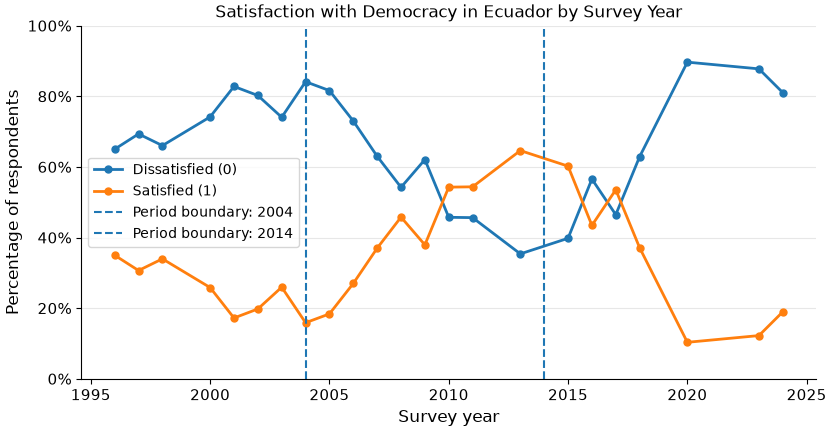

In [262]:
# =============================================================================
# TEMPORAL TREND OF SATISFACTION AND DISSATISFACTION
# =============================================================================

fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

ax.plot(
    yearly_target_proportions.index,
    yearly_target_proportions[0],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Dissatisfied (0)"
)

ax.plot(
    yearly_target_proportions.index,
    yearly_target_proportions[1],
    marker="o",
    linewidth=2,
    markersize=5,
    label="Satisfied (1)"
)

# Add vertical lines at the beginning of each new period.
for period in PERIOD_DEFINITIONS[1:]:
    ax.axvline(
        x=period["start_year"],
        linestyle="--",
        linewidth=1.5,
        label=f'Period boundary: {period["start_year"]}'
    )

ax.set_title("Satisfaction with Democracy in Ecuador by Survey Year")
ax.set_xlabel("Survey year")
ax.set_ylabel("Percentage of respondents")

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.grid(axis="y", alpha=0.3)
ax.legend(loc="center left")

fig.savefig(
    TEMPORAL_TRENDS_FIGURES_DIR / "satisfaction_democracy_by_year.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    TEMPORAL_TRENDS_FIGURES_DIR / "satisfaction_democracy_by_year.pdf",
    bbox_inches="tight"
)

plt.show()

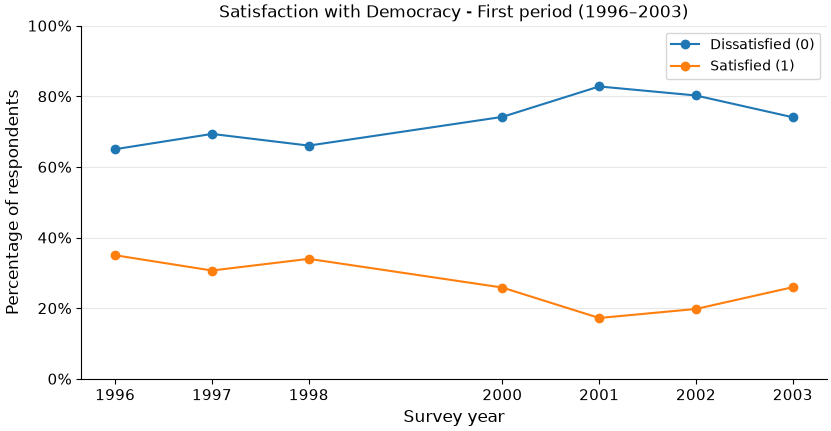

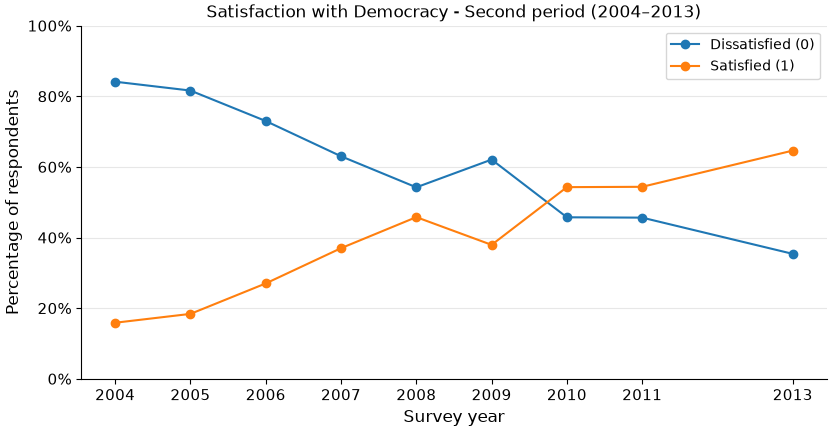

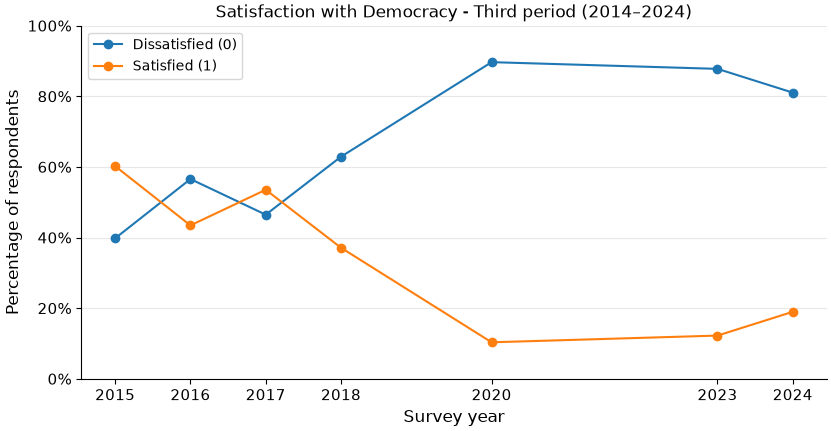

In [263]:
# =============================================================================
# TEMPORAL TREND BY HISTORICAL PERIOD
# =============================================================================

for period_definition in PERIOD_DEFINITIONS:
    period = period_definition["label"]
    start_year = period_definition["start_year"]
    end_year = period_definition["end_year"]

    df_period_plot = df_ecuador[df_ecuador["PERIODO"] == period]

    period_counts = pd.crosstab(
        df_period_plot["X_24"],
        df_period_plot[TARGET]
    ).sort_index()

    period_props = period_counts.div(
        period_counts.sum(axis=1),
        axis=0
    )

    period_label = PERIOD_DISPLAY_LABELS.get(
        period,
        period.replace("_", " ")
    )

    fig, ax = plt.subplots(
        figsize=FIGURE_SIZE_WIDE,
        constrained_layout=True
    )

    if 0 in period_props.columns:
        ax.plot(
            period_props.index,
            period_props[0],
            marker="o",
            label="Dissatisfied (0)"
        )

    if 1 in period_props.columns:
        ax.plot(
            period_props.index,
            period_props[1],
            marker="o",
            label="Satisfied (1)"
        )

    ax.set_title(
        f"Satisfaction with Democracy - {period_label} "
        f"({start_year}–{end_year})"
    )
    ax.set_xlabel("Survey year")
    ax.set_ylabel("Percentage of respondents")

    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    
    # Force all available survey years in the period to appear on the x-axis.
    ax.set_xticks(period_props.index)
    ax.set_xticklabels(period_props.index.astype(int), rotation=0)

    ax.grid(axis="y", alpha=0.3)
    ax.legend(loc="best")

    fig.savefig(
        TEMPORAL_TRENDS_FIGURES_DIR / f"satisfaction_democracy_{period}.png",
        dpi=FIGURE_DPI,
        bbox_inches="tight"
    )

    fig.savefig(
        TEMPORAL_TRENDS_FIGURES_DIR / f"satisfaction_democracy_{period}.pdf",
        bbox_inches="tight"
    )
    plt.show()

## Target Distribution by Historical Period

This section examines the distribution of satisfaction and dissatisfaction with democracy within each historical period.

In [264]:
# =============================================================================
# TARGET DISTRIBUTION BY PERIOD
# =============================================================================

target_by_period = pd.crosstab(
    df_ecuador["PERIODO"],
    df_ecuador[TARGET],
    margins=True
)

display(target_by_period)

target_by_period_pct = pd.crosstab(
    df_ecuador["PERIODO"],
    df_ecuador[TARGET],
    normalize="index"
) * 100

display(target_by_period_pct)

ETIQUETA,0,1,All
PERIODO,,,
1_Period,4017,1505,5522
2_Period,4051,2736,6787
3_Period,3672,1921,5593
All,11740,6162,17902


ETIQUETA,0,1
PERIODO,,
1_Period,72.745382,27.254618
2_Period,59.687638,40.312362
3_Period,65.653495,34.346505


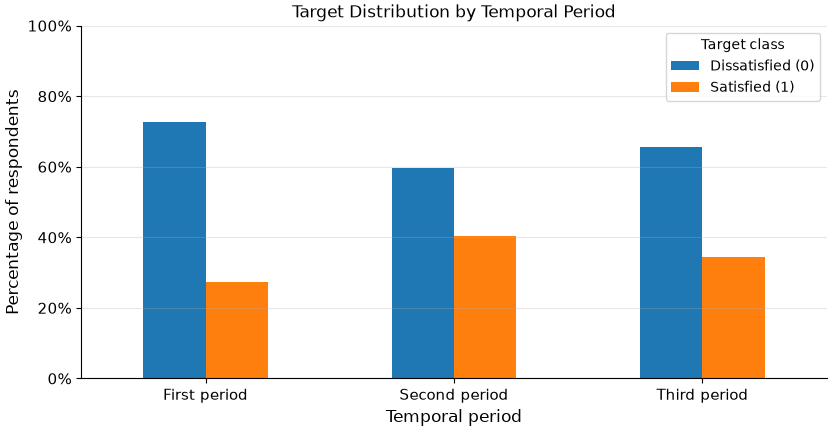

In [265]:
# =============================================================================
# PLOT TARGET DISTRIBUTION BY PERIOD
# =============================================================================

target_by_period_pct = (
    pd.crosstab(
        df_ecuador["PERIODO"],
        df_ecuador[TARGET],
        normalize="index"
    )
    .reindex(index=period_order)
    .reindex(columns=[0, 1], fill_value=0)
)

target_by_period_pct.index = [
    PERIOD_DISPLAY_LABELS.get(period, period.replace("_", " "))
    for period in target_by_period_pct.index
]

fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

target_by_period_pct.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Target Distribution by Temporal Period")
ax.set_xlabel("Temporal period")
ax.set_ylabel("Percentage of respondents")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend(
    labels=["Dissatisfied (0)", "Satisfied (1)"],
    title="Target class"
)

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_distribution_by_period.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_distribution_by_period.pdf",
    bbox_inches="tight"
)
plt.show()

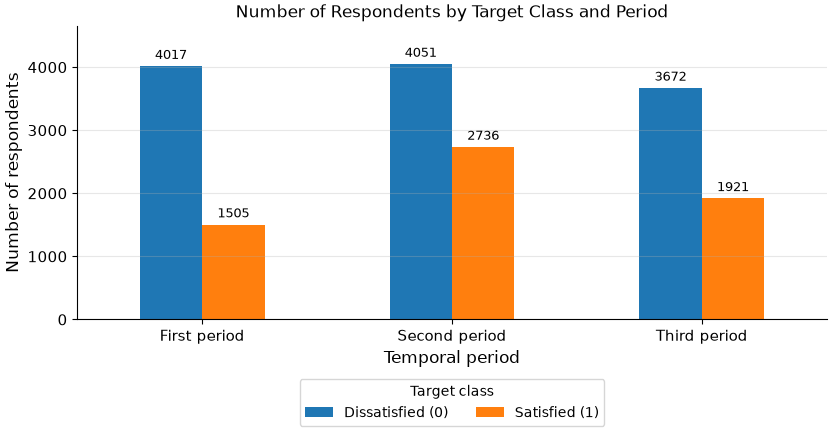

In [334]:
# =============================================================================
# PLOT TARGET COUNTS BY PERIOD
# =============================================================================

target_by_period_counts = (
    pd.crosstab(
        df_ecuador["PERIODO"],
        df_ecuador[TARGET]
    )
    .reindex(index=period_order)
    .reindex(columns=[0, 1], fill_value=0)
)

target_by_period_counts.index = [
    PERIOD_DISPLAY_LABELS.get(period, period.replace("_", " "))
    for period in target_by_period_counts.index
]

fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

target_by_period_counts.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Number of Respondents by Target Class and Period")
ax.set_xlabel("Temporal period")
ax.set_ylabel("Number of respondents")
ax.set_ylim(0, target_by_period_counts.values.max() * 1.15)

# Add values above each bar
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=3,
        fontsize=9
    )

ax.legend(
    labels=["Dissatisfied (0)", "Satisfied (1)"],
    title="Target class",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    # frameon=False
)

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=0)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_counts_by_period.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_counts_by_period.pdf",
    bbox_inches="tight"
)

plt.show()

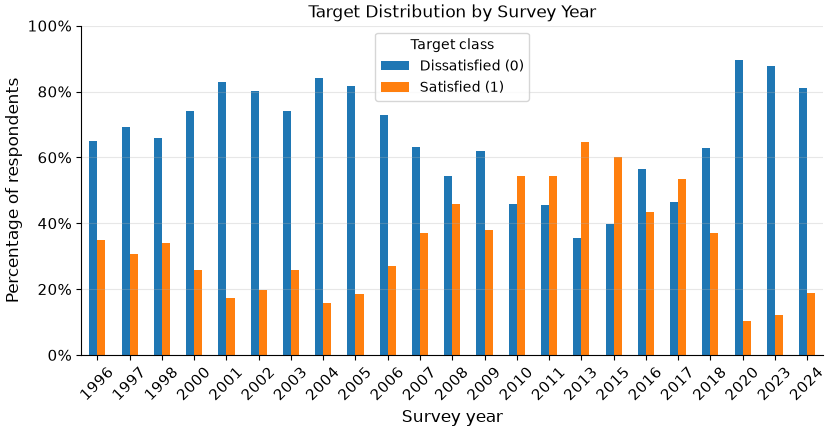

In [267]:
# =============================================================================
# PLOT YEARLY TARGET DISTRIBUTION
# =============================================================================

yearly_target_proportions = (
    pd.crosstab(
        df_ecuador["X_24"],
        df_ecuador[TARGET],
        normalize="index"
    )
    .sort_index()
    .reindex(columns=[0, 1], fill_value=0)
)

fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

yearly_target_proportions.plot(
    kind="bar",
    ax=ax
)

ax.set_title("Target Distribution by Survey Year")
ax.set_xlabel("Survey year")
ax.set_ylabel("Percentage of respondents")

ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(PercentFormatter(1.0))

ax.legend(
    labels=["Dissatisfied (0)", "Satisfied (1)"],
    title="Target class"
)

ax.grid(axis="y", alpha=0.3)

plt.xticks(rotation=45)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_distribution_by_year.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    TARGET_DISTRIBUTION_FIGURES_DIR / "target_distribution_by_year.pdf",
    bbox_inches="tight"
)
plt.show()

---

# PART 4 — Shared Modeling Setup

This part defines the functions, metrics, and preprocessing components shared by more than one experiment.

---

## Period-Specific Dataset Preparation

This section defines a function to extract predictors and the target variable for each historical period.

In [268]:
# =============================================================================
# DATASET PREPARATION BY PERIOD
# =============================================================================

def get_period_data(df, period, feature_columns, target):
    df_period = df[df["PERIODO"] == period].copy()

    data_model = df_period[feature_columns + [target]].copy()

    # The target variable should not be imputed.
    data_model = data_model.dropna(subset=[target])

    X = data_model[feature_columns].copy()
    y = data_model[target].astype(int).copy()

    print(f"\nPeriodo: {period}")
    print("Shape X:", X.shape)
    print("Shape y:", y.shape)
    print("Distribución del target:")
    print(y.value_counts())
    print("Distribución porcentual:")
    print(y.value_counts(normalize=True) * 100)

    return X, y

## Period-Specific Train/Test Split

This section defines a stratified train/test split for each historical period to preserve the target class distribution.

In [269]:
def split_period_data(X, y, test_size=0.20, random_state=42):
    """
    Split the data for a given historical period into training and test sets.

    The split is stratified to preserve the proportion of satisfied and
    dissatisfied respondents in both sets.
    """

    # Check that the target variable contains both classes: 0 and 1.
    # A classification model cannot be trained/evaluated properly if only
    # one class is present.
    if y.nunique() < 2:
        raise ValueError(
            "The selected period contains only one class in the target variable."
        )

    # Check the size of the minority class.
    # Stratified splitting requires enough observations from each class.
    min_class_count = y.value_counts().min()

    if min_class_count < 2:
        raise ValueError(
            "There are not enough observations in the minority class "
            "to perform a stratified train/test split."
        )

    # Stratified split preserves the class distribution of the target variable.
    # shuffle=True is appropriate here because the experiment is cross-sectional
    # within each historical period, not a temporal forecasting experiment.
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        stratify=y,
        shuffle=True,
        random_state=random_state
    )

    return X_train, X_test, y_train, y_test

## Evaluation Metrics

This section defines the metrics used to evaluate binary classification performance, with emphasis on class imbalance.

In [270]:
# Multiple metrics are used because the target variable is imbalanced.
# Accuracy alone can be misleading when one class is more frequent than the other.
SCORING = {
    # Overall proportion of correct predictions.
    # Useful as a general reference, but not sufficient under class imbalance.
    "accuracy": "accuracy",

    # Average recall across both classes.
    # More informative than accuracy when the classes are imbalanced.
    "balanced_accuracy": "balanced_accuracy",

    # Precision for the positive class: among predicted satisfied respondents,
    # how many were actually satisfied.
    # zero_division=0 avoids warnings if the model predicts no positive cases.
    "precision": make_scorer(precision_score, zero_division=0),

    # Recall for the positive class: among actually satisfied respondents,
    # how many were correctly identified.
    "recall": make_scorer(recall_score, zero_division=0),

    # Harmonic mean of precision and recall for the positive class.
    "f1": make_scorer(f1_score, zero_division=0),

    # Average F1-score across both classes.
    # This is the main metric used for model selection because both
    # satisfaction and dissatisfaction are relevant in this analysis.
    "f1_macro": make_scorer(f1_score, average="macro", zero_division=0),

    # Measures the model's ability to rank positive cases above negative cases.
    # Requires predicted probabilities or decision scores.
    "roc_auc": "roc_auc"
}

## Base Preprocessing Pipeline

This preprocessing pipeline is used by the class-weight (Exp1) and the RandomOverSampler (Exp2). SMOTENC (Exp3) requires a different preprocessing strategy because categorical variables must be handled before synthetic oversampling.

In [271]:
def build_preprocessor(scale_numeric=True):
    """
    Build a preprocessing pipeline for the feature groups.

    Parameters
    ----------
    scale_numeric : bool
        If True, numeric and ordinal variables are standardized.
        This is useful for linear models such as Logistic Regression.

        If False, numeric and ordinal variables are not standardized.
        This is appropriate for tree-based models such as Decision Tree
        and Random Forest, which do not require feature scaling.
    """

    # Numeric variables, such as age, are imputed with the median.
    # They are scaled only for models that are sensitive to feature magnitude.
    if scale_numeric:
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]

        # Ordinal variables are imputed with the most frequent value.
        # They are scaled for linear models to make regularization comparable
        # across variables with different ranges.
        ordinal_steps = [
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("scaler", StandardScaler())
        ]

    else:
        numeric_steps = [
            ("imputer", SimpleImputer(strategy="median"))
        ]

        ordinal_steps = [
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]

    numeric_transformer = Pipeline(steps=numeric_steps)
    ordinal_transformer = Pipeline(steps=ordinal_steps)

    # Binary variables are already coded as 0/1.
    # Missing values, if any, are replaced with the most frequent value.
    binary_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent"))
        ]
    )

    # Nominal categorical variables are not ordered.
    # They are imputed and then encoded using one-hot encoding.
    # handle_unknown="ignore" prevents errors when a category appears in
    # validation/test data but was not present in the training fold.
    # drop=None keeps all categories, avoiding ambiguity with unseen categories.
    nominal_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop=None
                )
            )
        ]
    )

    # ColumnTransformer applies the appropriate preprocessing strategy
    # to each conceptual group of variables.
    preprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, numeric_features),
            ("ordinal", ordinal_transformer, ordinal_features),
            ("binary", binary_transformer, binary_features),
            ("nominal", nominal_transformer, nominal_features),
        ],
        remainder="drop"
    )

    return preprocessor


# Preprocessor for linear models.
# Logistic Regression benefits from scaling numeric and ordinal variables.
preprocessor_linear = build_preprocessor(scale_numeric=True)

# Preprocessor for tree-based models.
# Decision Tree and Random Forest do not require feature scaling.
preprocessor_tree = build_preprocessor(scale_numeric=False)

## Model Evaluation Function

This section defines a reusable function to evaluate fitted models using classification metrics and a confusion matrix.

In [272]:
def evaluate_model(
    model_name,
    period,
    fitted_model,
    X_test,
    y_test,
    period_display_labels=None,
    experiment=None,
    save_confusion_matrix=True,
    confusion_matrices_figures_dir=CONFUSION_MATRICES_FIGURES_DIR
):
    """
    Evaluate a fitted classification model on the test set.

    The function prints a classification report, displays a confusion matrix,
    computes the main evaluation metrics, stores confusion matrix values,
    exports confusion matrix figures/tables, and returns all results as a dictionary.
    """

    period_label = (
        period_display_labels.get(period, period)
        if period_display_labels is not None
        else period
    )

    experiment_label = experiment if experiment is not None else "Unspecified experiment"

    # Generate class predictions on the test set.
    y_pred = fitted_model.predict(X_test)

    # Predicted probabilities are needed to compute ROC-AUC.
    if hasattr(fitted_model, "predict_proba"):
        y_proba = fitted_model.predict_proba(X_test)[:, 1]
    else:
        y_proba = None

    print("\n" + "=" * 80)
    print(f"Experiment: {experiment_label}")
    print(f"Period: {period_label}")
    print(f"Model: {model_name}")
    print("=" * 80)

    print("\nClassification report:")
    report_text = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Dissatisfied (0)", "Satisfied (1)"],
        digits=4,
        zero_division=0
    )
    print(report_text)

    report_dict = classification_report(
        y_test,
        y_pred,
        labels=[0, 1],
        target_names=["Dissatisfied (0)", "Satisfied (1)"],
        digits=4,
        zero_division=0,
        output_dict=True
    )

    # Force class order: rows = true classes, columns = predicted classes.
    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    print("\nConfusion matrix:")
    print(cm)
    print(f"TN: {tn}, FP: {fp}, FN: {fn}, TP: {tp}")

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Dissatisfied (0)", "Satisfied (1)"]
    )
    disp.plot()
    plt.title(f"{model_name} - {period_label}")
    plt.tight_layout()

    if save_confusion_matrix:
        experiment_folder = make_safe_filename(experiment_label)
        period_folder = make_safe_filename(period_label)
        model_file = make_safe_filename(model_name)

        export_dir = (
            confusion_matrices_figures_dir
            / experiment_folder
            / period_folder
        )
        export_dir.mkdir(parents=True, exist_ok=True)

        figure_base = export_dir / f"confusion_matrix_{model_file}"

        plt.savefig(
            figure_base.with_suffix(".png"),
            dpi=FIGURE_DPI,
            bbox_inches="tight"
        )

        plt.savefig(
            figure_base.with_suffix(".pdf"),
            bbox_inches="tight"
        )

        confusion_matrix_df = pd.DataFrame(
            cm,
            index=["Actual dissatisfied (0)", "Actual satisfied (1)"],
            columns=["Predicted dissatisfied (0)", "Predicted satisfied (1)"]
        )

        confusion_matrix_df.to_csv(
            export_dir / f"confusion_matrix_{model_file}.csv"
        )

        pd.DataFrame(report_dict).T.to_csv(
            export_dir / f"classification_report_{model_file}.csv"
        )

    plt.show()

    metrics = {
        "experiment": experiment_label,
        "period": period,
        "period_label": period_label,
        "model": model_name,

        "accuracy": accuracy_score(y_test, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_test, y_pred),

        # Positive class: Satisfied (1)
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),

        # Main comparison metric
        "f1_macro": f1_score(
            y_test,
            y_pred,
            average="macro",
            zero_division=0
        ),

        # Class-specific metrics from the classification report
        "precision_dissatisfied": report_dict["Dissatisfied (0)"]["precision"],
        "recall_dissatisfied": report_dict["Dissatisfied (0)"]["recall"],
        "f1_dissatisfied": report_dict["Dissatisfied (0)"]["f1-score"],
        "support_dissatisfied": report_dict["Dissatisfied (0)"]["support"],

        "precision_satisfied": report_dict["Satisfied (1)"]["precision"],
        "recall_satisfied": report_dict["Satisfied (1)"]["recall"],
        "f1_satisfied": report_dict["Satisfied (1)"]["f1-score"],
        "support_satisfied": report_dict["Satisfied (1)"]["support"],

        # Confusion matrix values
        "true_negative": tn,
        "false_positive": fp,
        "false_negative": fn,
        "true_positive": tp
    }

    if y_proba is not None and y_test.nunique() == 2:
        metrics["roc_auc"] = roc_auc_score(y_test, y_proba)
    else:
        metrics["roc_auc"] = np.nan

    # Store GridSearchCV information if available.
    if hasattr(fitted_model, "best_params_"):
        metrics["best_params"] = fitted_model.best_params_

    if hasattr(fitted_model, "best_score_"):
        metrics["best_cv_score"] = fitted_model.best_score_

    return metrics


---

# PART 5 — Experiment 1: Class Weight Grid

This part evaluates the first modeling strategy, where class imbalance is handled through class weights inside the hyperparameter grid.

---

## Class Weight Grid Model Configuration

This section defines the models and hyperparameter grids used in the class-weight experiment, including Logistic Regression, Decision Tree, and Random Forest.

In [273]:
# Each model is defined together with:
# - its corresponding preprocessor
# - the classifier
# - the hyperparameter grid used by GridSearchCV
#
# The prefix "classifier__" is required because the classifier will be inside
# a Pipeline step named "classifier".

model_configs = {
    "Logistic Regression": {
        # Logistic Regression is sensitive to feature scale.
        # Therefore, it uses the preprocessor with StandardScaler.
        "preprocessor": preprocessor_linear,

        "model": LogisticRegression(
            max_iter=10000,
            solver="saga",  # Compatible with L1, L2, and Elastic Net via l1_ratio.
            random_state=RANDOM_STATE
        ),

        "params": {
            # C controls regularization strength.
            # Smaller C = stronger regularization.
            # Larger C = weaker regularization.
            "classifier__C": [0.01, 0.1, 1, 10],

            # l1_ratio controls the type of regularization:
            # 0.0 = L2
            # 0.5 = Elastic Net
            # 1.0 = L1
            "classifier__l1_ratio": [0.0, 0.5, 1.0],

            # class_weight="balanced" gives more weight to the minority class.
            "classifier__class_weight": [None, "balanced"]
        }
    },

    "Decision Tree": {
        # Tree-based models do not require feature scaling.
        "preprocessor": preprocessor_tree,

        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ),

        "params": {
            # Criterion used to measure the quality of each split.
            "classifier__criterion": ["gini", "entropy", "log_loss"],

            # Controls tree complexity.
            # None allows the tree to grow until stopping conditions are reached.
            "classifier__max_depth": [3, 5, 10, 15, None],

            # Minimum number of samples required to split an internal node.
            # Larger values make the tree more conservative.
            "classifier__min_samples_split": [2, 5, 10],

            # Minimum number of samples required in a leaf node.
            # Larger values reduce overfitting.
            "classifier__min_samples_leaf": [1, 2, 5, 10],

            # Handles class imbalance by weighting classes inversely
            # proportional to their frequency.
            "classifier__class_weight": [None, "balanced"],

            # Cost-complexity pruning parameter.
            # Higher values produce simpler, more pruned trees.
            "classifier__ccp_alpha": [0.0, 0.001, 0.01]
        }
    },

    "Random Forest": {
        # Random Forest is tree-based, so scaling is not required.
        "preprocessor": preprocessor_tree,

        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1  # Uses all available CPU cores.
        ),

        "params": {
            # Number of trees in the forest.
            # More trees usually improve stability but increase computation time.
            "classifier__n_estimators": [200, 500],

            # Maximum depth of each tree.
            # None allows trees to grow fully, which may increase overfitting.
            "classifier__max_depth": [5, 10, None],

            # Minimum number of samples required in a leaf node.
            # Larger values reduce overfitting.
            "classifier__min_samples_leaf": [1, 5, 10],

            # Number of features considered at each split.
            # "sqrt" is a common default for classification.
            "classifier__max_features": ["sqrt", "log2"],

            # Handles class imbalance.
            # "balanced" uses class frequencies from the full training set.
            # "balanced_subsample" computes weights within each bootstrap sample.
            "classifier__class_weight": [None, "balanced", "balanced_subsample"]

            # Optional parameters for a larger grid:
            # "classifier__criterion": ["gini", "entropy"],
            # "classifier__min_samples_split": [2, 5, 10],
        }
    }
}

## Class Weight Grid Training Function

This section defines the training function for the class-weight experiment using preprocessing, cross-validation, and GridSearchCV.

In [274]:
def train_model_with_grid_search(
    model_name,
    config,
    X_train,
    y_train,
    random_state=42
):
    """
    Train a classification model using a Pipeline and GridSearchCV.

    The function builds a complete modeling pipeline with preprocessing and
    classification, performs stratified cross-validation, searches over the
    model-specific hyperparameter grid, and returns the fitted GridSearchCV
    object.
    """

    # The number of CV folds cannot exceed the number of observations
    # in the minority class. This avoids invalid stratified folds.
    min_class_count = y_train.value_counts().min()
    n_splits = min(5, min_class_count)

    if n_splits < 2:
        raise ValueError(
            "There are not enough observations in the minority class "
            "to perform cross-validation."
        )

    # StratifiedKFold preserves the class distribution in each fold.
    # shuffle=True is appropriate because this is a cross-sectional
    # classification task within each historical period.
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # The pipeline ensures that preprocessing is fitted only on the training
    # portion of each cross-validation fold, avoiding data leakage.
    pipeline = Pipeline(
        steps=[
            ("preprocessor", config["preprocessor"]),
            ("classifier", config["model"])
        ]
    )

    # GridSearchCV evaluates all hyperparameter combinations using the
    # specified cross-validation strategy and scoring metrics.
    # refit=REFIT_METRIC means the final model is refitted using the best
    # hyperparameters according to the selected main metric.
    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring=SCORING,
        refit=REFIT_METRIC,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\nBest model: {model_name}")
    print("Best params:")
    print(grid_search.best_params_)
    print(f"Best CV {REFIT_METRIC}: {grid_search.best_score_:.4f}")

    return grid_search

## Run Class Weight Grid Models by Historical Period

This section trains and evaluates the class-weight grid models independently for each historical period.


####################################################################################################
Running models for period: 1_Period
####################################################################################################

Periodo: 1_Period
Shape X: (5522, 21)
Shape y: (5522,)
Distribución del target:
ETIQUETA
0    4017
1    1505
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    72.745382
1    27.254618
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression
--------------------------------------------------------------------------------
Fitting 5 folds for each of 24 candidates, totalling 120 fits



Best model: Logistic Regression
Best params:
{'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 0.0}
Best CV f1_macro: 0.5633

Experiment: Class weight grid
Period: First period
Model: Logistic Regression

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7906    0.6244    0.6977       804
   Satisfied (1)     0.3574    0.5581    0.4358       301

        accuracy                         0.6063      1105
       macro avg     0.5740    0.5913    0.5668      1105
    weighted avg     0.6726    0.6063    0.6264      1105


Confusion matrix:
[[502 302]
 [133 168]]
TN: 502, FP: 302, FN: 133, TP: 168


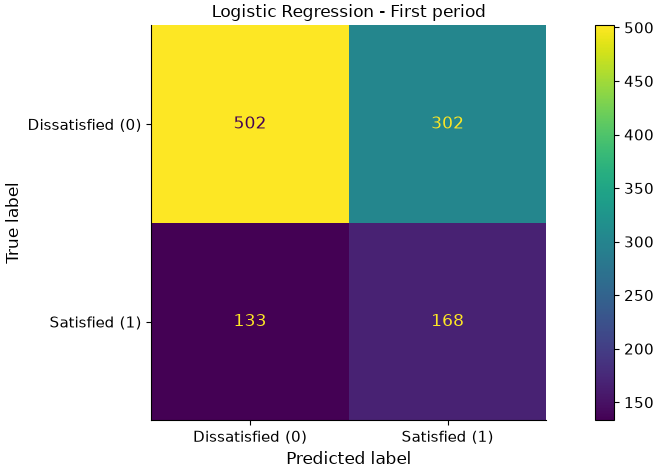


--------------------------------------------------------------------------------
Training model: Decision Tree
--------------------------------------------------------------------------------
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits

Best model: Decision Tree
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.5612

Experiment: Class weight grid
Period: First period
Model: Decision Tree

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7805    0.7786    0.7796       804
   Satisfied (1)     0.4125    0.4153    0.4139       301

        accuracy                         0.6796      1105
       macro avg     0.5965    0.5969    0.5967      1105
    weighted avg     0.6803    0.6796    0.6800      1105


Confusion matrix:
[[626 178]

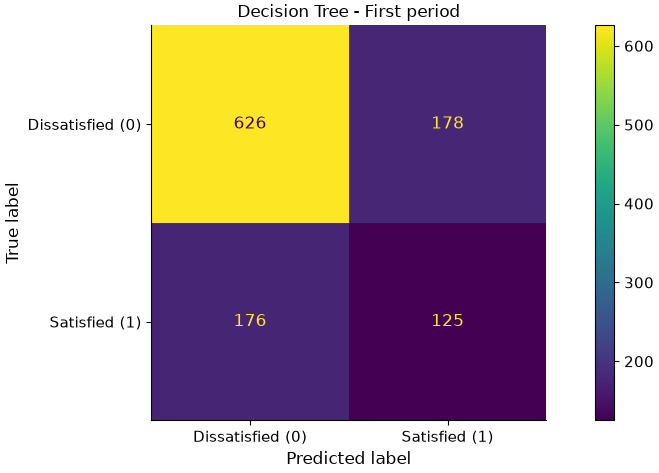


--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best model: Random Forest
Best params:
{'classifier__class_weight': 'balanced', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best CV f1_macro: 0.6051

Experiment: Class weight grid
Period: First period
Model: Random Forest

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7836    0.7475    0.7651       804
   Satisfied (1)     0.3994    0.4485    0.4225       301

        accuracy                         0.6661      1105
       macro avg     0.5915    0.5980    0.5938      1105
    weighted avg     0.6789    0.6661    0.6718      1105


Confusion matrix:
[[601 203]
 [166 135]]
TN: 601, FP: 

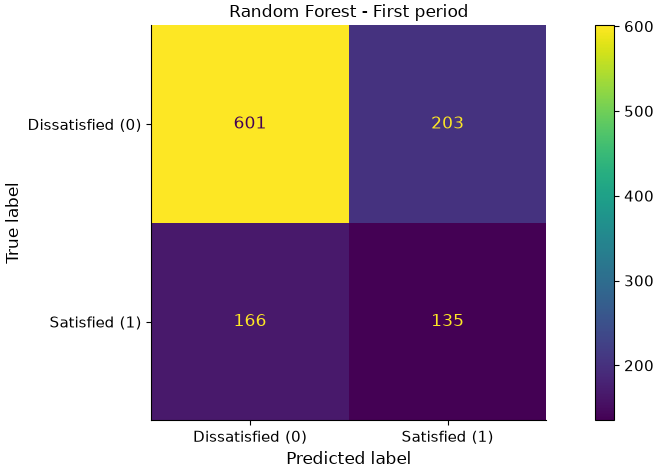


####################################################################################################
Running models for period: 2_Period
####################################################################################################

Periodo: 2_Period
Shape X: (6787, 21)
Shape y: (6787,)
Distribución del target:
ETIQUETA
0    4051
1    2736
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    59.687638
1    40.312362
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression
--------------------------------------------------------------------------------
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best model: Logistic Regression
Best params:
{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__l1_ratio': 1.0}
Best CV f1_macro: 0.6810

Experiment: Class weight grid
Period: Second period
Model: Logistic Regression

Classification report:
      

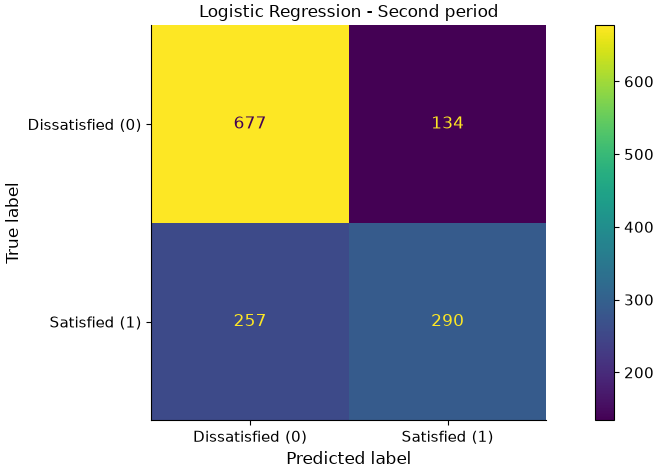


--------------------------------------------------------------------------------
Training model: Decision Tree
--------------------------------------------------------------------------------
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits

Best model: Decision Tree
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6591

Experiment: Class weight grid
Period: Second period
Model: Decision Tree

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7169    0.7867    0.7501       811
   Satisfied (1)     0.6303    0.5393    0.5813       547

        accuracy                         0.6870      1358
       macro avg     0.6736    0.6630    0.6657      1358
    weighted avg     0.6820    0.6870    0.6821      1358


Confusion matrix:
[[638 

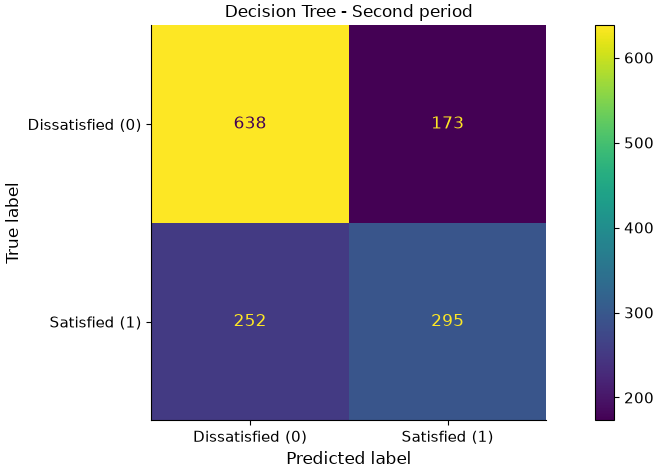


--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best model: Random Forest
Best params:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 500}
Best CV f1_macro: 0.6911

Experiment: Class weight grid
Period: Second period
Model: Random Forest

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7358    0.7657    0.7505       811
   Satisfied (1)     0.6304    0.5923    0.6107       547

        accuracy                         0.6959      1358
       macro avg     0.6831    0.6790    0.6806      1358
    weighted avg     0.6933    0.6959    0.6942      1358


Confusion matrix:
[[621 190]
 [223 324]]
TN

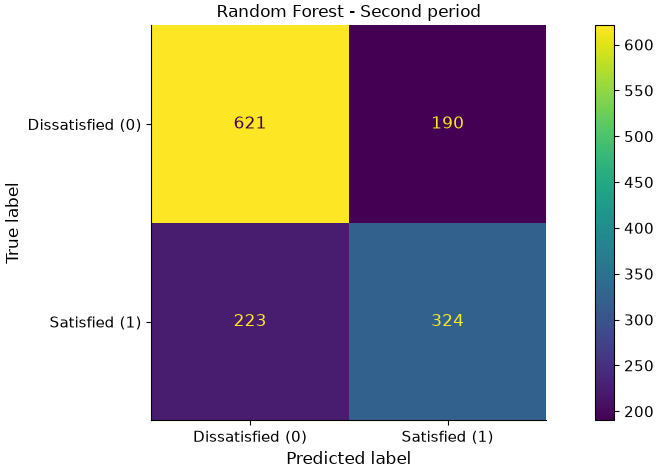


####################################################################################################
Running models for period: 3_Period
####################################################################################################

Periodo: 3_Period
Shape X: (5593, 21)
Shape y: (5593,)
Distribución del target:
ETIQUETA
0    3672
1    1921
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    65.653495
1    34.346505
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression
--------------------------------------------------------------------------------
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best model: Logistic Regression
Best params:
{'classifier__C': 0.1, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.0}
Best CV f1_macro: 0.7006

Experiment: Class weight grid
Period: Third period
Model: Logistic Regression

Classification report:
       

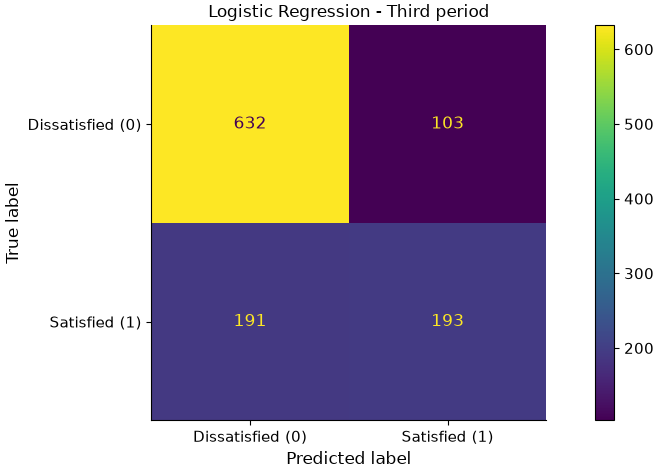


--------------------------------------------------------------------------------
Training model: Decision Tree
--------------------------------------------------------------------------------
Fitting 5 folds for each of 1080 candidates, totalling 5400 fits

Best model: Decision Tree
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6970

Experiment: Class weight grid
Period: Third period
Model: Decision Tree

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7705    0.8041    0.7870       735
   Satisfied (1)     0.5909    0.5417    0.5652       384

        accuracy                         0.7140      1119
       macro avg     0.6807    0.6729    0.6761      1119
    weighted avg     0.7089    0.7140    0.7109      1119


Confusion matrix:
[[591 1

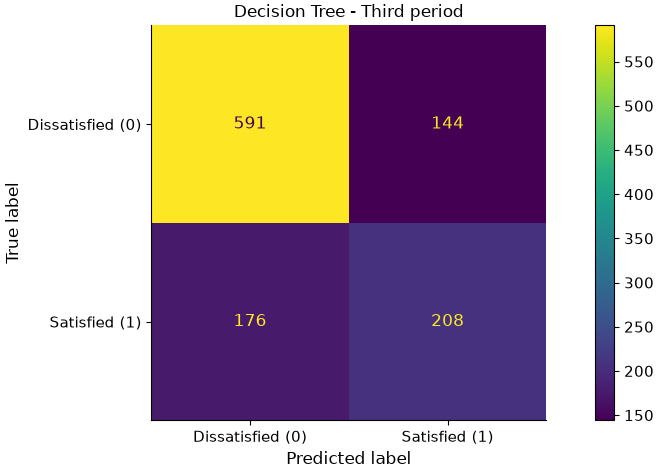


--------------------------------------------------------------------------------
Training model: Random Forest
--------------------------------------------------------------------------------
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Best model: Random Forest
Best params:
{'classifier__class_weight': 'balanced_subsample', 'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV f1_macro: 0.7096

Experiment: Class weight grid
Period: Third period
Model: Random Forest

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.8158    0.7891    0.8022       735
   Satisfied (1)     0.6201    0.6589    0.6389       384

        accuracy                         0.7444      1119
       macro avg     0.7179    0.7240    0.7206      1119
    weighted avg     0.7486    0.7444    0.7462      1119


Confusion matrix:
[[580 155]
 [131 253]]
TN:

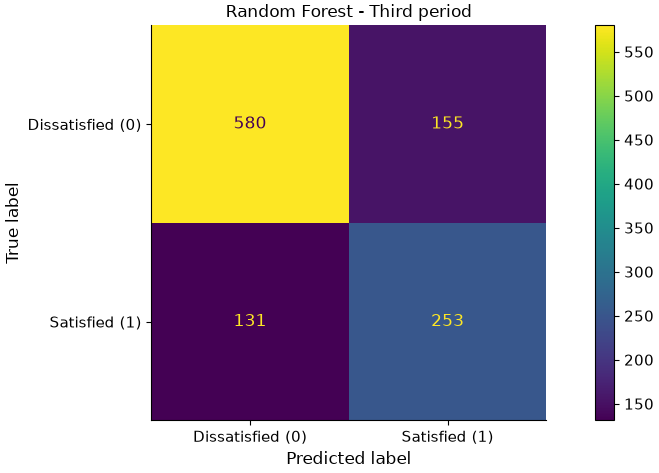

In [275]:
# Store the evaluation metrics for every model-period combination.
# This list will later be converted into a results DataFrame.
all_results = []

# Store the fitted GridSearchCV objects.
# The key is a tuple: (period, model_name).
# This allows retrieving the best trained model for any specific period/model.
all_best_models = {}

for period in periods:
    print("\n" + "#" * 100)
    print(f"Running models for period: {period}")
    print("#" * 100)

    # Extract predictors and target for the current historical period.
    X_period, y_period = get_period_data(
        df=df_ecuador,
        period=period,
        feature_columns=feature_columns,
        target=TARGET
    )

    # Split the period-specific data into train and test sets.
    # The split is stratified to preserve the class distribution.
    X_train, X_test, y_train, y_test = split_period_data(
        X=X_period,
        y=y_period,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    # The held-out test set is not used during hyperparameter tuning.
    # GridSearchCV performs cross-validation only on X_train and y_train.
    # After selecting the best hyperparameters according to REFIT_METRIC,
    # the best model is refitted on the full training set and evaluated once
    # on X_test.
    for model_name, config in model_configs.items():
        print("\n" + "-" * 80)
        print(f"Training model: {model_name}")
        print("-" * 80)

        # Train the model using preprocessing, cross-validation,
        # and grid search for hyperparameter tuning.
        fitted_model = train_model_with_grid_search(
            model_name=model_name,
            config=config,
            X_train=X_train,
            y_train=y_train,
            random_state=RANDOM_STATE
        )

        # Evaluate the best model on the held-out test set.
        metrics = evaluate_model(
            model_name=model_name,
            period=period,
            fitted_model=fitted_model,
            X_test=X_test,
            y_test=y_test,
            period_display_labels=PERIOD_DISPLAY_LABELS,
            experiment="Class weight grid",
            save_confusion_matrix=True
        )

        # Save metrics for the final comparison table.
        all_results.append(metrics)

        # Save fitted model for later inspection, interpretation,
        # feature importance, or prediction.
        all_best_models[(period, model_name)] = fitted_model

## Class Weight Grid Results Summary Table

This section summarizes the performance metrics of all class-weight grid models across historical periods.

In [276]:
# Convert the list of metric dictionaries into a DataFrame.
# Each row represents one model evaluated in one historical period.
results_df = pd.DataFrame(all_results)

# Sort results within each period according to the main model-selection metric.
# The best-performing models for each period will appear first.
results_df = results_df.sort_values(
    by=["period", REFIT_METRIC],
    ascending=[True, False]
)

display(results_df)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
1,Class weight grid,1_Period,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153
2,Class weight grid,1_Period,First period,Random Forest,0.666063,0.598009,0.399408,0.448505,0.422535,0.593826,0.783572,0.747512,0.765118,804.0,0.399408,0.448505,0.422535,301.0,601,203,166,135,0.670105,"{'classifier__class_weight': 'balanced', 'clas...",0.605075
0,Class weight grid,1_Period,First period,Logistic Regression,0.606335,0.591259,0.357447,0.558140,0.435798,0.566752,0.790551,0.624378,0.697707,804.0,0.357447,0.558140,0.435798,301.0,502,302,133,168,0.630758,"{'classifier__C': 0.01, 'classifier__class_wei...",0.563333
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978
5,Class weight grid,2_Period,Second period,Random Forest,0.695876,0.679022,0.630350,0.592322,0.610745,0.680599,0.735782,0.765721,0.750453,811.0,0.630350,0.592322,0.610745,547.0,621,190,223,324,0.751941,{'classifier__class_weight': 'balanced_subsamp...,0.691099
4,Class weight grid,2_Period,Second period,Decision Tree,0.687040,0.662994,0.630342,0.539305,0.581281,0.665714,0.716854,0.786683,0.750147,811.0,0.630342,0.539305,0.581281,547.0,638,173,252,295,0.718052,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.659088
8,Class weight grid,3_Period,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552
6,Class weight grid,3_Period,Third period,Logistic Regression,0.737265,0.681234,0.652027,0.502604,0.567647,0.689472,0.767922,0.859864,0.811297,735.0,0.652027,0.502604,0.567647,384.0,632,103,191,193,0.788683,"{'classifier__C': 0.1, 'classifier__class_weig...",0.700621
7,Class weight grid,3_Period,Third period,Decision Tree,0.714030,0.672874,0.590909,0.541667,0.565217,0.676084,0.770535,0.804082,0.786951,735.0,0.590909,0.541667,0.565217,384.0,591,144,176,208,0.745966,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.696965


## Best Class Weight Grid Model by Historical Period

This section summarizes the performance metrics of all class-weight grid models across historical periods.

In [277]:
# Select the best-performing model for each historical period.
# The ranking criterion is the global REFIT_METRIC used in GridSearchCV.
# This keeps model selection consistent across training and reporting.
best_by_period = (
    results_df
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
)

# Display one best model per historical period.
display(best_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
1,Class weight grid,1_Period,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978
8,Class weight grid,3_Period,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552


---

# PART 6 — Experiment 2: RandomOverSampler

This section evaluates whether balancing the training data with `RandomOverSampler` improves the classification of the minority class.

`RandomOverSampler` duplicates real observations from the minority class instead of generating synthetic cases. This makes it simpler and more interpretable than SMOTE for this dataset, which contains several categorical survey variables.

The oversampling step is applied only to the training data inside the cross-validation process. The test set remains untouched and is used only for final evaluation.

---

## RandomOverSampler Model Configuration

This section defines the models and hyperparameter grids used in the RandomOverSampler experiment.

In [278]:
# =============================================================================
# MODEL CONFIGURATION WITH RANDOMOVERSAMPLER
# =============================================================================

# These configurations are used for the RandomOverSampler robustness check.
# The goal is to evaluate whether oversampling the minority class improves
# model performance, especially recall and F1-score for the satisfied class.

model_configs_ros = {
    "Logistic Regression + ROS": {
        "preprocessor": preprocessor_linear,
        "model": LogisticRegression(
            max_iter=10000,
            solver="saga",
            random_state=RANDOM_STATE,
            class_weight=None  # Class balancing is handled by RandomOverSampler.
        ),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__l1_ratio": [0.0, 0.5, 1.0]
        }
    },

    "Decision Tree + ROS": {
        "preprocessor": preprocessor_tree,
        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight=None  # Class balancing is handled by RandomOverSampler.
        ),
        "params": {
            "classifier__criterion": ["gini", "entropy", "log_loss"],
            "classifier__max_depth": [3, 5, 10, 15, None],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 5, 10],
            "classifier__ccp_alpha": [0.0, 0.001, 0.01]
        }
    },

    "Random Forest + ROS": {
        "preprocessor": preprocessor_tree,
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight=None  # Class balancing is handled by RandomOverSampler.
        ),
        "params": {
            "classifier__n_estimators": [200, 500],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__max_features": ["sqrt", "log2"]
        }
    }
}

## RandomOverSampler Training Function

This section defines the training function that combines preprocessing, RandomOverSampler, cross-validation, and GridSearchCV.

In [279]:
def train_model_with_random_oversampling(
    model_name,
    config,
    X_train,
    y_train,
    random_state=42
):
    """
    Train a classification model using preprocessing, RandomOverSampler,
    and GridSearchCV.

    RandomOverSampler is applied only inside the cross-validation training
    folds. This avoids data leakage because the validation folds and test set
    are not oversampled.
    """

    # The number of CV folds cannot exceed the number of observations
    # in the minority class.
    min_class_count = y_train.value_counts().min()
    n_splits = min(5, min_class_count)

    if n_splits < 2:
        raise ValueError(
            "There are not enough observations in the minority class "
            "to perform cross-validation."
        )

    # Stratified cross-validation preserves the original class distribution
    # in each fold before oversampling is applied to the training portion.
    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # ImbPipeline is required because RandomOverSampler changes the number
    # of training observations. A standard sklearn Pipeline is not appropriate
    # for resampling steps.
    pipeline = ImbPipeline(
        steps=[
            ("preprocessor", config["preprocessor"]),

            # RandomOverSampler duplicates minority-class observations
            # only in the training fold during cross-validation.
            ("oversampler", RandomOverSampler(random_state=random_state)),

            ("classifier", config["model"])
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring=SCORING,
        refit=REFIT_METRIC,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\nBest model: {model_name}")
    print("Best params:")
    print(grid_search.best_params_)
    print(f"Best CV {REFIT_METRIC}: {grid_search.best_score_:.4f}")

    return grid_search

## Run RandomOverSampler Models by Historical Period

This section trains and evaluates RandomOverSampler models independently for each historical period.


####################################################################################################
Running RandomOverSampler models for period: 1_Period
####################################################################################################

Periodo: 1_Period
Shape X: (5522, 21)
Shape y: (5522,)
Distribución del target:
ETIQUETA
0    4017
1    1505
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    72.745382
1    27.254618
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + ROS
Best params:
{'classifier__C': 0.01, 'classifier__l1_ratio': 0.5}
Best CV f1_macro: 0.5634

Experiment: RandomOverSampler
Period: First period
Model: Logistic Regression + ROS

Classification report:
     

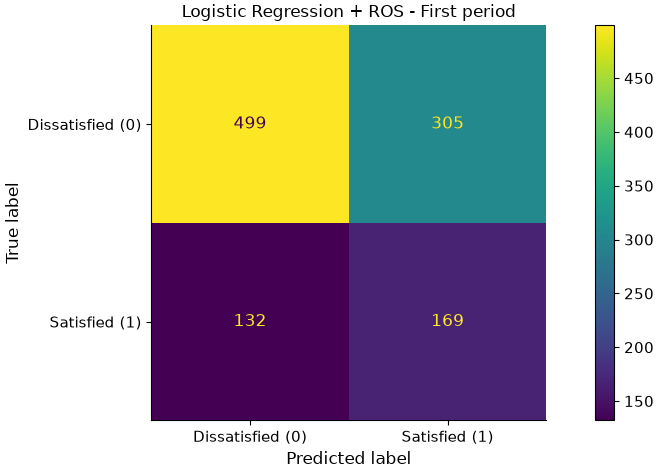


--------------------------------------------------------------------------------
Training model: Decision Tree + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + ROS
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.5576

Experiment: RandomOverSampler
Period: First period
Model: Decision Tree + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7713    0.7214    0.7455       804
   Satisfied (1)     0.3654    0.4286    0.3945       301

        accuracy                         0.6416      1105
       macro avg     0.5684    0.5750    0.5700      1105
    weighted avg     0.6607    0.6416    0.6499      1105


Confusion matrix:
[[580 224]
 [172 129]]
T

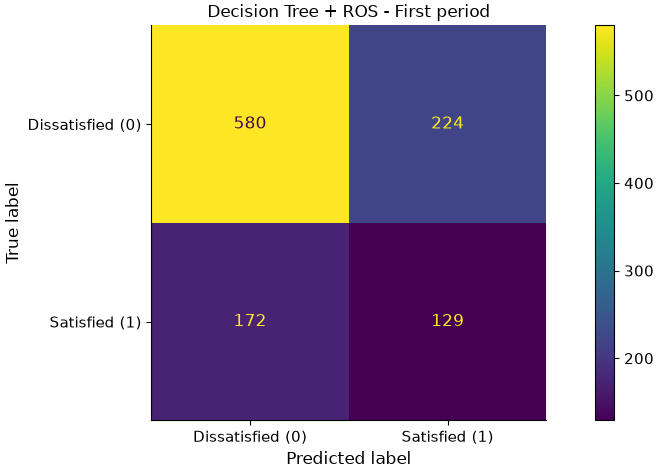


--------------------------------------------------------------------------------
Training model: Random Forest + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best model: Random Forest + ROS
Best params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV f1_macro: 0.5989

Experiment: RandomOverSampler
Period: First period
Model: Random Forest + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7691    0.8159    0.7918       804
   Satisfied (1)     0.4127    0.3455    0.3761       301

        accuracy                         0.6878      1105
       macro avg     0.5909    0.5807    0.5840      1105
    weighted avg     0.6720    0.6878    0.6786      1105


Confusion matrix:
[[656 148]
 [197 104]]
TN: 656, FP: 148, FN: 197, TP: 104


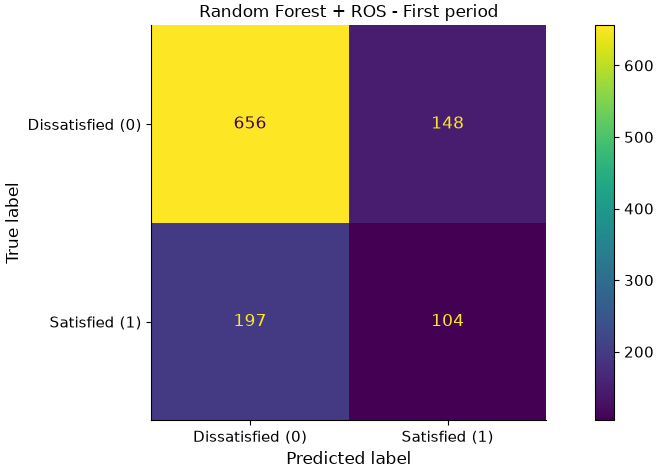


####################################################################################################
Running RandomOverSampler models for period: 2_Period
####################################################################################################

Periodo: 2_Period
Shape X: (6787, 21)
Shape y: (6787,)
Distribución del target:
ETIQUETA
0    4051
1    2736
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    59.687638
1    40.312362
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + ROS
Best params:
{'classifier__C': 0.1, 'classifier__l1_ratio': 1.0}
Best CV f1_macro: 0.6741

Experiment: RandomOverSampler
Period: Second period
Model: Logistic Regression + ROS

Classification report:
     

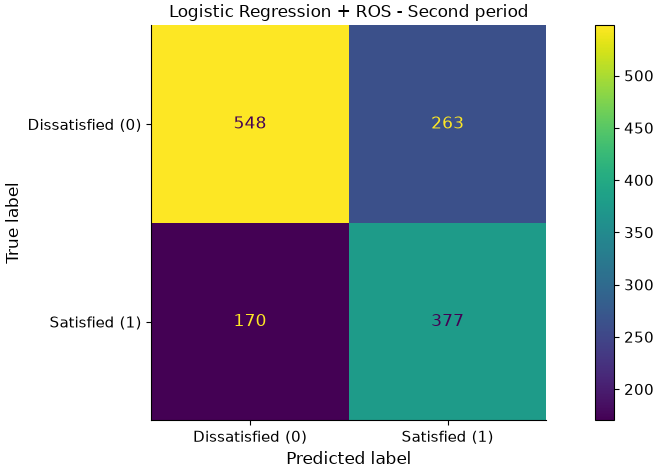


--------------------------------------------------------------------------------
Training model: Decision Tree + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + ROS
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 10, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6629

Experiment: RandomOverSampler
Period: Second period
Model: Decision Tree + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7518    0.5117    0.6090       811
   Satisfied (1)     0.5087    0.7495    0.6061       547

        accuracy                         0.6075      1358
       macro avg     0.6302    0.6306    0.6075      1358
    weighted avg     0.6539    0.6075    0.6078      1358


Confusion matrix:
[[415 396]
 [137 410]]
TN: 4

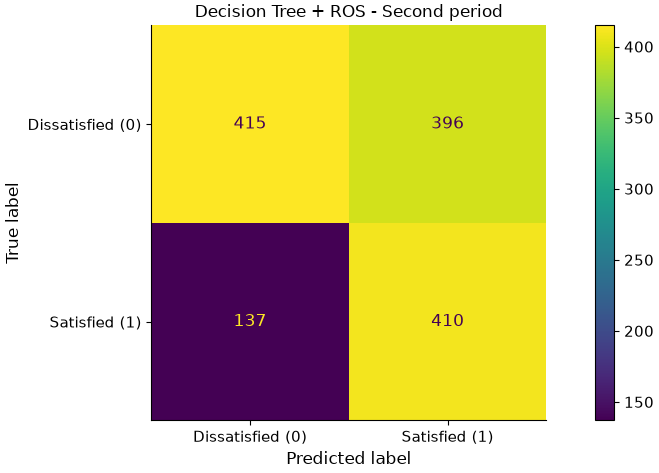


--------------------------------------------------------------------------------
Training model: Random Forest + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best model: Random Forest + ROS
Best params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__n_estimators': 200}
Best CV f1_macro: 0.6882

Experiment: RandomOverSampler
Period: Second period
Model: Random Forest + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7392    0.7583    0.7486       811
   Satisfied (1)     0.6274    0.6033    0.6151       547

        accuracy                         0.6959      1358
       macro avg     0.6833    0.6808    0.6819      1358
    weighted avg     0.6941    0.6959    0.6948      1358


Confusion matrix:
[[615 196]
 [217 330]]
TN: 615, FP: 196, FN: 217, TP: 330


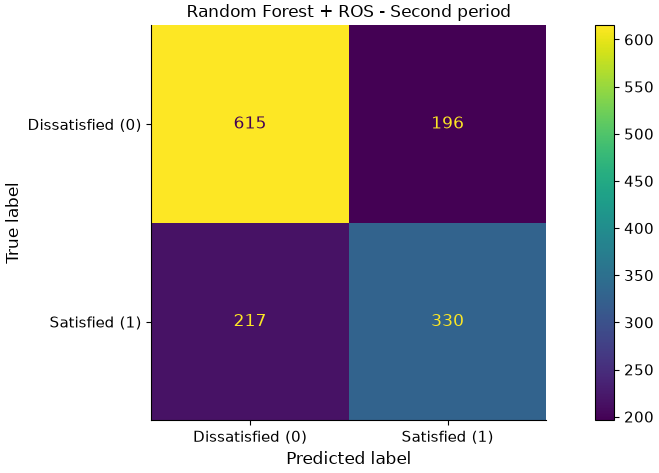


####################################################################################################
Running RandomOverSampler models for period: 3_Period
####################################################################################################

Periodo: 3_Period
Shape X: (5593, 21)
Shape y: (5593,)
Distribución del target:
ETIQUETA
0    3672
1    1921
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    65.653495
1    34.346505
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + ROS
Best params:
{'classifier__C': 0.01, 'classifier__l1_ratio': 1.0}
Best CV f1_macro: 0.7018

Experiment: RandomOverSampler
Period: Third period
Model: Logistic Regression + ROS

Classification report:
     

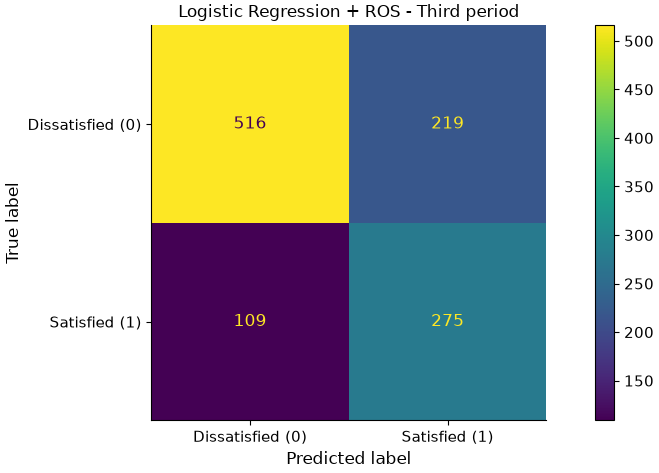


--------------------------------------------------------------------------------
Training model: Decision Tree + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + ROS
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6985

Experiment: RandomOverSampler
Period: Third period
Model: Decision Tree + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7811    0.8109    0.7957       735
   Satisfied (1)     0.6096    0.5651    0.5865       384

        accuracy                         0.7265      1119
       macro avg     0.6953    0.6880    0.6911      1119
    weighted avg     0.7222    0.7265    0.7239      1119


Confusion matrix:
[[596 139]
 [167 217]]
TN: 

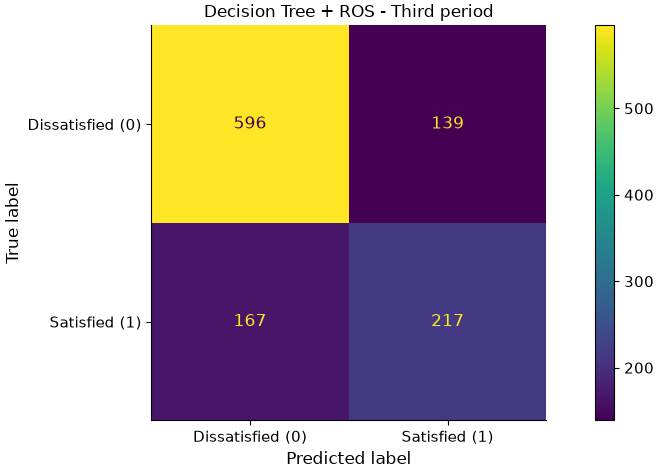


--------------------------------------------------------------------------------
Training model: Random Forest + ROS
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best model: Random Forest + ROS
Best params:
{'classifier__max_depth': 10, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best CV f1_macro: 0.7065

Experiment: RandomOverSampler
Period: Third period
Model: Random Forest + ROS

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.8166    0.7633    0.7890       735
   Satisfied (1)     0.5972    0.6719    0.6324       384

        accuracy                         0.7319      1119
       macro avg     0.7069    0.7176    0.7107      1119
    weighted avg     0.7413    0.7319    0.7353      1119


Confusion matrix:
[[561 174]
 [126 258]]
TN: 561, FP: 174, FN: 126, TP: 258


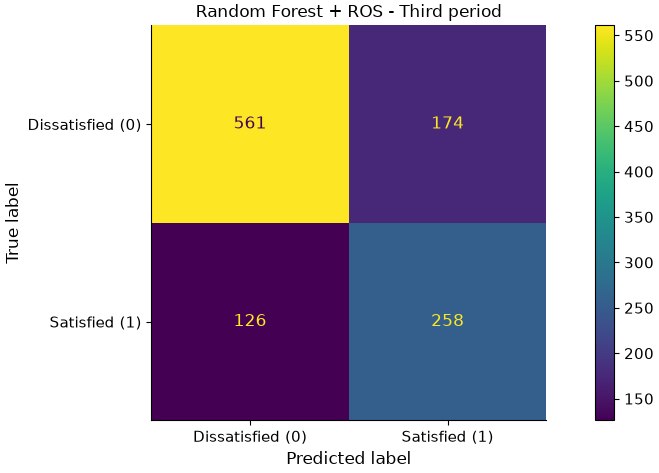

In [280]:
# =============================================================================
# RUN RANDOMOVERSAMPLER MODELS BY HISTORICAL PERIOD
# =============================================================================

ros_results = []
ros_best_models = {}

for period in periods:
    print("\n" + "#" * 100)
    print(f"Running RandomOverSampler models for period: {period}")
    print("#" * 100)

    # Extract period-specific predictors and target.
    X_period, y_period = get_period_data(
        df=df_ecuador,
        period=period,
        feature_columns=feature_columns,
        target=TARGET
    )

    # Keep the same train/test split strategy used in the previous experiment.
    # The test set remains untouched and is not oversampled.
    X_train, X_test, y_train, y_test = split_period_data(
        X=X_period,
        y=y_period,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    for model_name, config in model_configs_ros.items():
        print("\n" + "-" * 80)
        print(f"Training model: {model_name}")
        print("-" * 80)

        fitted_model = train_model_with_random_oversampling(
            model_name=model_name,
            config=config,
            X_train=X_train,
            y_train=y_train,
            random_state=RANDOM_STATE
        )

        metrics = evaluate_model(
            model_name=model_name,
            period=period,
            fitted_model=fitted_model,
            X_test=X_test,
            y_test=y_test,
            period_display_labels=PERIOD_DISPLAY_LABELS,
            experiment="RandomOverSampler",
            save_confusion_matrix=True
        )

        ros_results.append(metrics)
        ros_best_models[(period, model_name)] = fitted_model

## RandomOverSampler Results Summary Table

This section summarizes the performance metrics of all RandomOverSampler models across historical periods.

In [281]:
# =============================================================================
# RANDOMOVERSAMPLER RESULTS SUMMARY TABLE
# =============================================================================

ros_results_df = pd.DataFrame(ros_results)

ros_results_df = ros_results_df.sort_values(
    by=["period", REFIT_METRIC],
    ascending=[True, False]
)

display(ros_results_df)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
2,RandomOverSampler,1_Period,First period,Random Forest + ROS,0.687783,0.580718,0.412698,0.345515,0.376130,0.583961,0.769050,0.815920,0.791792,804.0,0.412698,0.345515,0.376130,301.0,656,148,197,104,0.675976,"{'classifier__max_depth': None, 'classifier__m...",0.598905
1,RandomOverSampler,1_Period,First period,Decision Tree + ROS,0.641629,0.574982,0.365439,0.428571,0.394495,0.569998,0.771277,0.721393,0.745501,804.0,0.365439,0.428571,0.394495,301.0,580,224,172,129,0.589515,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.557647
0,RandomOverSampler,1_Period,First period,Logistic Regression + ROS,0.604525,0.591054,0.356540,0.561462,0.436129,0.565800,0.790808,0.620647,0.695470,804.0,0.356540,0.561462,0.436129,301.0,499,305,132,169,0.626089,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.563441
5,RandomOverSampler,2_Period,Second period,Random Forest + ROS,0.695876,0.680807,0.627376,0.603291,0.615098,0.681864,0.739183,0.758323,0.748631,811.0,0.627376,0.603291,0.615098,547.0,615,196,217,330,0.748017,"{'classifier__max_depth': None, 'classifier__m...",0.688237
3,RandomOverSampler,2_Period,Second period,Logistic Regression + ROS,0.681149,0.682461,0.589063,0.689214,0.635215,0.676012,0.763231,0.675709,0.716808,811.0,0.589063,0.689214,0.635215,547.0,548,263,170,377,0.743986,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.674058
4,RandomOverSampler,2_Period,Second period,Decision Tree + ROS,0.607511,0.630628,0.508685,0.749543,0.606061,0.607506,0.751812,0.511714,0.608951,811.0,0.508685,0.749543,0.606061,547.0,415,396,137,410,0.687814,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.662851
8,RandomOverSampler,3_Period,Third period,Random Forest + ROS,0.731903,0.717570,0.597222,0.671875,0.632353,0.710691,0.816594,0.763265,0.789030,735.0,0.597222,0.671875,0.632353,384.0,561,174,126,258,0.781689,"{'classifier__max_depth': 10, 'classifier__max...",0.706486
6,RandomOverSampler,3_Period,Third period,Logistic Regression + ROS,0.706881,0.709093,0.556680,0.716146,0.626424,0.692624,0.825600,0.702041,0.758824,735.0,0.556680,0.716146,0.626424,384.0,516,219,109,275,0.782572,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.701821
7,RandomOverSampler,3_Period,Third period,Decision Tree + ROS,0.726542,0.687994,0.609551,0.565104,0.586486,0.691107,0.781127,0.810884,0.795728,735.0,0.609551,0.565104,0.586486,384.0,596,139,167,217,0.752480,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.698452


## Best RandomOverSampler Model by Historical Period

This section identifies the best-performing RandomOverSampler model for each historical period according to the main selection metric.

In [282]:
# =============================================================================
# BEST RANDOMOVERSAMPLER MODEL BY HISTORICAL PERIOD
# =============================================================================

best_ros_by_period = (
    ros_results_df
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
)

display(best_ros_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
2,RandomOverSampler,1_Period,First period,Random Forest + ROS,0.687783,0.580718,0.412698,0.345515,0.376130,0.583961,0.769050,0.815920,0.791792,804.0,0.412698,0.345515,0.376130,301.0,656,148,197,104,0.675976,"{'classifier__max_depth': None, 'classifier__m...",0.598905
5,RandomOverSampler,2_Period,Second period,Random Forest + ROS,0.695876,0.680807,0.627376,0.603291,0.615098,0.681864,0.739183,0.758323,0.748631,811.0,0.627376,0.603291,0.615098,547.0,615,196,217,330,0.748017,"{'classifier__max_depth': None, 'classifier__m...",0.688237
8,RandomOverSampler,3_Period,Third period,Random Forest + ROS,0.731903,0.717570,0.597222,0.671875,0.632353,0.710691,0.816594,0.763265,0.789030,735.0,0.597222,0.671875,0.632353,384.0,561,174,126,258,0.781689,"{'classifier__max_depth': 10, 'classifier__max...",0.706486


---

# PART 7 — Experiment 3: SMOTENC

This section evaluates whether `SMOTENC` improves classification performance under class imbalance.

Unlike standard SMOTE, `SMOTENC` is designed for datasets that contain both numeric and categorical variables. This is important because most survey variables in this dataset are categorical or ordinal-coded.

For this experiment, age is treated as the only continuous numeric variable. Binary, ordinal, and nominal variables are treated as categorical features during the oversampling process.

The oversampling step is applied only inside the training folds during cross-validation. The test set remains untouched and is used only for final evaluation.

---

## SMOTENC Feature Groups

This section defines which variables are treated as numeric and which are treated as categorical for the SMOTENC experiment.

In [283]:
# =============================================================================
# FEATURE GROUPS FOR SMOTENC
# =============================================================================

# For SMOTENC, only age is treated as a continuous numeric variable.
# Most survey variables are categorical or ordinal-coded, so they are treated
# as categorical during oversampling to avoid unrealistic fractional values.
smotenc_numeric_features = numeric_features

smotenc_categorical_features = (
    ordinal_features
    + binary_features
    + nominal_features
)

# The order is important because SMOTENC requires the positions of categorical
# variables after preprocessing.
feature_columns_smotenc = (
    smotenc_numeric_features
    + smotenc_categorical_features
)

print("Numeric features for SMOTENC:")
print(smotenc_numeric_features)

print("\nCategorical features for SMOTENC:")
print(smotenc_categorical_features)

print("\nTotal features used in SMOTENC experiment:")
print(len(feature_columns_smotenc))

Numeric features for SMOTENC:
['S_17']

Categorical features for SMOTENC:
['A_2', 'D_5', 'H_10', 'H_11', 'H_12', 'H_13', 'H_14', 'H_15', 'S_19', 'S_21', 'C_4', 'D_6', 'D_7', 'D_8', 'D_9', 'S_16', 'S_18', 'A_1', 'S_20', 'S_22']

Total features used in SMOTENC experiment:
21


## Pre-SMOTENC Imputation

This section imputes missing values before applying SMOTENC, since oversampling methods cannot handle missing values directly.

In [284]:
# =============================================================================
# PRE-SMOTENC IMPUTATION
# =============================================================================

# Numeric variables are imputed with the median.
numeric_imputer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

# Categorical variables are imputed with the most frequent value.
categorical_imputer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ]
)

# This preprocessor only imputes missing values.
# It does not scale or one-hot encode variables before SMOTENC.
pre_smotenc_imputer = ColumnTransformer(
    transformers=[
        ("numeric", numeric_imputer, smotenc_numeric_features),
        ("categorical", categorical_imputer, smotenc_categorical_features)
    ],
    remainder="drop"
)

# After pre_smotenc_imputer, the output order is:
# numeric variables first, categorical variables second.
categorical_feature_indices_smotenc = list(
    range(
        len(smotenc_numeric_features),
        len(feature_columns_smotenc)
    )
)

print("Categorical feature indices for SMOTENC:")
print(categorical_feature_indices_smotenc)

Categorical feature indices for SMOTENC:
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]


## Post-SMOTENC Preprocessing

This section defines the preprocessing steps applied after SMOTENC, including scaling for linear models and one-hot encoding for categorical variables.

In [285]:
# =============================================================================
# POST-SMOTENC PREPROCESSING
# =============================================================================

# Position of numeric variables after pre_smotenc_imputer.
smotenc_numeric_indices = list(
    range(len(smotenc_numeric_features))
)

# Position of categorical variables after pre_smotenc_imputer.
smotenc_categorical_indices = categorical_feature_indices_smotenc


def build_post_smotenc_preprocessor(scale_numeric=True):
    """
    Build the preprocessing step applied after SMOTENC.

    At this stage, missing values have already been imputed and the minority
    class has already been oversampled. Therefore, this step focuses on
    scaling numeric variables when needed and one-hot encoding categorical
    variables.
    """

    if scale_numeric:
        numeric_transformer = Pipeline(
            steps=[
                ("scaler", StandardScaler())
            ]
        )
    else:
        numeric_transformer = "passthrough"

    categorical_transformer = Pipeline(
        steps=[
            (
                "onehot",
                OneHotEncoder(
                    handle_unknown="ignore",
                    drop=None
                )
            )
        ]
    )

    postprocessor = ColumnTransformer(
        transformers=[
            ("numeric", numeric_transformer, smotenc_numeric_indices),
            ("categorical", categorical_transformer, smotenc_categorical_indices)
        ],
        remainder="drop"
    )

    return postprocessor


# Logistic Regression benefits from scaling.
post_smotenc_preprocessor_linear = build_post_smotenc_preprocessor(
    scale_numeric=True
)

# Tree-based models do not require scaling.
post_smotenc_preprocessor_tree = build_post_smotenc_preprocessor(
    scale_numeric=False
)

## SMOTENC Model Configuration

This section defines the models and hyperparameter grids used in the SMOTENC experiment.

In [286]:
# =============================================================================
# MODEL CONFIGURATION WITH SMOTENC
# =============================================================================

# In this experiment, class_weight is set to None because class imbalance is
# handled through SMOTENC oversampling.
model_configs_smotenc = {
    "Logistic Regression + SMOTENC": {
        "postprocessor": post_smotenc_preprocessor_linear,
        "model": LogisticRegression(
            max_iter=10000,
            solver="saga",
            random_state=RANDOM_STATE,
            class_weight=None
        ),
        "params": {
            "classifier__C": [0.01, 0.1, 1, 10],
            "classifier__l1_ratio": [0.0, 0.5, 1.0]
        }
    },

    "Decision Tree + SMOTENC": {
        "postprocessor": post_smotenc_preprocessor_tree,
        "model": DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight=None
        ),
        "params": {
            "classifier__criterion": ["gini", "entropy", "log_loss"],
            "classifier__max_depth": [3, 5, 10, 15, None],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 5, 10],
            "classifier__ccp_alpha": [0.0, 0.001, 0.01]
        }
    },

    "Random Forest + SMOTENC": {
        "postprocessor": post_smotenc_preprocessor_tree,
        "model": RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight=None
        ),
        "params": {
            "classifier__n_estimators": [200, 500],
            "classifier__max_depth": [5, 10, None],
            "classifier__min_samples_leaf": [1, 5, 10],
            "classifier__max_features": ["sqrt", "log2"]
        }
    }
}

## SMOTENC Training Function

This section defines the training function that combines imputation, SMOTENC, postprocessing, cross-validation, and GridSearchCV.

In [287]:
def train_model_with_smotenc(
    model_name,
    config,
    X_train,
    y_train,
    random_state=42
):
    """
    Train a classification model using imputation, SMOTENC, postprocessing,
    and GridSearchCV.

    SMOTENC is applied only inside the cross-validation training folds.
    This avoids data leakage because validation folds and the final test set
    are not oversampled.
    """

    # SMOTENC needs enough minority-class samples to create neighbors.
    min_class_count = y_train.value_counts().min()

    # The number of CV folds cannot exceed the minority-class size.
    n_splits = min(5, min_class_count)

    if n_splits < 2:
        raise ValueError(
            "There are not enough observations in the minority class "
            "to perform cross-validation."
        )

    # SMOTENC uses nearest neighbors.
    # k_neighbors must be smaller than the number of minority-class samples
    # available inside the training fold.
    k_neighbors = min(5, min_class_count - 1)

    if k_neighbors < 1:
        raise ValueError(
            "There are not enough minority-class observations "
            "to apply SMOTENC."
        )

    cv = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    # The pipeline order is:
    # 1. Impute missing values
    # 2. Apply SMOTENC to the training fold
    # 3. Encode/scale variables
    # 4. Train classifier
    pipeline = ImbPipeline(
        steps=[
            ("pre_smotenc_imputer", pre_smotenc_imputer),

            (
                "smotenc",
                SMOTENC(
                    categorical_features=categorical_feature_indices_smotenc,
                    k_neighbors=k_neighbors,
                    random_state=random_state
                )
            ),

            ("postprocessor", config["postprocessor"]),
            ("classifier", config["model"])
        ]
    )

    grid_search = GridSearchCV(
        estimator=pipeline,
        param_grid=config["params"],
        scoring=SCORING,
        refit=REFIT_METRIC,
        cv=cv,
        n_jobs=-1,
        verbose=1,
        return_train_score=True
    )

    grid_search.fit(X_train, y_train)

    print(f"\nBest model: {model_name}")
    print("Best params:")
    print(grid_search.best_params_)
    print(f"Best CV {REFIT_METRIC}: {grid_search.best_score_:.4f}")

    return grid_search

## Run SMOTENC Models by Historical Period

This section trains and evaluates SMOTENC models independently for each historical period.


####################################################################################################
Running SMOTENC models for period: 1_Period
####################################################################################################

Periodo: 1_Period
Shape X: (5522, 21)
Shape y: (5522,)
Distribución del target:
ETIQUETA
0    4017
1    1505
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    72.745382
1    27.254618
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + SMOTENC
Best params:
{'classifier__C': 0.01, 'classifier__l1_ratio': 0.0}
Best CV f1_macro: 0.5483

Experiment: SMOTENC
Period: First period
Model: Logistic Regression + SMOTENC

Classification report:
             

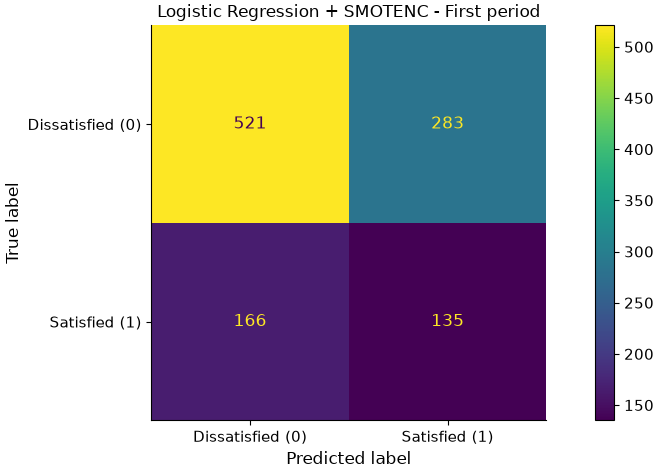


--------------------------------------------------------------------------------
Training model: Decision Tree + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + SMOTENC
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'entropy', 'classifier__max_depth': 15, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.5650

Experiment: SMOTENC
Period: First period
Model: Decision Tree + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7645    0.6866    0.7235       804
   Satisfied (1)     0.3420    0.4352    0.3830       301

        accuracy                         0.6181      1105
       macro avg     0.5533    0.5609    0.5533      1105
    weighted avg     0.6495    0.6181    0.6307      1105


Confusion matrix:
[[552 252]
 [170 131]]
T

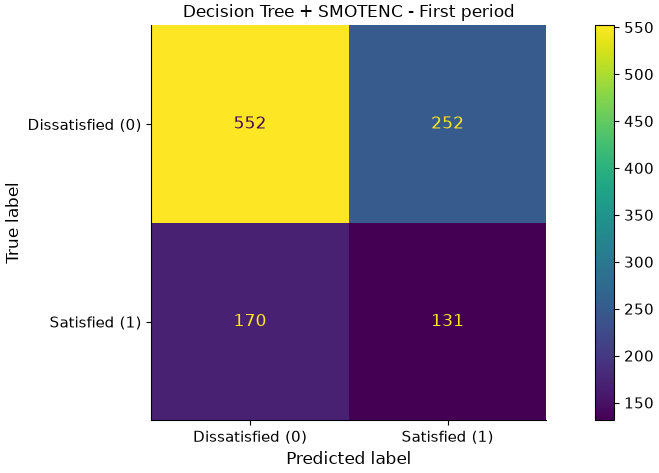


--------------------------------------------------------------------------------
Training model: Random Forest + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best model: Random Forest + SMOTENC
Best params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
Best CV f1_macro: 0.5852

Experiment: SMOTENC
Period: First period
Model: Random Forest + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7663    0.8644    0.8124       804
   Satisfied (1)     0.4495    0.2957    0.3567       301

        accuracy                         0.7095      1105
       macro avg     0.6079    0.5801    0.5846      1105
    weighted avg     0.6800    0.7095    0.6883      1105


Confusion matrix:
[[695 109]
 [212  89]]
TN: 695, FP: 109, FN: 212, TP: 89


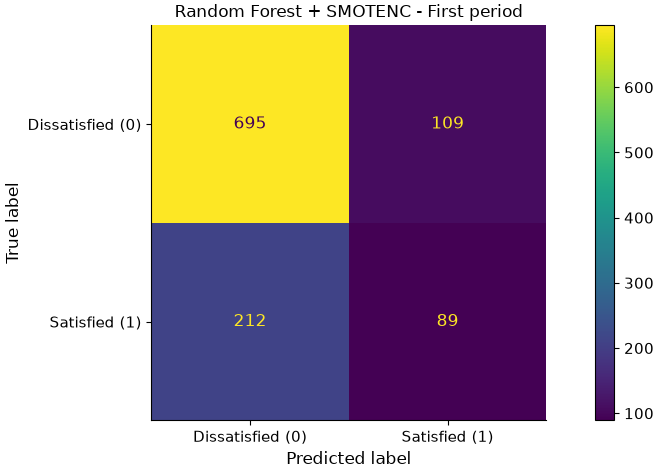


####################################################################################################
Running SMOTENC models for period: 2_Period
####################################################################################################

Periodo: 2_Period
Shape X: (6787, 21)
Shape y: (6787,)
Distribución del target:
ETIQUETA
0    4051
1    2736
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    59.687638
1    40.312362
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + SMOTENC
Best params:
{'classifier__C': 0.1, 'classifier__l1_ratio': 1.0}
Best CV f1_macro: 0.6743

Experiment: SMOTENC
Period: Second period
Model: Logistic Regression + SMOTENC

Classification report:
             

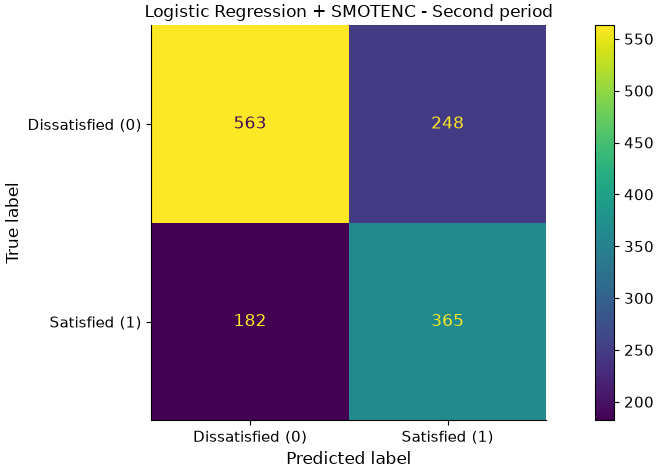


--------------------------------------------------------------------------------
Training model: Decision Tree + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + SMOTENC
Best params:
{'classifier__ccp_alpha': 0.0, 'classifier__criterion': 'gini', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6408

Experiment: SMOTENC
Period: Second period
Model: Decision Tree + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7469    0.5894    0.6589       811
   Satisfied (1)     0.5362    0.7038    0.6087       547

        accuracy                         0.6355      1358
       macro avg     0.6415    0.6466    0.6338      1358
    weighted avg     0.6620    0.6355    0.6387      1358


Confusion matrix:
[[478 333]
 [162 385]]
TN: 

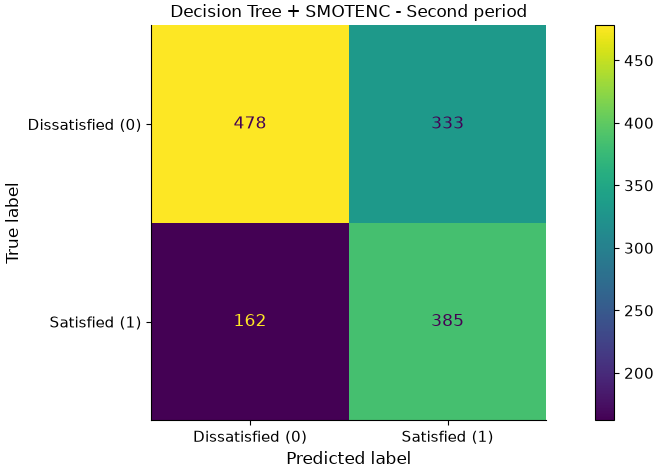


--------------------------------------------------------------------------------
Training model: Random Forest + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/home/ecuenca/satisfaction_democracy/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ecuenca/satisfaction_democracy/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ecuenca/satisfaction_democracy/.venv/lib/python3.12/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/ecuenca


Best model: Random Forest + SMOTENC
Best params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 500}
Best CV f1_macro: 0.6845

Experiment: SMOTENC
Period: Second period
Model: Random Forest + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.7282    0.7534    0.7406       811
   Satisfied (1)     0.6146    0.5832    0.5985       547

        accuracy                         0.6848      1358
       macro avg     0.6714    0.6683    0.6696      1358
    weighted avg     0.6825    0.6848    0.6834      1358


Confusion matrix:
[[611 200]
 [228 319]]
TN: 611, FP: 200, FN: 228, TP: 319


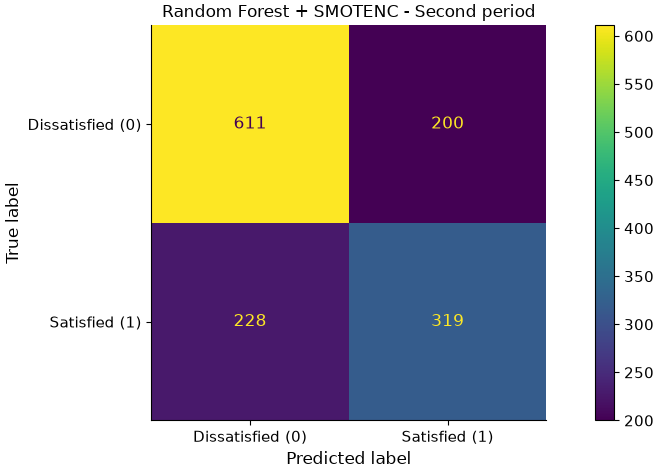


####################################################################################################
Running SMOTENC models for period: 3_Period
####################################################################################################

Periodo: 3_Period
Shape X: (5593, 21)
Shape y: (5593,)
Distribución del target:
ETIQUETA
0    3672
1    1921
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    65.653495
1    34.346505
Name: proportion, dtype: float64

--------------------------------------------------------------------------------
Training model: Logistic Regression + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best model: Logistic Regression + SMOTENC
Best params:
{'classifier__C': 0.01, 'classifier__l1_ratio': 0.5}
Best CV f1_macro: 0.7031

Experiment: SMOTENC
Period: Third period
Model: Logistic Regression + SMOTENC

Classification report:
             

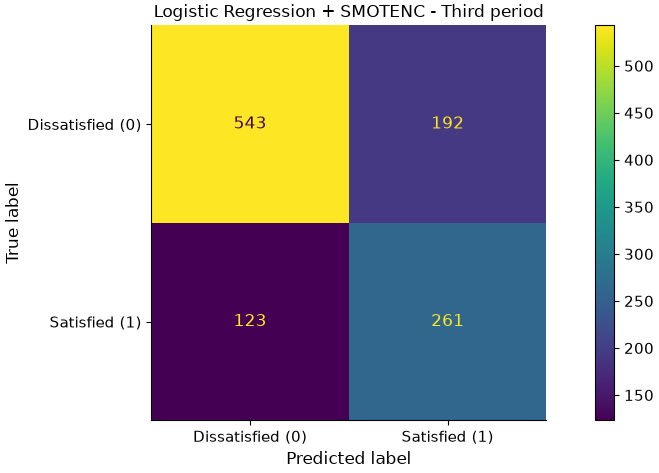


--------------------------------------------------------------------------------
Training model: Decision Tree + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 540 candidates, totalling 2700 fits

Best model: Decision Tree + SMOTENC
Best params:
{'classifier__ccp_alpha': 0.01, 'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Best CV f1_macro: 0.6909

Experiment: SMOTENC
Period: Third period
Model: Decision Tree + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.8267    0.6816    0.7472       735
   Satisfied (1)     0.5439    0.7266    0.6221       384

        accuracy                         0.6971      1119
       macro avg     0.6853    0.7041    0.6846      1119
    weighted avg     0.7297    0.6971    0.7043      1119


Confusion matrix:
[[501 234]
 [105 279]]
T

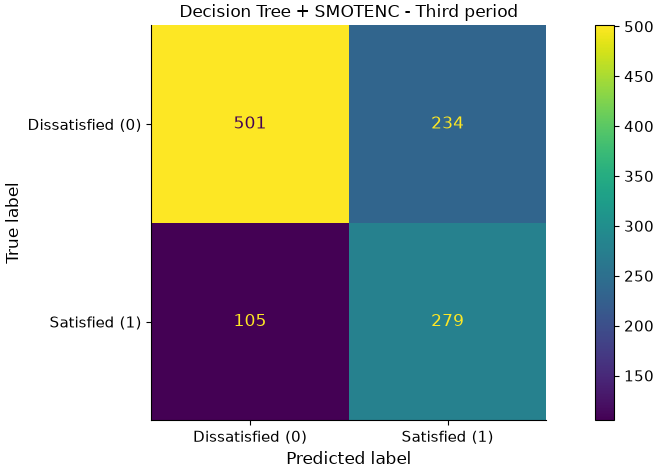


--------------------------------------------------------------------------------
Training model: Random Forest + SMOTENC
--------------------------------------------------------------------------------
Fitting 5 folds for each of 36 candidates, totalling 180 fits


/home/ecuenca/satisfaction_democracy/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best model: Random Forest + SMOTENC
Best params:
{'classifier__max_depth': None, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 500}
Best CV f1_macro: 0.7121

Experiment: SMOTENC
Period: Third period
Model: Random Forest + SMOTENC

Classification report:
                  precision    recall  f1-score   support

Dissatisfied (0)     0.8093    0.7850    0.7970       735
   Satisfied (1)     0.6108    0.6458    0.6278       384

        accuracy                         0.7373      1119
       macro avg     0.7100    0.7154    0.7124      1119
    weighted avg     0.7412    0.7373    0.7389      1119


Confusion matrix:
[[577 158]
 [136 248]]
TN: 577, FP: 158, FN: 136, TP: 248


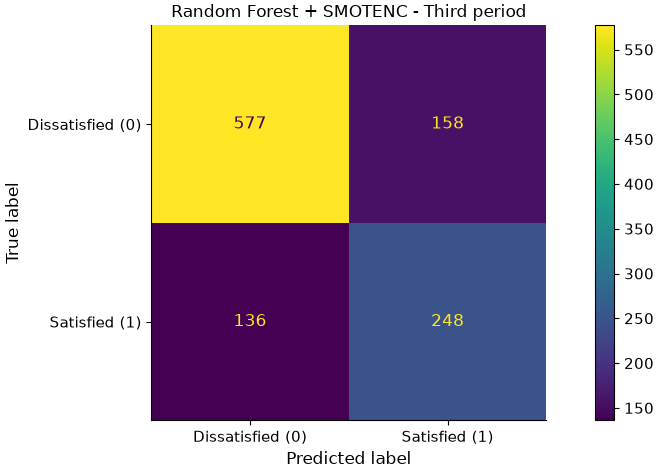

In [288]:
# =============================================================================
# RUN SMOTENC MODELS BY HISTORICAL PERIOD
# =============================================================================

smotenc_results = []
smotenc_best_models = {}

for period in periods:
    print("\n" + "#" * 100)
    print(f"Running SMOTENC models for period: {period}")
    print("#" * 100)

    # Extract period-specific data.
    X_period, y_period = get_period_data(
        df=df_ecuador,
        period=period,
        feature_columns=feature_columns_smotenc,
        target=TARGET
    )

    # The test set remains untouched.
    X_train, X_test, y_train, y_test = split_period_data(
        X=X_period,
        y=y_period,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    for model_name, config in model_configs_smotenc.items():
        print("\n" + "-" * 80)
        print(f"Training model: {model_name}")
        print("-" * 80)

        fitted_model = train_model_with_smotenc(
            model_name=model_name,
            config=config,
            X_train=X_train,
            y_train=y_train,
            random_state=RANDOM_STATE
        )

        metrics = evaluate_model(
            model_name=model_name,
            period=period,
            fitted_model=fitted_model,
            X_test=X_test,
            y_test=y_test,
            period_display_labels=PERIOD_DISPLAY_LABELS,
            experiment="SMOTENC",
            save_confusion_matrix=True
        )

        smotenc_results.append(metrics)
        smotenc_best_models[(period, model_name)] = fitted_model

## SMOTENC Results Summary Table

This section summarizes the performance metrics of all SMOTENC models across historical periods.

In [289]:
# =============================================================================
# SMOTENC RESULTS SUMMARY TABLE
# =============================================================================

smotenc_results_df = pd.DataFrame(smotenc_results)

smotenc_results_df = smotenc_results_df.sort_values(
    by=["period", REFIT_METRIC],
    ascending=[True, False]
)

display(smotenc_results_df)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
2,SMOTENC,1_Period,First period,Random Forest + SMOTENC,0.709502,0.580054,0.449495,0.295681,0.356713,0.584552,0.766262,0.864428,0.812390,804.0,0.449495,0.295681,0.356713,301.0,695,109,212,89,0.659351,"{'classifier__max_depth': None, 'classifier__m...",0.585225
1,SMOTENC,1_Period,First period,Decision Tree + SMOTENC,0.618100,0.560892,0.342037,0.435216,0.383041,0.553250,0.764543,0.686567,0.723460,804.0,0.342037,0.435216,0.383041,301.0,552,252,170,131,0.575356,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.565000
0,SMOTENC,1_Period,First period,Logistic Regression + SMOTENC,0.593665,0.548257,0.322967,0.448505,0.375522,0.537191,0.758370,0.648010,0.698860,804.0,0.322967,0.448505,0.375522,301.0,521,283,166,135,0.573904,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.548347
3,SMOTENC,2_Period,Second period,Logistic Regression + SMOTENC,0.683358,0.680740,0.595432,0.667276,0.629310,0.676480,0.755705,0.694205,0.723650,811.0,0.595432,0.667276,0.629310,547.0,563,248,182,365,0.743569,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.674298
5,SMOTENC,2_Period,Second period,Random Forest + SMOTENC,0.684831,0.668286,0.614644,0.583181,0.598499,0.669553,0.728248,0.753391,0.740606,811.0,0.614644,0.583181,0.598499,547.0,611,200,228,319,0.738887,"{'classifier__max_depth': None, 'classifier__m...",0.684460
4,SMOTENC,2_Period,Second period,Decision Tree + SMOTENC,0.635493,0.646617,0.536212,0.703839,0.608696,0.633776,0.746875,0.589396,0.658856,811.0,0.536212,0.703839,0.608696,547.0,478,333,162,385,0.709577,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.640820
8,SMOTENC,3_Period,Third period,Random Forest + SMOTENC,0.737265,0.715434,0.610837,0.645833,0.627848,0.712405,0.809257,0.785034,0.796961,735.0,0.610837,0.645833,0.627848,384.0,577,158,136,248,0.778490,"{'classifier__max_depth': None, 'classifier__m...",0.712085
6,SMOTENC,3_Period,Third period,Logistic Regression + SMOTENC,0.718499,0.709232,0.576159,0.679688,0.623656,0.699408,0.815315,0.738776,0.775161,735.0,0.576159,0.679688,0.623656,384.0,543,192,123,261,0.769951,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.703054
7,SMOTENC,3_Period,Third period,Decision Tree + SMOTENC,0.697051,0.704098,0.543860,0.726562,0.622074,0.684639,0.826733,0.681633,0.747204,735.0,0.543860,0.726562,0.622074,384.0,501,234,105,279,0.743341,"{'classifier__ccp_alpha': 0.01, 'classifier__c...",0.690922


## Best SMOTENC Model by Historical Period

This section identifies the best-performing SMOTENC model for each historical period according to the main selection metric.

In [290]:
# =============================================================================
# BEST SMOTENC MODEL BY HISTORICAL PERIOD
# =============================================================================

best_smotenc_by_period = (
    smotenc_results_df
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
)

display(best_smotenc_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
2,SMOTENC,1_Period,First period,Random Forest + SMOTENC,0.709502,0.580054,0.449495,0.295681,0.356713,0.584552,0.766262,0.864428,0.812390,804.0,0.449495,0.295681,0.356713,301.0,695,109,212,89,0.659351,"{'classifier__max_depth': None, 'classifier__m...",0.585225
3,SMOTENC,2_Period,Second period,Logistic Regression + SMOTENC,0.683358,0.680740,0.595432,0.667276,0.629310,0.676480,0.755705,0.694205,0.723650,811.0,0.595432,0.667276,0.629310,547.0,563,248,182,365,0.743569,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.674298
8,SMOTENC,3_Period,Third period,Random Forest + SMOTENC,0.737265,0.715434,0.610837,0.645833,0.627848,0.712405,0.809257,0.785034,0.796961,735.0,0.610837,0.645833,0.627848,384.0,577,158,136,248,0.778490,"{'classifier__max_depth': None, 'classifier__m...",0.712085


---

# PART 8 — Comparison of All Experiments

This part compares the three modeling strategies and selects the final best-performing model for each historical period.

---

## Full Model Comparison Across Experiments

This section combines the results from the class-weight grid, RandomOverSampler, and SMOTENC experiments into a single comparison table.

In [291]:
# =============================================================================
# COMPARISON OF ALL EXPERIMENTS
# =============================================================================

baseline_comparison = results_df.copy()
baseline_comparison["experiment"] = "Class weight grid"

ros_comparison = ros_results_df.copy()
ros_comparison["experiment"] = "RandomOverSampler"

smotenc_comparison = smotenc_results_df.copy()
smotenc_comparison["experiment"] = "SMOTENC"

all_experiments_df = pd.concat(
    [
        baseline_comparison,
        ros_comparison,
        smotenc_comparison
    ],
    ignore_index=True
)

all_experiments_df = all_experiments_df.sort_values(
    by=["period", REFIT_METRIC],
    ascending=[True, False]
)

display(all_experiments_df)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
0,Class weight grid,1_Period,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153
1,Class weight grid,1_Period,First period,Random Forest,0.666063,0.598009,0.399408,0.448505,0.422535,0.593826,0.783572,0.747512,0.765118,804.0,0.399408,0.448505,0.422535,301.0,601,203,166,135,0.670105,"{'classifier__class_weight': 'balanced', 'clas...",0.605075
18,SMOTENC,1_Period,First period,Random Forest + SMOTENC,0.709502,0.580054,0.449495,0.295681,0.356713,0.584552,0.766262,0.864428,0.812390,804.0,0.449495,0.295681,0.356713,301.0,695,109,212,89,0.659351,"{'classifier__max_depth': None, 'classifier__m...",0.585225
9,RandomOverSampler,1_Period,First period,Random Forest + ROS,0.687783,0.580718,0.412698,0.345515,0.376130,0.583961,0.769050,0.815920,0.791792,804.0,0.412698,0.345515,0.376130,301.0,656,148,197,104,0.675976,"{'classifier__max_depth': None, 'classifier__m...",0.598905
10,RandomOverSampler,1_Period,First period,Decision Tree + ROS,0.641629,0.574982,0.365439,0.428571,0.394495,0.569998,0.771277,0.721393,0.745501,804.0,0.365439,0.428571,0.394495,301.0,580,224,172,129,0.589515,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.557647
2,Class weight grid,1_Period,First period,Logistic Regression,0.606335,0.591259,0.357447,0.558140,0.435798,0.566752,0.790551,0.624378,0.697707,804.0,0.357447,0.558140,0.435798,301.0,502,302,133,168,0.630758,"{'classifier__C': 0.01, 'classifier__class_wei...",0.563333
11,RandomOverSampler,1_Period,First period,Logistic Regression + ROS,0.604525,0.591054,0.356540,0.561462,0.436129,0.565800,0.790808,0.620647,0.695470,804.0,0.356540,0.561462,0.436129,301.0,499,305,132,169,0.626089,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.563441
19,SMOTENC,1_Period,First period,Decision Tree + SMOTENC,0.618100,0.560892,0.342037,0.435216,0.383041,0.553250,0.764543,0.686567,0.723460,804.0,0.342037,0.435216,0.383041,301.0,552,252,170,131,0.575356,"{'classifier__ccp_alpha': 0.0, 'classifier__cr...",0.565000
20,SMOTENC,1_Period,First period,Logistic Regression + SMOTENC,0.593665,0.548257,0.322967,0.448505,0.375522,0.537191,0.758370,0.648010,0.698860,804.0,0.322967,0.448505,0.375522,301.0,521,283,166,135,0.573904,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.548347
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978


## Final Selected Models by Historical Period

This section selects the best final model for each historical period across all experiments using the main selection metric.

In [292]:
# =============================================================================
# BEST FINAL MODEL BY HISTORICAL PERIOD
# =============================================================================

best_final_by_period = (
    all_experiments_df
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
)

display(best_final_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
0,Class weight grid,1_Period,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978
6,Class weight grid,3_Period,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552


## Best Model Performance by Experiment and Historical Period

This section compares the best model within each experiment and historical period to evaluate how each imbalance-handling strategy performs.

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score,experiment_model
0,Class weight grid,1_Period,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153,Class weight grid | Decision Tree
9,RandomOverSampler,1_Period,First period,Random Forest + ROS,0.687783,0.580718,0.412698,0.345515,0.376130,0.583961,0.769050,0.815920,0.791792,804.0,0.412698,0.345515,0.376130,301.0,656,148,197,104,0.675976,"{'classifier__max_depth': None, 'classifier__m...",0.598905,RandomOverSampler | Random Forest + ROS
18,SMOTENC,1_Period,First period,Random Forest + SMOTENC,0.709502,0.580054,0.449495,0.295681,0.356713,0.584552,0.766262,0.864428,0.812390,804.0,0.449495,0.295681,0.356713,301.0,695,109,212,89,0.659351,"{'classifier__max_depth': None, 'classifier__m...",0.585225,SMOTENC | Random Forest + SMOTENC
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978,Class weight grid | Logistic Regression
12,RandomOverSampler,2_Period,Second period,Random Forest + ROS,0.695876,0.680807,0.627376,0.603291,0.615098,0.681864,0.739183,0.758323,0.748631,811.0,0.627376,0.603291,0.615098,547.0,615,196,217,330,0.748017,"{'classifier__max_depth': None, 'classifier__m...",0.688237,RandomOverSampler | Random Forest + ROS
21,SMOTENC,2_Period,Second period,Logistic Regression + SMOTENC,0.683358,0.680740,0.595432,0.667276,0.629310,0.676480,0.755705,0.694205,0.723650,811.0,0.595432,0.667276,0.629310,547.0,563,248,182,365,0.743569,"{'classifier__C': 0.1, 'classifier__l1_ratio':...",0.674298,SMOTENC | Logistic Regression + SMOTENC
6,Class weight grid,3_Period,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552,Class weight grid | Random Forest
15,RandomOverSampler,3_Period,Third period,Random Forest + ROS,0.731903,0.717570,0.597222,0.671875,0.632353,0.710691,0.816594,0.763265,0.789030,735.0,0.597222,0.671875,0.632353,384.0,561,174,126,258,0.781689,"{'classifier__max_depth': 10, 'classifier__max...",0.706486,RandomOverSampler | Random Forest + ROS
24,SMOTENC,3_Period,Third period,Random Forest + SMOTENC,0.737265,0.715434,0.610837,0.645833,0.627848,0.712405,0.809257,0.785034,0.796961,735.0,0.610837,0.645833,0.627848,384.0,577,158,136,248,0.778490,"{'classifier__max_depth': None, 'classifier__m...",0.712085,SMOTENC | Random Forest + SMOTENC


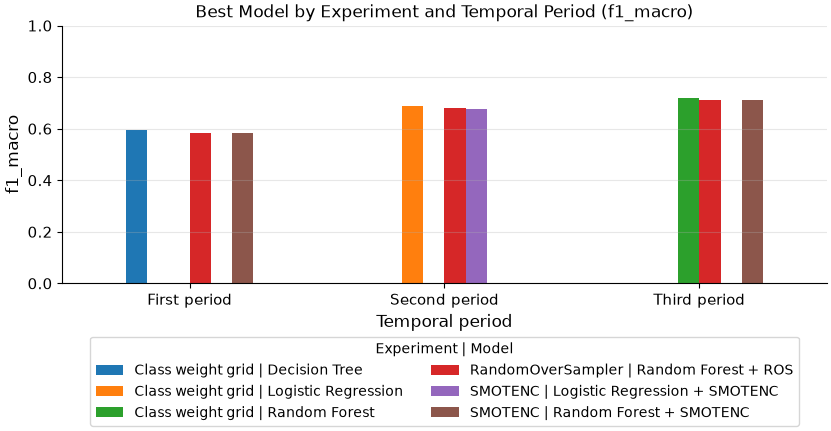

In [336]:
# =============================================================================
# BEST MODEL PERFORMANCE BY EXPERIMENT AND HISTORICAL PERIOD
# =============================================================================

metric = REFIT_METRIC

# Select the best model within each historical period and experiment
best_by_period_experiment = (
    all_experiments_df
    .sort_values(
        by=["period", "experiment", metric],
        ascending=[True, True, False]
    )
    .groupby(["period", "experiment"])
    .head(1)
    .copy()
)

# Add readable period labels
best_by_period_experiment["period_label"] = (
    best_by_period_experiment["period"].map(PERIOD_DISPLAY_LABELS)
)

# Create readable label that includes both experiment and model
best_by_period_experiment["experiment_model"] = (
    best_by_period_experiment["experiment"]
    + " | "
    + best_by_period_experiment["model"]
)

# Keep periods in intended order
best_by_period_experiment["period"] = pd.Categorical(
    best_by_period_experiment["period"],
    categories=period_order,
    ordered=True
)

best_by_period_experiment = (
    best_by_period_experiment
    .sort_values(["period", "experiment"])
    .copy()
)

# Export long-format table
best_by_period_experiment.to_csv(
    MODEL_PERFORMANCE_TABLES_DIR / "best_model_by_experiment_and_period_long.csv",
    index=False
)

display(best_by_period_experiment)

# Pivot table for plotting
plot_data = (
    best_by_period_experiment
    .pivot(
        index="period_label",
        columns="experiment_model",
        values=metric
    )
)

# Reindex using readable period labels in the intended order
period_label_order = [
    PERIOD_DISPLAY_LABELS.get(period, period)
    for period in period_order
]

plot_data = plot_data.reindex(period_label_order)

# Export pivot table
plot_data.to_csv(
    MODEL_PERFORMANCE_TABLES_DIR / "best_model_by_experiment_and_period_pivot.csv"
)

# Plot
fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

plot_data.plot(
    kind="bar",
    ax=ax,
    rot=0
)

ax.set_title(f"Best Model by Experiment and Temporal Period ({metric})")
ax.set_xlabel("Temporal period")
ax.set_ylabel(metric)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Place legend below the plot to avoid excessive horizontal whitespace
ax.legend(
    title="Experiment | Model",
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=2,
    # frameon=False
)

fig.savefig(
    MODEL_PERFORMANCE_FIGURES_DIR / f"best_model_by_experiment_and_period_{metric}.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    MODEL_PERFORMANCE_FIGURES_DIR / f"best_model_by_experiment_and_period_{metric}.pdf",
    bbox_inches="tight"
)

plt.show()

## Best Final Model Performance by Historical Period

This section visualizes the final selected model for each historical period and its performance according to the main selection metric.

,period,experiment,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score,model_experiment
0,1_Period,Class weight grid,First period,Decision Tree,0.679638,0.596945,0.412541,0.415282,0.413907,0.596742,0.780549,0.778607,0.779577,804.0,0.412541,0.415282,0.413907,301.0,626,178,176,125,0.596945,"{'classifier__ccp_alpha': 0.0, 'classifier__cl...",0.561153,Decision Tree | Class weight grid
1,2_Period,Class weight grid,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978,Logistic Regression | Class weight grid
2,3_Period,Class weight grid,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552,Random Forest | Class weight grid


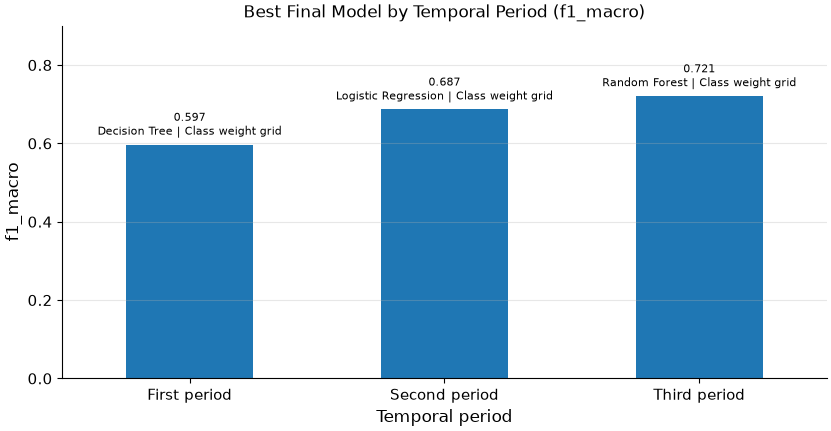

In [294]:
# =============================================================================
# BEST FINAL MODEL PERFORMANCE BY HISTORICAL PERIOD
# =============================================================================

metric = REFIT_METRIC

# Create plotting data
plot_data = best_final_by_period.copy()

# Add readable period labels
plot_data["period_label"] = plot_data["period"].map(PERIOD_DISPLAY_LABELS)

# Create readable selected model label
plot_data["model_experiment"] = (
    plot_data["model"]
    + " | "
    + plot_data["experiment"]
)

# Keep periods in intended order
plot_data = (
    plot_data
    .set_index("period")
    .reindex(period_order)
    .reset_index()
)

plot_data["period_label"] = plot_data["period"].map(PERIOD_DISPLAY_LABELS)

# Export table used for the figure
plot_data.to_csv(
    MODEL_PERFORMANCE_TABLES_DIR / "best_final_model_by_period.csv",
    index=False
)

display(plot_data)

# Plot
fig, ax = plt.subplots(
    figsize=FIGURE_SIZE_WIDE,
    constrained_layout=True
)

plot_data.plot(
    kind="bar",
    x="period_label",
    y=metric,
    ax=ax,
    legend=False,
    rot=0
)

ax.set_title(f"Best Final Model by Temporal Period ({metric})")
ax.set_xlabel("Temporal period")
ax.set_ylabel(metric)
ax.set_ylim(0, min(1.05, plot_data[metric].max() + 0.18))
ax.grid(axis="y", alpha=0.3)

# Add metric value and selected model above each bar
for i, row in plot_data.iterrows():
    ax.text(
        i,
        row[metric] + 0.015,
        f"{row[metric]:.3f}\n{row['model_experiment']}",
        ha="center",
        va="bottom",
        fontsize=8
    )


fig.savefig(
    MODEL_PERFORMANCE_FIGURES_DIR / f"best_final_model_by_period_{metric}.png",
    dpi=FIGURE_DPI,
    bbox_inches="tight"
)

fig.savefig(
    MODEL_PERFORMANCE_FIGURES_DIR / f"best_final_model_by_period_{metric}.pdf",
    bbox_inches="tight"
)

plt.show()

---

# PART 9 — Predictor Importance Analysis

This part interprets the final selected models by identifying the predictors that contributed most to classification performance in each historical period.

Three complementary interpretation strategies are considered:

1. **Permutation importance**, used as the main model-agnostic interpretation method.
2. **Tree-based feature importance**, used as a complementary method for tree-based models such as Decision Tree and Random Forest.
3. **Logistic Regression coefficients**, used as an interpretable linear-model reference.

The goal is to identify which predictors are most relevant for classifying satisfaction with democracy across historical periods. These results should be interpreted as predictive importance, not as causal effects.

---

## Permutation Importance for Final Models

This section computes permutation importance for the final selected model in each historical period.

Permutation importance measures how much model performance decreases when the values of a predictor are randomly shuffled. A larger decrease indicates that the predictor is more important for the model.

This method is used as the main interpretation strategy because it is model-agnostic and directly linked to the selected evaluation metric.

In [295]:
# =============================================================================
# AUXILIARY FUNCTIONS FOR MODEL RETRIEVAL AND FEATURE NAMES
# =============================================================================

def get_fitted_model_by_experiment(period, model_name, experiment):
    """
    Retrieve a fitted GridSearchCV object from the corresponding experiment.
    """

    if experiment == "Class weight grid":
        return all_best_models[(period, model_name)]

    elif experiment == "RandomOverSampler":
        return ros_best_models[(period, model_name)]

    elif experiment == "SMOTENC":
        return smotenc_best_models[(period, model_name)]

    else:
        raise ValueError(f"Unknown experiment: {experiment}")


def get_feature_columns_by_experiment(experiment):
    """
    Return the correct input feature columns according to the experiment.
    """

    if experiment == "SMOTENC":
        return feature_columns_smotenc

    else:
        return feature_columns


def map_transformed_feature_to_original(transformed_name, original_features):
    """
    Map a transformed feature name back to its original predictor name.

    This is useful when one-hot encoding expands a single variable into
    multiple transformed columns.
    """

    # Remove ColumnTransformer prefixes such as "numeric__" or "nominal__".
    clean_name = transformed_name.split("__")[-1]

    # Handle SMOTENC postprocessor names such as x0, x1_2, x12_4, etc.
    if clean_name.startswith("x"):
        numeric_part = ""

        for character in clean_name[1:]:
            if character.isdigit():
                numeric_part += character
            else:
                break

        if numeric_part != "":
            feature_index = int(numeric_part)

            if feature_index < len(original_features):
                return original_features[feature_index]

    # Handle standard names such as S_17, nominal__S_20_3, etc.
    for feature in sorted(original_features, key=len, reverse=True):
        if clean_name == feature or clean_name.startswith(feature + "_"):
            return feature

    return clean_name


def get_transformed_feature_names(fitted_model, original_features):
    """
    Extract transformed feature names from the fitted pipeline.

    For class-weight and RandomOverSampler experiments, feature names come
    from the base preprocessor.

    For SMOTENC, feature names come from the post-SMOTENC postprocessor.
    """

    best_pipeline = fitted_model.best_estimator_

    if "preprocessor" in best_pipeline.named_steps:
        transformer = best_pipeline.named_steps["preprocessor"]

    elif "postprocessor" in best_pipeline.named_steps:
        transformer = best_pipeline.named_steps["postprocessor"]

    else:
        raise ValueError("No preprocessor or postprocessor found in the pipeline.")

    try:
        transformed_feature_names = transformer.get_feature_names_out()
    except Exception:
        transformed_feature_names = [
            f"x{i}" for i in range(len(original_features))
        ]

    return list(transformed_feature_names)

In [296]:
# =============================================================================
# PERMUTATION IMPORTANCE FUNCTION
# =============================================================================

def compute_permutation_importance(
    fitted_model,
    X_test,
    y_test,
    feature_names,
    scoring=REFIT_METRIC,
    n_repeats=10,
    random_state=42
):
    """
    Compute permutation importance for a fitted model.

    Permutation importance evaluates how much model performance decreases
    when each predictor is randomly shuffled.

    The analysis is performed on the test set to interpret the final model
    using unseen data.
    """

    result = permutation_importance(
        estimator=fitted_model,
        X=X_test,
        y=y_test,
        scoring=scoring,
        n_repeats=n_repeats,
        random_state=random_state,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance_mean": result.importances_mean,
        "importance_std": result.importances_std
    })

    importance_df = importance_df.sort_values(
        by="importance_mean",
        ascending=False
    )

    return importance_df

In [297]:
# =============================================================================
# PERMUTATION IMPORTANCE FOR FINAL MODELS
# =============================================================================

final_importance_results = {}

for _, row in best_final_by_period.iterrows():
    period = row["period"]
    model_name = row["model"]
    experiment = row["experiment"]

    print("\n" + "=" * 100)
    print(f"Permutation importance for period: {period}")
    print(f"Final model: {model_name}")
    print(f"Experiment: {experiment}")
    print("=" * 100)

    fitted_model = get_fitted_model_by_experiment(
        period=period,
        model_name=model_name,
        experiment=experiment
    )

    current_feature_columns = get_feature_columns_by_experiment(
        experiment=experiment
    )

    X_period, y_period = get_period_data(
        df=df_ecuador,
        period=period,
        feature_columns=current_feature_columns,
        target=TARGET
    )

    X_train, X_test, y_train, y_test = split_period_data(
        X=X_period,
        y=y_period,
        test_size=0.20,
        random_state=RANDOM_STATE
    )

    importance_df = compute_permutation_importance(
        fitted_model=fitted_model,
        X_test=X_test,
        y_test=y_test,
        feature_names=current_feature_columns,
        scoring=REFIT_METRIC,
        n_repeats=10,
        random_state=RANDOM_STATE
    )

    final_importance_results[period] = importance_df

    display(importance_df.head(15))


Permutation importance for period: 1_Period
Final model: Decision Tree
Experiment: Class weight grid

Periodo: 1_Period
Shape X: (5522, 21)
Shape y: (5522,)
Distribución del target:
ETIQUETA
0    4017
1    1505
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    72.745382
1    27.254618
Name: proportion, dtype: float64


,feature,importance_mean,importance_std
14,H_15,0.046409,0.006969
17,S_17,0.041921,0.006555
18,A_1,0.040912,0.009364
12,H_13,0.030182,0.006642
13,H_14,0.021350,0.006839
11,H_12,0.019438,0.004482
16,S_21,0.017606,0.004307
7,A_2,0.016945,0.007987
9,H_10,0.015825,0.006183
15,S_19,0.015675,0.005932



Permutation importance for period: 2_Period
Final model: Logistic Regression
Experiment: Class weight grid

Periodo: 2_Period
Shape X: (6787, 21)
Shape y: (6787,)
Distribución del target:
ETIQUETA
0    4051
1    2736
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    59.687638
1    40.312362
Name: proportion, dtype: float64


,feature,importance_mean,importance_std
8,D_5,0.083043,0.013798
9,H_10,0.052921,0.006432
18,A_1,0.021228,0.007172
14,H_15,0.018035,0.003171
13,H_14,0.009857,0.001413
12,H_13,0.008140,0.003004
1,D_6,0.006722,0.002670
16,S_21,0.004769,0.003694
15,S_19,0.004193,0.003235
10,H_11,0.001929,0.001597



Permutation importance for period: 3_Period
Final model: Random Forest
Experiment: Class weight grid

Periodo: 3_Period
Shape X: (5593, 21)
Shape y: (5593,)
Distribución del target:
ETIQUETA
0    3672
1    1921
Name: count, dtype: int64
Distribución porcentual:
ETIQUETA
0    65.653495
1    34.346505
Name: proportion, dtype: float64


,feature,importance_mean,importance_std
8,D_5,0.093210,0.009680
18,A_1,0.032689,0.010017
9,H_10,0.014458,0.007962
10,H_11,0.013062,0.005825
14,H_15,0.010500,0.004953
15,S_19,0.007786,0.003442
11,H_12,0.007169,0.003411
12,H_13,0.005850,0.005107
17,S_17,0.004806,0.003212
20,S_22,0.003474,0.003371


## Tree-Based Feature Importance

This section computes internal feature importance for the best Random Forest model in each historical period.

Tree-based feature importance is included as a complementary interpretation method because it is commonly used in Decision Tree and Random Forest models. It measures how much each feature contributes to reducing node impurity during model training.

Unlike permutation importance, this analysis is not restricted to the final selected model. Instead, it uses the best Random Forest model for each period as a tree-based reference model.

In [298]:
# =============================================================================
# BEST RANDOM FOREST MODEL BY HISTORICAL PERIOD
# =============================================================================

# Select Random Forest models from all experiments.
# This includes:
# - Random Forest
# - Random Forest + ROS
# - Random Forest + SMOTENC
random_forest_candidates = all_experiments_df[
    all_experiments_df["model"].str.contains(
        "Random Forest",
        case=False,
        regex=False
    )
].copy()

# Select the best Random Forest model for each historical period
# according to the main metric.
best_random_forest_by_period = (
    random_forest_candidates
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
    .copy()
)

display(best_random_forest_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
1,Class weight grid,1_Period,First period,Random Forest,0.666063,0.598009,0.399408,0.448505,0.422535,0.593826,0.783572,0.747512,0.765118,804.0,0.399408,0.448505,0.422535,301.0,601,203,166,135,0.670105,"{'classifier__class_weight': 'balanced', 'clas...",0.605075
12,RandomOverSampler,2_Period,Second period,Random Forest + ROS,0.695876,0.680807,0.627376,0.603291,0.615098,0.681864,0.739183,0.758323,0.748631,811.0,0.627376,0.603291,0.615098,547.0,615,196,217,330,0.748017,"{'classifier__max_depth': None, 'classifier__m...",0.688237
6,Class weight grid,3_Period,Third period,Random Forest,0.744415,0.723985,0.620098,0.658854,0.638889,0.720551,0.815752,0.789116,0.802213,735.0,0.620098,0.658854,0.638889,384.0,580,155,131,253,0.787295,{'classifier__class_weight': 'balanced_subsamp...,0.709552


In [299]:
# =============================================================================
# TREE-BASED FEATURE IMPORTANCE FUNCTION
# =============================================================================

def compute_tree_based_feature_importance(
    fitted_model,
    original_features
):
    """
    Compute internal feature importance for a tree-based model.

    This function extracts feature_importances_ from the classifier inside
    the fitted pipeline and aggregates transformed features back to the
    original predictor level.

    This is useful when one-hot encoding expands one original variable into
    several transformed columns.
    """

    best_pipeline = fitted_model.best_estimator_
    classifier = best_pipeline.named_steps["classifier"]

    if not hasattr(classifier, "feature_importances_"):
        raise ValueError(
            "The selected classifier does not provide feature_importances_."
        )

    transformed_feature_names = get_transformed_feature_names(
        fitted_model=fitted_model,
        original_features=original_features
    )

    transformed_importance_df = pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "importance": classifier.feature_importances_
    })

    transformed_importance_df["feature"] = transformed_importance_df[
        "transformed_feature"
    ].apply(
        lambda name: map_transformed_feature_to_original(
            transformed_name=name,
            original_features=original_features
        )
    )

    original_importance_df = (
        transformed_importance_df
        .groupby("feature", as_index=False)
        .agg(
            importance=("importance", "sum")
        )
        .sort_values(by="importance", ascending=False)
    )

    return transformed_importance_df, original_importance_df

In [300]:
# =============================================================================
# TREE-BASED FEATURE IMPORTANCE FOR BEST RANDOM FOREST MODELS
# =============================================================================

tree_importance_results_transformed = {}
tree_importance_results_original = {}

for _, row in best_random_forest_by_period.iterrows():
    period = row["period"]
    model_name = row["model"]
    experiment = row["experiment"]

    print("\n" + "=" * 100)
    print(f"Tree-based feature importance for period: {period}")
    print(f"Best Random Forest model: {model_name}")
    print(f"Experiment: {experiment}")
    print("=" * 100)

    fitted_model = get_fitted_model_by_experiment(
        period=period,
        model_name=model_name,
        experiment=experiment
    )

    current_feature_columns = get_feature_columns_by_experiment(
        experiment=experiment
    )

    transformed_df, original_df = compute_tree_based_feature_importance(
        fitted_model=fitted_model,
        original_features=current_feature_columns
    )

    tree_importance_results_transformed[period] = transformed_df
    tree_importance_results_original[period] = original_df

    display(original_df.head(15))


Tree-based feature importance for period: 1_Period
Best Random Forest model: Random Forest
Experiment: Class weight grid


,feature,importance
15,S_17,0.125598
17,S_19,0.086915
1,A_2,0.083703
18,S_20,0.081643
0,A_1,0.076720
9,H_11,0.057780
3,D_5,0.056443
13,H_15,0.051383
12,H_14,0.050465
11,H_13,0.048465



Tree-based feature importance for period: 2_Period
Best Random Forest model: Random Forest + ROS
Experiment: RandomOverSampler


,feature,importance
3,D_5,0.157288
8,H_10,0.105469
15,S_17,0.096674
0,A_1,0.068119
1,A_2,0.064285
13,H_15,0.063001
17,S_19,0.057659
9,H_11,0.050272
11,H_13,0.049640
18,S_20,0.049211



Tree-based feature importance for period: 3_Period
Best Random Forest model: Random Forest
Experiment: Class weight grid


,feature,importance
3,D_5,0.215379
0,A_1,0.084659
15,S_17,0.080362
8,H_10,0.079996
9,H_11,0.065260
13,H_15,0.060892
11,H_13,0.055047
1,A_2,0.050233
18,S_20,0.048756
17,S_19,0.044850


In [301]:
# =============================================================================
# COMBINED TREE-BASED FEATURE IMPORTANCE TABLE
# =============================================================================

tree_original_importance_list = []

for period, importance_df in tree_importance_results_original.items():
    temp_df = importance_df.copy()
    temp_df["period"] = period
    tree_original_importance_list.append(temp_df)

# Check whether any tree-based model was actually available.
if len(tree_original_importance_list) > 0:
    tree_original_importance_df = pd.concat(
        tree_original_importance_list,
        ignore_index=True
    )

    tree_original_importance_df = tree_original_importance_df[
        ["period", "feature", "importance"]
    ]

    tree_original_importance_df = tree_original_importance_df.sort_values(
        by=["period", "importance"],
        ascending=[True, False]
    )

    display(tree_original_importance_df)

else:
    tree_original_importance_df = pd.DataFrame(
        columns=["period", "feature", "importance"]
    )

    print(
        "No tree-based feature importance was computed because no tree-based "
        "models were available in the executed results."
    )

,period,feature,importance
0,1_Period,S_17,0.125598
1,1_Period,S_19,0.086915
2,1_Period,A_2,0.083703
3,1_Period,S_20,0.081643
4,1_Period,A_1,0.076720
...,...,...,...
58,3_Period,S_18,0.014632
59,3_Period,D_7,0.013736
60,3_Period,D_6,0.013627
61,3_Period,C_4,0.009443


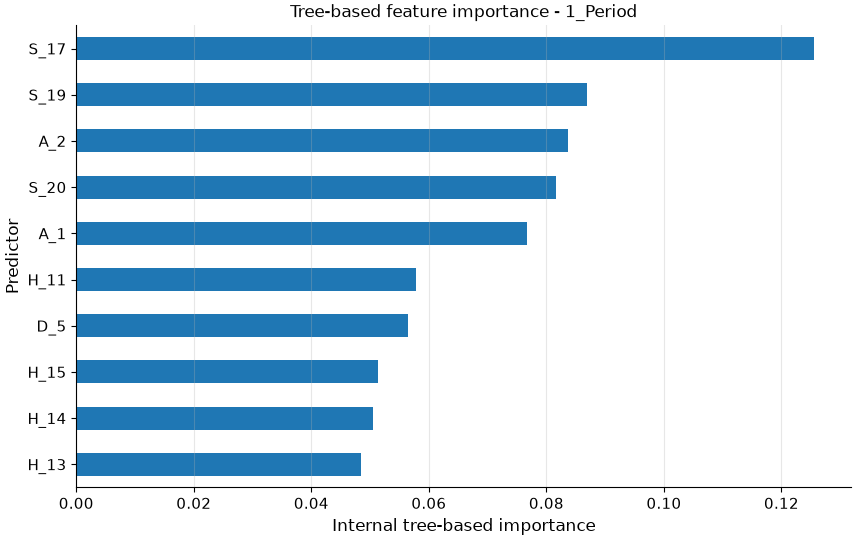

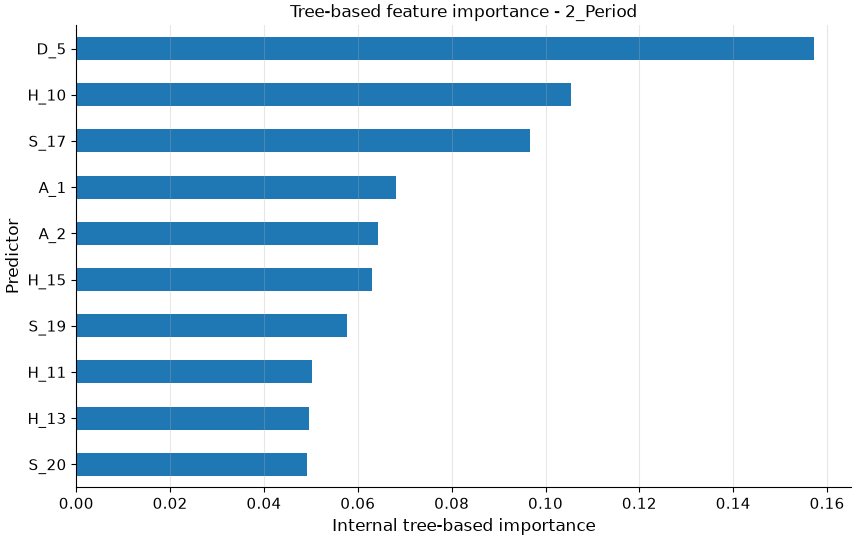

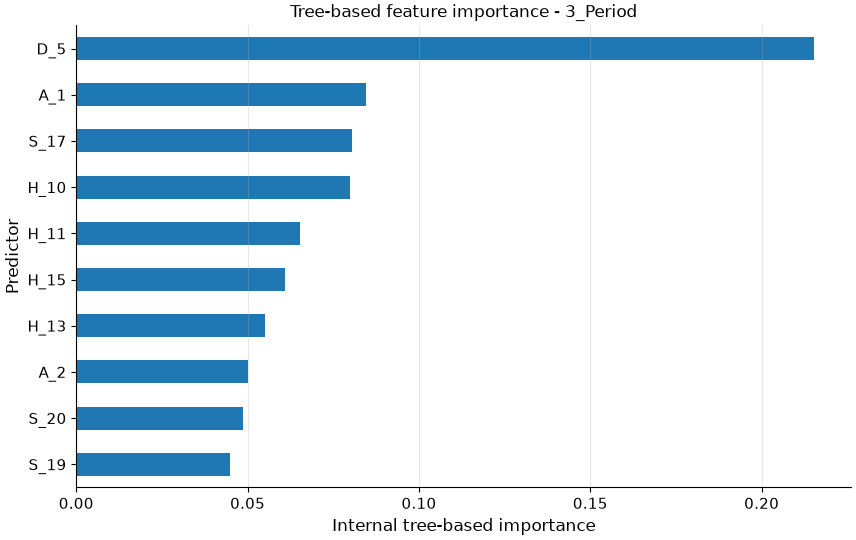

In [302]:
# =============================================================================
# PLOT TREE-BASED FEATURE IMPORTANCE
# =============================================================================

top_n = 10

if len(tree_importance_results_original) > 0:
    for period, importance_df in tree_importance_results_original.items():
        plot_data = (
            importance_df
            .head(top_n)
            .sort_values(by="importance", ascending=True)
        )

        ax = plot_data.plot(
            kind="barh",
            x="feature",
            y="importance",
            figsize=(10, 6),
            legend=False
        )

        ax.set_title(f"Tree-based feature importance - {period}")
        ax.set_xlabel("Internal tree-based importance")
        ax.set_ylabel("Predictor")
        ax.grid(axis="x", alpha=0.3)

        plt.show()

else:
    print(
        "No tree-based feature importance plots were generated because no "
        "tree-based models were available."
    )

## Logistic Regression Coefficients

This section analyzes the coefficients of the best Logistic Regression model for each historical period.

Although Logistic Regression was not necessarily the final selected model, it provides an interpretable linear reference. Positive coefficients are associated with higher predicted probability of the positive class, `Satisfied (1)`, while negative coefficients are associated with lower predicted probability.

Because the models use preprocessing and regularization, coefficients should be interpreted as predictive associations, not causal effects.

In [303]:
# =============================================================================
# BEST LOGISTIC REGRESSION MODEL BY HISTORICAL PERIOD
# =============================================================================

logistic_candidates = all_experiments_df[
    all_experiments_df["model"].str.contains(
        "Logistic Regression",
        case=False,
        regex=False
    )
].copy()

best_logistic_by_period = (
    logistic_candidates
    .sort_values(
        by=["period", REFIT_METRIC],
        ascending=[True, False]
    )
    .groupby("period")
    .head(1)
    .copy()
)

display(best_logistic_by_period)

,experiment,period,period_label,model,accuracy,balanced_accuracy,precision,recall,f1,f1_macro,precision_dissatisfied,recall_dissatisfied,f1_dissatisfied,support_dissatisfied,precision_satisfied,recall_satisfied,f1_satisfied,support_satisfied,true_negative,false_positive,false_negative,true_positive,roc_auc,best_params,best_cv_score
2,Class weight grid,1_Period,First period,Logistic Regression,0.606335,0.591259,0.357447,0.558140,0.435798,0.566752,0.790551,0.624378,0.697707,804.0,0.357447,0.558140,0.435798,301.0,502,302,133,168,0.630758,"{'classifier__C': 0.01, 'classifier__class_wei...",0.563333
3,Class weight grid,2_Period,Second period,Logistic Regression,0.712077,0.682468,0.683962,0.530165,0.597322,0.686627,0.724839,0.834772,0.775931,811.0,0.683962,0.530165,0.597322,547.0,677,134,257,290,0.744845,"{'classifier__C': 0.1, 'classifier__class_weig...",0.680978
25,SMOTENC,3_Period,Third period,Logistic Regression + SMOTENC,0.718499,0.709232,0.576159,0.679688,0.623656,0.699408,0.815315,0.738776,0.775161,735.0,0.576159,0.679688,0.623656,384.0,543,192,123,261,0.769951,"{'classifier__C': 0.01, 'classifier__l1_ratio'...",0.703054


In [304]:
# =============================================================================
# LOGISTIC REGRESSION COEFFICIENT FUNCTION
# =============================================================================

def compute_logistic_regression_coefficients(
    fitted_model,
    original_features
):
    """
    Extract coefficients from a fitted Logistic Regression pipeline.

    Coefficients are reported at the transformed-feature level and then
    aggregated to the original predictor level using the sum of absolute
    coefficients.
    """

    best_pipeline = fitted_model.best_estimator_
    classifier = best_pipeline.named_steps["classifier"]

    if not hasattr(classifier, "coef_"):
        raise ValueError(
            "The selected classifier does not provide coefficients."
        )

    transformed_feature_names = get_transformed_feature_names(
        fitted_model=fitted_model,
        original_features=original_features
    )

    coefficients = classifier.coef_.ravel()

    transformed_coefficients_df = pd.DataFrame({
        "transformed_feature": transformed_feature_names,
        "coefficient": coefficients
    })

    transformed_coefficients_df["absolute_coefficient"] = (
        transformed_coefficients_df["coefficient"].abs()
    )

    transformed_coefficients_df["odds_ratio"] = np.exp(
        transformed_coefficients_df["coefficient"]
    )

    transformed_coefficients_df["feature"] = transformed_coefficients_df[
        "transformed_feature"
    ].apply(
        lambda name: map_transformed_feature_to_original(
            transformed_name=name,
            original_features=original_features
        )
    )

    original_coefficients_df = (
        transformed_coefficients_df
        .groupby("feature", as_index=False)
        .agg(
            total_absolute_coefficient=("absolute_coefficient", "sum"),
            mean_absolute_coefficient=("absolute_coefficient", "mean"),
            max_absolute_coefficient=("absolute_coefficient", "max")
        )
        .sort_values(by="total_absolute_coefficient", ascending=False)
    )

    return transformed_coefficients_df, original_coefficients_df

In [305]:
# =============================================================================
# LOGISTIC REGRESSION COEFFICIENTS BY HISTORICAL PERIOD
# =============================================================================

logistic_coefficients_transformed = {}
logistic_coefficients_original = {}

for _, row in best_logistic_by_period.iterrows():
    period = row["period"]
    model_name = row["model"]
    experiment = row["experiment"]

    print("\n" + "=" * 100)
    print(f"Logistic Regression coefficients for period: {period}")
    print(f"Model: {model_name}")
    print(f"Experiment: {experiment}")
    print("=" * 100)

    fitted_model = get_fitted_model_by_experiment(
        period=period,
        model_name=model_name,
        experiment=experiment
    )

    current_feature_columns = get_feature_columns_by_experiment(
        experiment=experiment
    )

    transformed_df, original_df = compute_logistic_regression_coefficients(
        fitted_model=fitted_model,
        original_features=current_feature_columns
    )

    logistic_coefficients_transformed[period] = transformed_df
    logistic_coefficients_original[period] = original_df

    print("\nTop positive coefficients:")
    display(
        transformed_df
        .sort_values(by="coefficient", ascending=False)
        .head(10)
    )

    print("\nTop negative coefficients:")
    display(
        transformed_df
        .sort_values(by="coefficient", ascending=True)
        .head(10)
    )

    print("\nTop original predictors by absolute coefficient:")
    display(original_df.head(15))


Logistic Regression coefficients for period: 1_Period
Model: Logistic Regression
Experiment: Class weight grid

Top positive coefficients:


,transformed_feature,coefficient,absolute_coefficient,odds_ratio,feature
18,nominal__A_1_1.0,0.234959,0.234959,1.264857,A_1
22,nominal__S_20_2.0,0.112547,0.112547,1.119125,S_20
16,binary__S_16,0.077348,0.077348,1.080418,S_16
12,binary__D_6,0.058892,0.058892,1.060661,D_6
13,binary__D_7,0.056444,0.056444,1.058067,D_7
28,nominal__S_22_1.0,0.050749,0.050749,1.052059,S_22
25,nominal__S_20_5.0,0.048153,0.048153,1.049331,S_20
15,binary__D_9,0.042316,0.042316,1.043224,D_9
30,nominal__S_22_3.0,0.035703,0.035703,1.036348,S_22
19,nominal__A_1_2.0,0.032976,0.032976,1.033526,A_1



Top negative coefficients:


,transformed_feature,coefficient,absolute_coefficient,odds_ratio,feature
20,nominal__A_1_3.0,-0.267931,0.267931,0.764961,A_1
2,ordinal__D_5,-0.171620,0.171620,0.842299,D_5
23,nominal__S_20_3.0,-0.125417,0.125417,0.882129,S_20
8,ordinal__H_15,-0.119378,0.119378,0.887473,H_15
14,binary__D_8,-0.111045,0.111045,0.894899,D_8
4,ordinal__H_11,-0.105164,0.105164,0.900177,H_11
3,ordinal__H_10,-0.087123,0.087123,0.916564,H_10
6,ordinal__H_13,-0.069949,0.069949,0.932442,H_13
29,nominal__S_22_2.0,-0.067007,0.067007,0.935189,S_22
11,binary__C_4,-0.058258,0.058258,0.943407,C_4



Top original predictors by absolute coefficient:


...

,transformed_feature,coefficient,absolute_coefficient,odds_ratio,feature
13,categorical__x2_2.0,0.823351,0.823351,2.278122,D_5
77,categorical__x18_1.0,0.584604,0.584604,1.794280,A_1
87,categorical__x20_1.0,0.279746,0.279746,1.322794,S_22
59,categorical__x10_2.0,0.203917,0.203917,1.226196,S_21
6,categorical__x1_5.0,0.169524,0.169524,1.184741,A_2
29,categorical__x6_1.0,0.121080,0.121080,1.128715,H_13
18,categorical__x3_2.0,0.093202,0.093202,1.097684,H_10
14,categorical__x2_3.0,0.073811,0.073811,1.076603,D_5
22,categorical__x4_2.0,0.048663,0.048663,1.049866,H_11
74,categorical__x16_1.0,0.029889,0.029889,1.030340,S_16



Top negative coefficients:


,transformed_feature,coefficient,absolute_coefficient,odds_ratio,feature
16,categorical__x2_5.0,-0.686866,0.686866,0.503151,D_5
15,categorical__x2_4.0,-0.587783,0.587783,0.555558,D_5
40,categorical__x8_4.0,-0.335875,0.335875,0.714712,H_15
20,categorical__x3_4.0,-0.305127,0.305127,0.737030,H_10
79,categorical__x18_3.0,-0.241708,0.241708,0.785285,A_1
24,categorical__x4_4.0,-0.231981,0.231981,0.792961,H_11
31,categorical__x6_3.0,-0.143982,0.143982,0.865904,H_13
27,categorical__x5_3.0,-0.081634,0.081634,0.921609,H_12
73,categorical__x16_0.0,-0.058776,0.058776,0.942917,S_16
35,categorical__x7_3.0,-0.056158,0.056158,0.945390,H_14



Top original predictors by absolute coefficient:


,feature,total_absolute_coefficient,mean_absolute_coefficient,max_absolute_coefficient
3,D_5,2.171811,0.434362,0.823351
0,A_1,0.826312,0.275437,0.584604
8,H_10,0.398330,0.099582,0.305127
13,H_15,0.335875,0.083969,0.335875
9,H_11,0.280644,0.070161,0.231981
20,S_22,0.279746,0.018650,0.279746
11,H_13,0.265061,0.066265,0.143982
19,S_21,0.203917,0.040783,0.203917
1,A_2,0.169524,0.015411,0.169524
14,S_16,0.088666,0.044333,0.058776


In [306]:
# =============================================================================
# COMBINED LOGISTIC REGRESSION COEFFICIENT TABLE
# =============================================================================

logistic_original_coefficients_list = []

for period, coefficients_df in logistic_coefficients_original.items():
    temp_df = coefficients_df.copy()
    temp_df["period"] = period
    logistic_original_coefficients_list.append(temp_df)

logistic_original_coefficients_df = pd.concat(
    logistic_original_coefficients_list,
    ignore_index=True
)

logistic_original_coefficients_df = logistic_original_coefficients_df[
    [
        "period",
        "feature",
        "total_absolute_coefficient",
        "mean_absolute_coefficient",
        "max_absolute_coefficient"
    ]
]

logistic_original_coefficients_df = logistic_original_coefficients_df.sort_values(
    by=["period", "total_absolute_coefficient"],
    ascending=[True, False]
)

display(logistic_original_coefficients_df)

,period,feature,total_absolute_coefficient,mean_absolute_coefficient,max_absolute_coefficient
0,1_Period,A_1,0.535866,0.178622,0.267931
1,1_Period,S_20,0.380848,0.054407,0.125417
2,1_Period,S_22,0.277618,0.017351,0.067007
3,1_Period,D_5,0.171620,0.171620,0.171620
4,1_Period,H_15,0.119378,0.119378,0.119378
...,...,...,...,...,...
58,3_Period,C_4,0.000000,0.000000,0.000000
59,3_Period,D_8,0.000000,0.000000,0.000000
60,3_Period,D_9,0.000000,0.000000,0.000000
61,3_Period,S_18,0.000000,0.000000,0.000000


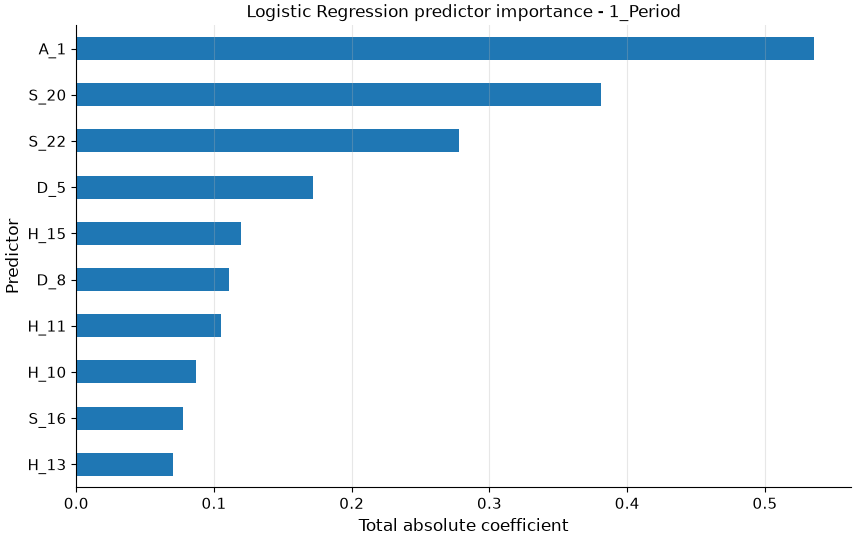

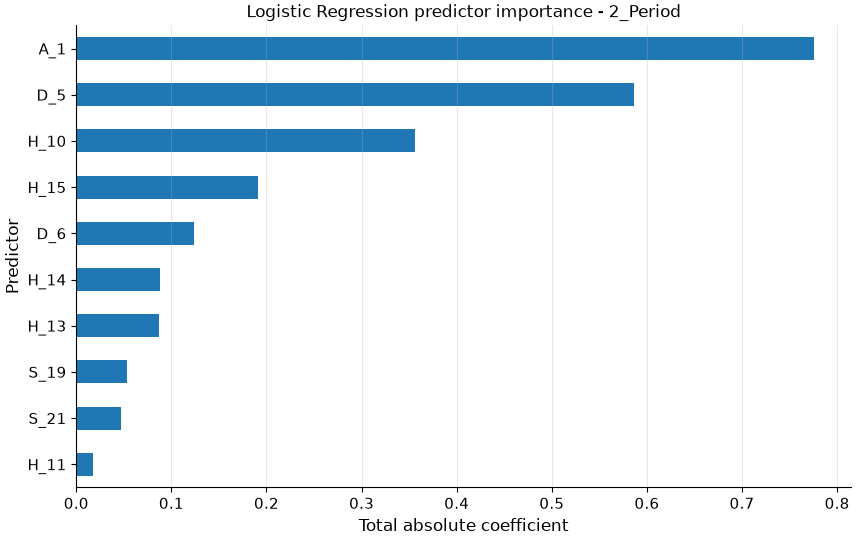

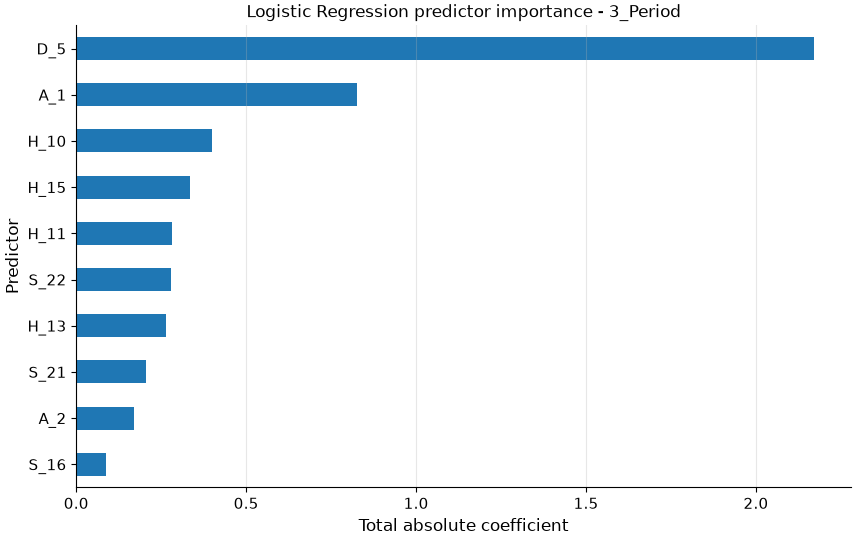

In [307]:
# =============================================================================
# PLOT LOGISTIC REGRESSION PREDICTOR IMPORTANCE
# =============================================================================

top_n = 10

for period, coefficients_df in logistic_coefficients_original.items():
    plot_data = (
        coefficients_df
        .head(top_n)
        .sort_values(by="total_absolute_coefficient", ascending=True)
    )

    ax = plot_data.plot(
        kind="barh",
        x="feature",
        y="total_absolute_coefficient",
        figsize=(10, 6),
        legend=False
    )

    ax.set_title(f"Logistic Regression predictor importance - {period}")
    ax.set_xlabel("Total absolute coefficient")
    ax.set_ylabel("Predictor")
    ax.grid(axis="x", alpha=0.3)

    plt.show()

## Comparison of Predictor Importance Methods

This section compares the predictor rankings obtained from permutation importance, tree-based feature importance, and Logistic Regression coefficients.

The goal is not to force all methods to produce the same ranking, but to identify predictors that appear consistently important across different interpretation strategies.

Consistent predictors provide stronger evidence of predictive relevance, while differences between methods highlight the dependence of interpretation on the model and importance definition.

In [308]:
# =============================================================================
# COMBINED PERMUTATION IMPORTANCE TABLE
# =============================================================================

combined_importance = []

for period, importance_df in final_importance_results.items():
    temp_df = importance_df.copy()
    temp_df["period"] = period
    combined_importance.append(temp_df)

if len(combined_importance) > 0:
    combined_importance_df = pd.concat(
        combined_importance,
        ignore_index=True
    )

    combined_importance_df = combined_importance_df[
        [
            "period",
            "feature",
            "importance_mean",
            "importance_std"
        ]
    ]

    combined_importance_df = combined_importance_df.sort_values(
        by=["period", "importance_mean"],
        ascending=[True, False]
    )

    display(combined_importance_df)

else:
    combined_importance_df = pd.DataFrame(
        columns=[
            "period",
            "feature",
            "importance_mean",
            "importance_std"
        ]
    )

    print("No permutation importance results are available.")

,period,feature,importance_mean,importance_std
0,1_Period,H_15,0.046409,0.006969
1,1_Period,S_17,0.041921,0.006555
2,1_Period,A_1,0.040912,0.009364
3,1_Period,H_13,0.030182,0.006642
4,1_Period,H_14,0.021350,0.006839
...,...,...,...,...
58,3_Period,D_9,0.001178,0.001390
59,3_Period,C_4,0.000850,0.001514
60,3_Period,S_21,0.000272,0.003285
61,3_Period,D_7,-0.000736,0.002526


In [309]:
# =============================================================================
# COMBINE PREDICTOR IMPORTANCE RANKINGS
# =============================================================================

def prepare_ranked_importance(
    df,
    period_col,
    feature_col,
    score_col,
    method_name
):
    ranked_df = df[[period_col, feature_col, score_col]].copy()

    ranked_df = ranked_df.rename(
        columns={
            period_col: "period",
            feature_col: "feature",
            score_col: "score"
        }
    )

    ranked_df["method"] = method_name

    ranked_df["rank"] = (
        ranked_df
        .groupby("period")["score"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    return ranked_df


importance_ranking_tables = []

# Permutation importance.
if "combined_importance_df" in globals() and len(combined_importance_df) > 0:
    importance_ranking_tables.append(
        prepare_ranked_importance(
            df=combined_importance_df,
            period_col="period",
            feature_col="feature",
            score_col="importance_mean",
            method_name="Permutation importance"
        )
    )

# Tree-based feature importance.
if "tree_original_importance_df" in globals() and len(tree_original_importance_df) > 0:
    importance_ranking_tables.append(
        prepare_ranked_importance(
            df=tree_original_importance_df,
            period_col="period",
            feature_col="feature",
            score_col="importance",
            method_name="Tree-based importance"
        )
    )

# Logistic Regression coefficients.
if "logistic_original_coefficients_df" in globals() and len(logistic_original_coefficients_df) > 0:
    importance_ranking_tables.append(
        prepare_ranked_importance(
            df=logistic_original_coefficients_df,
            period_col="period",
            feature_col="feature",
            score_col="total_absolute_coefficient",
            method_name="Logistic coefficients"
        )
    )

if len(importance_ranking_tables) > 0:
    importance_methods_comparison_df = pd.concat(
        importance_ranking_tables,
        ignore_index=True
    )

    importance_methods_comparison_df = importance_methods_comparison_df.sort_values(
        by=["period", "method", "rank"]
    )

    display(importance_methods_comparison_df)

else:
    importance_methods_comparison_df = pd.DataFrame(
        columns=["period", "feature", "score", "method", "rank"]
    )

    print("No predictor importance results are available for comparison.")

,period,feature,score,method,rank
126,1_Period,A_1,0.535866,Logistic coefficients,1
127,1_Period,S_20,0.380848,Logistic coefficients,2
128,1_Period,S_22,0.277618,Logistic coefficients,3
129,1_Period,D_5,0.171620,Logistic coefficients,4
130,1_Period,H_15,0.119378,Logistic coefficients,5
...,...,...,...,...,...
121,3_Period,S_18,0.014632,Tree-based importance,17
122,3_Period,D_7,0.013736,Tree-based importance,18
123,3_Period,D_6,0.013627,Tree-based importance,19
124,3_Period,C_4,0.009443,Tree-based importance,20


In [310]:
# =============================================================================
# TOP PREDICTORS BY METHOD AND HISTORICAL PERIOD
# =============================================================================

top_n = 10

top_predictors_by_method = (
    importance_methods_comparison_df[
        importance_methods_comparison_df["rank"] <= top_n
    ]
    .sort_values(by=["period", "method", "rank"])
)

display(top_predictors_by_method)

,period,feature,score,method,rank
126,1_Period,A_1,0.535866,Logistic coefficients,1
127,1_Period,S_20,0.380848,Logistic coefficients,2
128,1_Period,S_22,0.277618,Logistic coefficients,3
129,1_Period,D_5,0.171620,Logistic coefficients,4
130,1_Period,H_15,0.119378,Logistic coefficients,5
...,...,...,...,...,...
110,3_Period,H_15,0.060892,Tree-based importance,6
111,3_Period,H_13,0.055047,Tree-based importance,7
112,3_Period,A_2,0.050233,Tree-based importance,8
113,3_Period,S_20,0.048756,Tree-based importance,9


In [311]:
# =============================================================================
# PIVOT TABLE OF PREDICTOR RANKINGS
# =============================================================================

ranking_pivot_df = importance_methods_comparison_df.pivot_table(
    index=["period", "feature"],
    columns="method",
    values="rank",
    aggfunc="min"
).reset_index()

# Remove the column index name created by pivot_table.
ranking_pivot_df.columns.name = None

# Define the preferred order of interpretation methods.
preferred_method_order = [
    "Permutation importance",
    "Tree-based importance",
    "Logistic coefficients"
]

# Use only the method columns that actually exist in the pivot table.
available_method_columns = [
    column for column in preferred_method_order
    if column in ranking_pivot_df.columns
]

# Sort using only available method columns.
ranking_pivot_df = ranking_pivot_df.sort_values(
    by=["period"] + available_method_columns,
    ascending=[True] + [True] * len(available_method_columns)
)

display(ranking_pivot_df)

,period,feature,Logistic coefficients,Permutation importance,Tree-based importance
13,1_Period,H_15,5,1,8
15,1_Period,S_17,19,2,1
0,1_Period,A_1,1,3,5
11,1_Period,H_13,10,4,10
12,1_Period,H_14,18,5,9
...,...,...,...,...,...
49,3_Period,D_9,16,17,15
44,3_Period,C_4,16,18,20
61,3_Period,S_21,8,19,13
47,3_Period,D_7,13,20,18


In [312]:
# =============================================================================
# RECURRENT TOP PREDICTORS ACROSS METHODS
# =============================================================================

top_n = 10

recurrent_top_predictors = (
    importance_methods_comparison_df[
        importance_methods_comparison_df["rank"] <= top_n
    ]
    .groupby(["period", "feature"], as_index=False)
    .agg(
        number_of_methods=("method", "nunique"),
        methods=("method", lambda values: ", ".join(sorted(values.unique()))),
        best_rank=("rank", "min")
    )
    .sort_values(
        by=["period", "number_of_methods", "best_rank"],
        ascending=[True, False, True]
    )
)

display(recurrent_top_predictors)

,period,feature,number_of_methods,methods,best_rank
0,1_Period,A_1,3,"Logistic coefficients, Permutation importance,...",1
9,1_Period,H_15,3,"Logistic coefficients, Permutation importance,...",1
7,1_Period,H_13,3,"Logistic coefficients, Permutation importance,...",4
11,1_Period,S_17,2,"Permutation importance, Tree-based importance",1
12,1_Period,S_19,2,"Permutation importance, Tree-based importance",2
13,1_Period,S_20,2,"Logistic coefficients, Tree-based importance",2
1,1_Period,A_2,2,"Permutation importance, Tree-based importance",3
2,1_Period,D_5,2,"Logistic coefficients, Tree-based importance",4
8,1_Period,H_14,2,"Permutation importance, Tree-based importance",5
5,1_Period,H_11,2,"Logistic coefficients, Tree-based importance",6


In [313]:
# =============================================================================
# ADD INTERPRETABLE LABELS TO RECURRENT PREDICTORS
# =============================================================================

feature_labels = {
    "A_1": "Support for democracy",
    "A_2": "Left-right self-positioning",
    "C_4": "Employment status",
    "D_5": "Perception of national economy",
    "D_6": "Washing machine ownership",
    "D_7": "Car ownership",
    "D_8": "Sewerage access",
    "D_9": "Hot water access",
    "H_10": "Trust in Congress",
    "H_11": "Trust in Judiciary",
    "H_12": "Trust in Church",
    "H_13": "Trust in Police",
    "H_14": "Trust in Armed Forces",
    "H_15": "Trust in Political Parties",
    "S_16": "Sex",
    "S_17": "Age",
    "S_18": "Chief income earner",
    "S_19": "Education level",
    "S_20": "Employment situation",
    "S_21": "Socioeconomic status",
    "S_22": "Religion"
}

feature_groups = {
    "A_1": "Political attitudes",
    "A_2": "Political attitudes",

    "C_4": "Labor and economic conditions",
    "D_5": "Economic perceptions",

    "D_6": "Material conditions",
    "D_7": "Material conditions",
    "D_8": "Material conditions",
    "D_9": "Material conditions",

    "H_10": "Institutional trust",
    "H_11": "Institutional trust",
    "H_12": "Institutional trust",
    "H_13": "Institutional trust",
    "H_14": "Institutional trust",
    "H_15": "Institutional trust",

    "S_16": "Sociodemographic characteristics",
    "S_17": "Sociodemographic characteristics",
    "S_18": "Sociodemographic characteristics",
    "S_19": "Sociodemographic characteristics",
    "S_20": "Sociodemographic characteristics",
    "S_21": "Sociodemographic characteristics",
    "S_22": "Sociodemographic characteristics"
}

recurrent_top_predictors_interpretable = recurrent_top_predictors.copy()

recurrent_top_predictors_interpretable["feature_label"] = (
    recurrent_top_predictors_interpretable["feature"]
    .map(feature_labels)
    .fillna(recurrent_top_predictors_interpretable["feature"])
)

recurrent_top_predictors_interpretable["feature_group"] = (
    recurrent_top_predictors_interpretable["feature"]
    .map(feature_groups)
    .fillna("Other")
)

display(
    recurrent_top_predictors_interpretable[
        [
            "period",
            "feature",
            "feature_label",
            "feature_group",
            "number_of_methods",
            "methods",
            "best_rank"
        ]
    ]
)

,period,feature,feature_label,feature_group,number_of_methods,methods,best_rank
0,1_Period,A_1,Support for democracy,Political attitudes,3,"Logistic coefficients, Permutation importance,...",1
9,1_Period,H_15,Trust in Political Parties,Institutional trust,3,"Logistic coefficients, Permutation importance,...",1
7,1_Period,H_13,Trust in Police,Institutional trust,3,"Logistic coefficients, Permutation importance,...",4
11,1_Period,S_17,Age,Sociodemographic characteristics,2,"Permutation importance, Tree-based importance",1
12,1_Period,S_19,Education level,Sociodemographic characteristics,2,"Permutation importance, Tree-based importance",2
13,1_Period,S_20,Employment situation,Sociodemographic characteristics,2,"Logistic coefficients, Tree-based importance",2
1,1_Period,A_2,Left-right self-positioning,Political attitudes,2,"Permutation importance, Tree-based importance",3
2,1_Period,D_5,Perception of national economy,Economic perceptions,2,"Logistic coefficients, Tree-based importance",4
8,1_Period,H_14,Trust in Armed Forces,Institutional trust,2,"Permutation importance, Tree-based importance",5
5,1_Period,H_11,Trust in Judiciary,Institutional trust,2,"Logistic coefficients, Tree-based importance",6


The three interpretation methods provide complementary perspectives.

Permutation importance is used as the main interpretation method because it evaluates how much the selected performance metric decreases when each predictor is randomly shuffled. Therefore, it is directly linked to the predictive objective of the study.

Tree-based feature importance is included as a complementary analysis because it is commonly used in Decision Tree and Random Forest models. However, it measures internal impurity reduction and may favor variables with more possible split points.

Logistic Regression coefficients provide an interpretable linear reference. Positive coefficients are associated with higher predicted probability of satisfaction, while negative coefficients are associated with lower predicted probability. However, coefficients should be interpreted cautiously because preprocessing, regularization, and categorical encoding affect their magnitude.

Predictors that appear consistently across these methods provide stronger evidence of predictive relevance. Nevertheless, all results represent predictive importance, not causal effects.

## Most Important Predictors by Historical Period

This section summarizes and visualizes the most important predictors for each historical period.

Only the top predictors are displayed to make the interpretation clearer. Predictors with larger permutation importance values contribute more to the model's classification performance.

In [314]:
# =============================================================================
# COMBINED PREDICTOR IMPORTANCE TABLE
# =============================================================================

combined_importance = []

for period, importance_df in final_importance_results.items():
    temp_df = importance_df.copy()
    temp_df["period"] = period
    combined_importance.append(temp_df)

combined_importance_df = pd.concat(
    combined_importance,
    ignore_index=True
)

combined_importance_df = combined_importance_df[
    [
        "period",
        "feature",
        "importance_mean",
        "importance_std"
    ]
]

combined_importance_df = combined_importance_df.sort_values(
    by=["period", "importance_mean"],
    ascending=[True, False]
)

display(combined_importance_df)

,period,feature,importance_mean,importance_std
0,1_Period,H_15,0.046409,0.006969
1,1_Period,S_17,0.041921,0.006555
2,1_Period,A_1,0.040912,0.009364
3,1_Period,H_13,0.030182,0.006642
4,1_Period,H_14,0.021350,0.006839
...,...,...,...,...
58,3_Period,D_9,0.001178,0.001390
59,3_Period,C_4,0.000850,0.001514
60,3_Period,S_21,0.000272,0.003285
61,3_Period,D_7,-0.000736,0.002526


In [315]:
# =============================================================================
# TOP PREDICTORS BY HISTORICAL PERIOD
# =============================================================================

top_n = 10

top_predictors_by_period = (
    combined_importance_df
    .sort_values(
        by=["period", "importance_mean"],
        ascending=[True, False]
    )
    .groupby("period")
    .head(top_n)
)

display(top_predictors_by_period)

,period,feature,importance_mean,importance_std
0,1_Period,H_15,0.046409,0.006969
1,1_Period,S_17,0.041921,0.006555
2,1_Period,A_1,0.040912,0.009364
3,1_Period,H_13,0.030182,0.006642
4,1_Period,H_14,0.021350,0.006839
5,1_Period,H_12,0.019438,0.004482
6,1_Period,S_21,0.017606,0.004307
7,1_Period,A_2,0.016945,0.007987
8,1_Period,H_10,0.015825,0.006183
9,1_Period,S_19,0.015675,0.005932


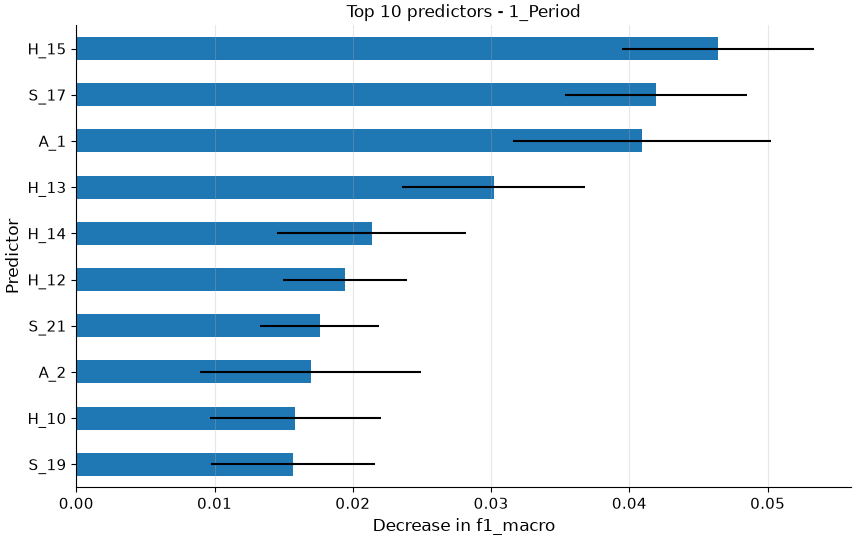

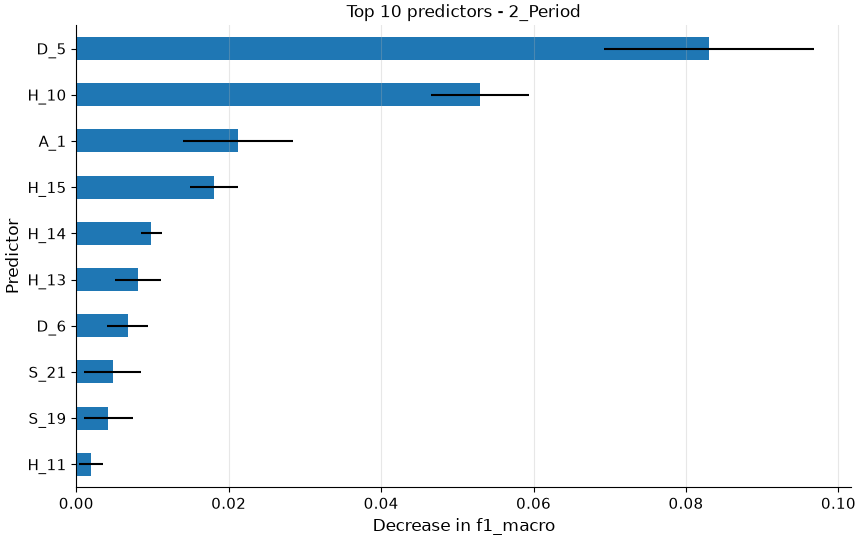

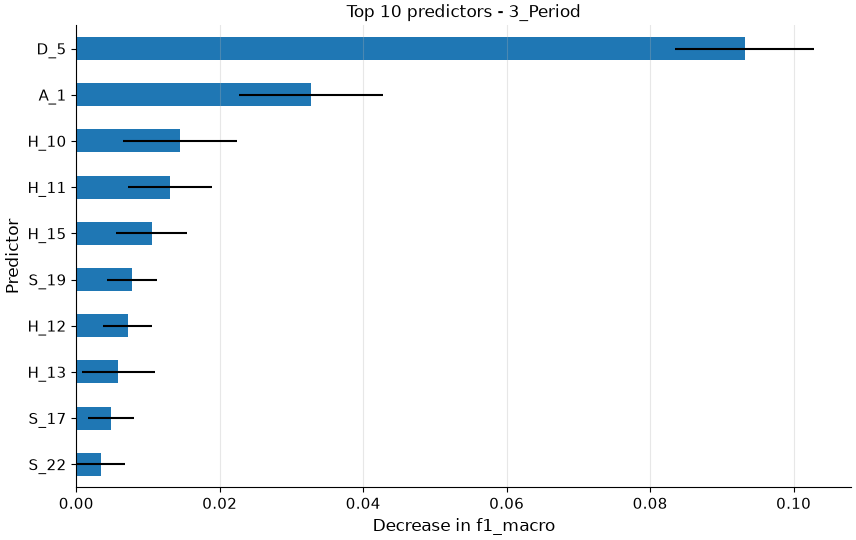

In [316]:
# =============================================================================
# PLOT TOP PREDICTORS BY HISTORICAL PERIOD
# =============================================================================

top_n = 10

for period, importance_df in final_importance_results.items():
    plot_data = (
        importance_df
        .head(top_n)
        .sort_values(by="importance_mean", ascending=True)
    )

    ax = plot_data.plot(
        kind="barh",
        x="feature",
        y="importance_mean",
        xerr="importance_std",
        figsize=(10, 6),
        legend=False
    )

    ax.set_title(f"Top {top_n} predictors - {period}")
    ax.set_xlabel(f"Decrease in {REFIT_METRIC}")
    ax.set_ylabel("Predictor")
    ax.grid(axis="x", alpha=0.3)

    plt.show()

## Interpretation of Predictor Importance

This section interprets the most relevant predictors and discusses how political attitudes, institutional trust, economic perceptions, and sociodemographic variables contribute to satisfaction with democracy across periods.

In [317]:
# =============================================================================
# FEATURE LABELS AND CONCEPTUAL GROUPS
# =============================================================================

feature_labels = {
    "A_1": "Support for democracy",
    "A_2": "Left-right self-positioning",
    "C_4": "Employment status",
    "D_5": "Perception of national economy",
    "D_6": "Washing machine ownership",
    "D_7": "Car ownership",
    "D_8": "Sewerage access",
    "D_9": "Hot water access",
    "H_10": "Trust in Congress",
    "H_11": "Trust in Judiciary",
    "H_12": "Trust in Church",
    "H_13": "Trust in Police",
    "H_14": "Trust in Armed Forces",
    "H_15": "Trust in Political Parties",
    "S_16": "Sex",
    "S_17": "Age",
    "S_18": "Chief income earner",
    "S_19": "Education level",
    "S_20": "Employment situation",
    "S_21": "Socioeconomic status",
    "S_22": "Religion"
}

feature_groups = {
    "A_1": "Political attitudes",
    "A_2": "Political attitudes",

    "C_4": "Labor and economic conditions",
    "D_5": "Economic perceptions",

    "D_6": "Material conditions",
    "D_7": "Material conditions",
    "D_8": "Material conditions",
    "D_9": "Material conditions",

    "H_10": "Institutional trust",
    "H_11": "Institutional trust",
    "H_12": "Institutional trust",
    "H_13": "Institutional trust",
    "H_14": "Institutional trust",
    "H_15": "Institutional trust",

    "S_16": "Sociodemographic characteristics",
    "S_17": "Sociodemographic characteristics",
    "S_18": "Sociodemographic characteristics",
    "S_19": "Sociodemographic characteristics",
    "S_20": "Sociodemographic characteristics",
    "S_21": "Sociodemographic characteristics",
    "S_22": "Sociodemographic characteristics"
}

In [318]:
# =============================================================================
# ADD FEATURE LABELS AND CONCEPTUAL GROUPS
# =============================================================================

interpretable_importance_df = combined_importance_df.copy()

interpretable_importance_df["feature_label"] = (
    interpretable_importance_df["feature"]
    .map(feature_labels)
)

interpretable_importance_df["feature_group"] = (
    interpretable_importance_df["feature"]
    .map(feature_groups)
)

# Keep original feature name when no label is available.
interpretable_importance_df["feature_label"] = (
    interpretable_importance_df["feature_label"]
    .fillna(interpretable_importance_df["feature"])
)

interpretable_importance_df["feature_group"] = (
    interpretable_importance_df["feature_group"]
    .fillna("Other")
)

display(interpretable_importance_df)

,period,feature,importance_mean,importance_std,feature_label,feature_group
0,1_Period,H_15,0.046409,0.006969,Trust in Political Parties,Institutional trust
1,1_Period,S_17,0.041921,0.006555,Age,Sociodemographic characteristics
2,1_Period,A_1,0.040912,0.009364,Support for democracy,Political attitudes
3,1_Period,H_13,0.030182,0.006642,Trust in Police,Institutional trust
4,1_Period,H_14,0.021350,0.006839,Trust in Armed Forces,Institutional trust
...,...,...,...,...,...,...
58,3_Period,D_9,0.001178,0.001390,Hot water access,Material conditions
59,3_Period,C_4,0.000850,0.001514,Employment status,Labor and economic conditions
60,3_Period,S_21,0.000272,0.003285,Socioeconomic status,Sociodemographic characteristics
61,3_Period,D_7,-0.000736,0.002526,Car ownership,Material conditions


In [319]:
# =============================================================================
# INTERPRETABLE TOP PREDICTORS BY HISTORICAL PERIOD
# =============================================================================

top_n = 10

interpretable_top_predictors = (
    interpretable_importance_df
    .sort_values(
        by=["period", "importance_mean"],
        ascending=[True, False]
    )
    .groupby("period")
    .head(top_n)
)

display(
    interpretable_top_predictors[
        [
            "period",
            "feature",
            "feature_label",
            "feature_group",
            "importance_mean",
            "importance_std"
        ]
    ]
)

,period,feature,feature_label,feature_group,importance_mean,importance_std
0,1_Period,H_15,Trust in Political Parties,Institutional trust,0.046409,0.006969
1,1_Period,S_17,Age,Sociodemographic characteristics,0.041921,0.006555
2,1_Period,A_1,Support for democracy,Political attitudes,0.040912,0.009364
3,1_Period,H_13,Trust in Police,Institutional trust,0.030182,0.006642
4,1_Period,H_14,Trust in Armed Forces,Institutional trust,0.021350,0.006839
5,1_Period,H_12,Trust in Church,Institutional trust,0.019438,0.004482
6,1_Period,S_21,Socioeconomic status,Sociodemographic characteristics,0.017606,0.004307
7,1_Period,A_2,Left-right self-positioning,Political attitudes,0.016945,0.007987
8,1_Period,H_10,Trust in Congress,Institutional trust,0.015825,0.006183
9,1_Period,S_19,Education level,Sociodemographic characteristics,0.015675,0.005932


In [320]:
# =============================================================================
# CONCEPTUAL GROUP IMPORTANCE BY HISTORICAL PERIOD
# =============================================================================

group_importance_df = (
    interpretable_importance_df
    .groupby(["period", "feature_group"], as_index=False)
    .agg(
        total_importance=("importance_mean", "sum"),
        mean_importance=("importance_mean", "mean"),
        number_of_features=("feature", "count")
    )
)

group_importance_df = group_importance_df.sort_values(
    by=["period", "total_importance"],
    ascending=[True, False]
)

display(group_importance_df)

,period,feature_group,total_importance,mean_importance,number_of_features
1,1_Period,Institutional trust,0.148560,0.024760,6
5,1_Period,Sociodemographic characteristics,0.108707,0.015530,7
4,1_Period,Political attitudes,0.057857,0.028929,2
0,1_Period,Economic perceptions,0.014695,0.014695,1
3,1_Period,Material conditions,0.011806,0.002952,4
2,1_Period,Labor and economic conditions,-0.001993,-0.001993,1
7,2_Period,Institutional trust,0.087743,0.014624,6
6,2_Period,Economic perceptions,0.083043,0.083043,1
10,2_Period,Political attitudes,0.021228,0.010614,2
11,2_Period,Sociodemographic characteristics,0.009361,0.001337,7


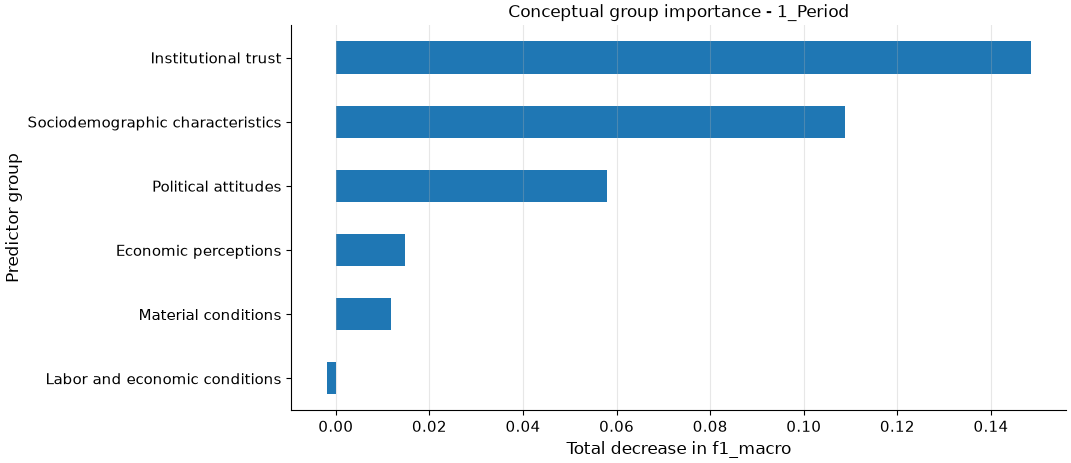

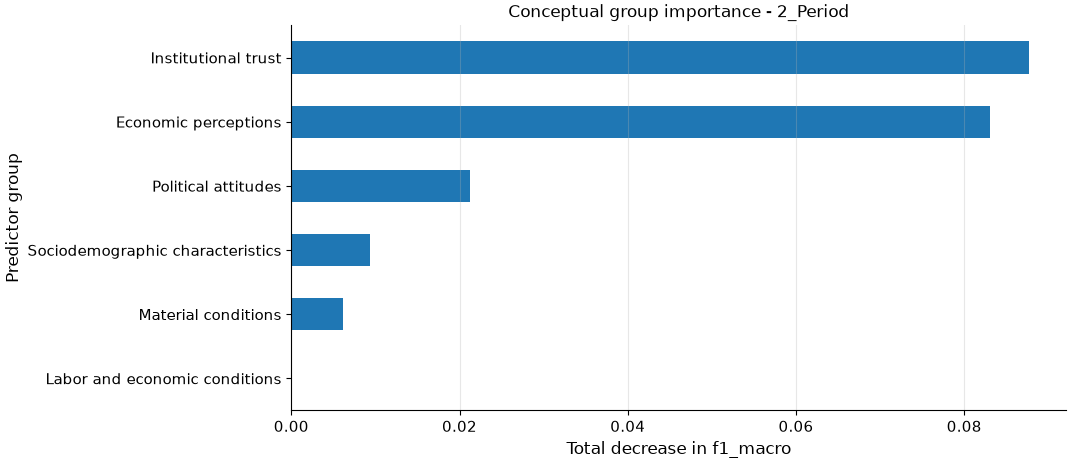

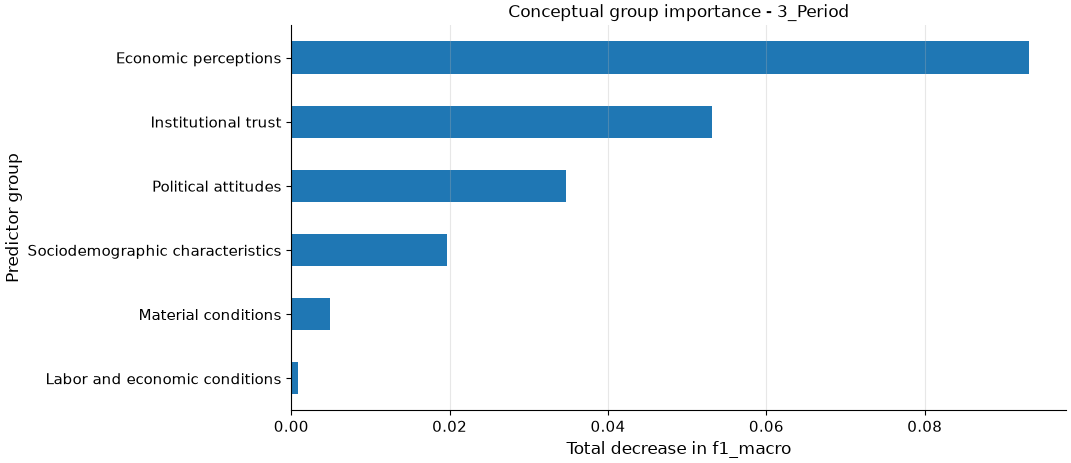

In [321]:
# =============================================================================
# PLOT CONCEPTUAL GROUP IMPORTANCE BY HISTORICAL PERIOD
# =============================================================================

for period in group_importance_df["period"].unique():
    plot_data = (
        group_importance_df[group_importance_df["period"] == period]
        .sort_values(by="total_importance", ascending=True)
    )

    ax = plot_data.plot(
        kind="barh",
        x="feature_group",
        y="total_importance",
        figsize=(10, 5),
        legend=False
    )

    ax.set_title(f"Conceptual group importance - {period}")
    ax.set_xlabel(f"Total decrease in {REFIT_METRIC}")
    ax.set_ylabel("Predictor group")
    ax.grid(axis="x", alpha=0.3)

    plt.show()

In [322]:
# =============================================================================
# AUTOMATIC TEXT SUMMARY OF TOP PREDICTORS
# =============================================================================

top_k = 5

for period in period_order:
    period_data = (
        interpretable_importance_df[
            interpretable_importance_df["period"] == period
        ]
        .sort_values(by="importance_mean", ascending=False)
        .head(top_k)
    )

    print("\n" + "=" * 100)
    print(f"Top {top_k} predictors for {period}")
    print("=" * 100)

    for _, row in period_data.iterrows():
        print(
            f"- {row['feature_label']} "
            f"({row['feature_group']}): "
            f"{row['importance_mean']:.4f}"
        )


Top 5 predictors for 1_Period
- Trust in Political Parties (Institutional trust): 0.0464
- Age (Sociodemographic characteristics): 0.0419
- Support for democracy (Political attitudes): 0.0409
- Trust in Police (Institutional trust): 0.0302
- Trust in Armed Forces (Institutional trust): 0.0214

Top 5 predictors for 2_Period
- Perception of national economy (Economic perceptions): 0.0830
- Trust in Congress (Institutional trust): 0.0529
- Support for democracy (Political attitudes): 0.0212
- Trust in Political Parties (Institutional trust): 0.0180
- Trust in Armed Forces (Institutional trust): 0.0099

Top 5 predictors for 3_Period
- Perception of national economy (Economic perceptions): 0.0932
- Support for democracy (Political attitudes): 0.0327
- Trust in Congress (Institutional trust): 0.0145
- Trust in Judiciary (Institutional trust): 0.0131
- Trust in Political Parties (Institutional trust): 0.0105


## Export Tables

This section exports the main result tables generated by the notebook to `output/tables/` in CSV and LaTeX formats.

In [323]:
# =============================================================================
# EXPORT TABLES
# =============================================================================

def export_table(df, table_name, tables_dir):
    """
    Export a DataFrame to CSV and LaTeX.

    The CSV file is useful for reproducibility and further analysis.
    The LaTeX file is useful for selecting tables for the paper.
    """

    tables_dir.mkdir(parents=True, exist_ok=True)

    safe_name = make_safe_filename(table_name)

    df_to_export = df.copy()

    # Convert dictionaries and other complex objects to strings
    # so that they can be safely exported.
    for column in df_to_export.columns:
        df_to_export[column] = df_to_export[column].apply(
            lambda value: str(value)
            if isinstance(value, (dict, list, tuple))
            else value
        )

    csv_path = tables_dir / f"{safe_name}.csv"
    latex_path = tables_dir / f"{safe_name}.tex"

    df_to_export.to_csv(csv_path, index=False)

    with open(latex_path, "w", encoding="utf-8") as file:
        file.write(
            df_to_export.to_latex(
                index=False,
                escape=False,
                float_format="%.4f"
            )
        )

    print(f"Exported: {csv_path}")
    print(f"Exported: {latex_path}")
    
    
    
tables_to_export = {
    # -------------------------------------------------------------------------
    # Target distribution tables
    # -------------------------------------------------------------------------
    "target_distribution_by_period_percentages": {
        "df": target_by_period_pct.reset_index().rename(columns={"index": "period"}),
        "dir": TARGET_DISTRIBUTION_TABLES_DIR
    },
    "target_counts_by_period": {
        "df": target_by_period_counts.reset_index().rename(columns={"index": "period"}),
        "dir": TARGET_DISTRIBUTION_TABLES_DIR
    },
    "yearly_target_distribution_percentages": {
        "df": yearly_target_proportions.reset_index().rename(columns={"X_24": "survey_year"}),
        "dir": TARGET_DISTRIBUTION_TABLES_DIR
    },

    # -------------------------------------------------------------------------
    # Experiment-level results
    # -------------------------------------------------------------------------
    "class_weight_grid_results": {
        "df": results_df,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "best_class_weight_grid_by_period": {
        "df": best_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "random_oversampler_results": {
        "df": ros_results_df,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "best_random_oversampler_by_period": {
        "df": best_ros_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "smotenc_results": {
        "df": smotenc_results_df,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "best_smotenc_by_period": {
        "df": best_smotenc_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },

    # -------------------------------------------------------------------------
    # Final model comparison
    # -------------------------------------------------------------------------
    "all_experiments_comparison": {
        "df": all_experiments_df,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "best_final_models_by_period": {
        "df": best_final_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "best_model_by_experiment_and_period": {
        "df": best_by_period_experiment,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },

    # -------------------------------------------------------------------------
    # Predictor importance
    # -------------------------------------------------------------------------
    "permutation_importance_all_periods": {
        "df": combined_importance_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "top_predictors_by_period": {
        "df": top_predictors_by_period,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "tree_based_feature_importance": {
        "df": tree_original_importance_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "best_random_forest_by_period": {
        "df": best_random_forest_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "logistic_regression_coefficients": {
        "df": logistic_original_coefficients_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "best_logistic_regression_by_period": {
        "df": best_logistic_by_period,
        "dir": MODEL_PERFORMANCE_TABLES_DIR
    },
    "importance_methods_comparison": {
        "df": importance_methods_comparison_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "top_predictors_by_method": {
        "df": top_predictors_by_method,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "predictor_ranking_pivot": {
        "df": ranking_pivot_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "recurrent_top_predictors": {
        "df": recurrent_top_predictors,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "recurrent_top_predictors_interpretable": {
        "df": recurrent_top_predictors_interpretable,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "interpretable_permutation_importance": {
        "df": interpretable_importance_df,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },
    "interpretable_top_predictors": {
        "df": interpretable_top_predictors,
        "dir": PREDICTOR_IMPORTANCE_TABLES_DIR
    },

    # -------------------------------------------------------------------------
    # Conceptual group importance
    # -------------------------------------------------------------------------
    "conceptual_group_importance": {
        "df": group_importance_df,
        "dir": CONCEPTUAL_GROUP_TABLES_DIR
    }
}

for table_name, table_info in tables_to_export.items():
    table_df = table_info["df"]
    table_dir = table_info["dir"]

    if isinstance(table_df, pd.DataFrame) and len(table_df) > 0:
        export_table(
            df=table_df,
            table_name=table_name,
            tables_dir=table_dir
        )
    else:
        print(f"Skipped empty table: {table_name}")

Exported: output/tables/target_distribution/target_distribution_by_period_percentages.csv
Exported: output/tables/target_distribution/target_distribution_by_period_percentages.tex
Exported: output/tables/target_distribution/target_counts_by_period.csv
Exported: output/tables/target_distribution/target_counts_by_period.tex
Exported: output/tables/target_distribution/yearly_target_distribution_percentages.csv
Exported: output/tables/target_distribution/yearly_target_distribution_percentages.tex
Exported: output/tables/model_performance/class_weight_grid_results.csv
Exported: output/tables/model_performance/class_weight_grid_results.tex
Exported: output/tables/model_performance/best_class_weight_grid_by_period.csv
Exported: output/tables/model_performance/best_class_weight_grid_by_period.tex
Exported: output/tables/model_performance/random_oversampler_results.csv
Exported: output/tables/model_performance/random_oversampler_results.tex
Exported: output/tables/model_performance/best_random_

The predictor importance results should be interpreted as indicators of predictive contribution rather than causal effects. A variable with high permutation importance is useful for the model's classification performance, but this does not imply that the variable causes satisfaction or dissatisfaction with democracy.

These results are useful for comparing how the predictive relevance of political attitudes, institutional trust, economic perceptions, material conditions, and sociodemographic characteristics varies across historical periods.